<span style="color: blue; font-size: 20px; font-weight: bold;">Комментарий ревьюера</span>

<span style="color: blue">Привет, Михаил! Меня зовут Павел Григорьев, и я буду проверять этот проект.<br>Моя основная цель - не указать на совершённые тобой ошибки, а поделиться своим опытом и помочь тебе совершенствоваться как профессионалу.<br>Спасибо за проделанную работу! Предлагаю общаться на «ты».</span>
<details>
	<summary><u>Инструкция по организационным моментам (кликабельно)</u>⤵</summary>
<span style="color: blue">Я буду использовать различные цвета, чтобы было удобнее воспринимать мои комментарии:</span>


---


<span style="color: blue">синий текст - просто текст комментария</span>

<span style="color: green">✔️ и зеленый текст - все отлично</span>

<span style="color: orange">⚠️ и оранжевый текст - сделано все правильно, однако есть рекомендации, на что стоит обратить внимание</span>

<span style="color: red">❌ и красный текст - есть недочеты</span>


</details>    
</br>
<span style="color: blue">Пожалуйста, не удаляй мои комментарии в случае возврата работы, так будет проще разобраться, какие были недочеты, а также сразу увидеть исправленное.</span>

<span style="color: blue">Ответы на мои комментарии лучше тоже помечать.<br>
Например: </span><br><span style="color: purple; font-weight: bold">Комментарий студента</span>

<span style="color: blue; font-weight: bold;">Давай смотреть, что получилось!</span>

</span><br><span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Привет, Павел! Спасибо за проверку моего проекта и за то, что поделился опытом — это очень ценно. С удовольствием общаемся на «ты» :)
<br>Я оставил свои пояснения под твоими комментариями — постарался учесть каждое замечание.</span>

<span style="color: blue; font-size: 18px; font-weight: bold;">Комментарий ревьюера 2</span>

<span style="color: blue">Привет еще раз. Спасибо, за исправления. Оформление комментариев по работе сохраняется. Только обозначим, что это вторая итерация.</span>

# 🏨 «Прогнозирование отмен бронирований в сети отелей UrbanStay: ML‑подход к повышению загрузки»

Автор: Якунин Михаил

Дата: "16" сентября 2026 г.

***По этой ссылке можно посмотреть проект и скачать последнюю версию: https://github.com/MEYakunin/Sprint17_Booking_Cancellation_Predict.git***

## Цель проекта

Разработать модель машинного обучения, прогнозирующую вероятность отмены бронирования в сети отелей **UrbanStay**, и оценить её экономическую эффективность. Внедрение такой модели позволит заказчику заранее выявлять рискованные бронирования, принимать превентивные меры для их сохранения и своевременно повторно сдавать номера, что снизит долю отмен бронирований в последний момент с ~30% до 10% и повысит загрузку отелей до 80% и более.

Для достижения цели планируется:

1. Подготовить данные: загрузить таблицы `hotel_bookings` и `hotel_reviews`, провести `EDA`, устранить дубликаты и аномалии, объединить таблицы и создать новые признаки (включая признаки на основе текстов отзывов).
2. Обучить и сравнить не менее двух моделей (`CatBoost`, `LightGBM`) с оптимизацией гиперпараметров в `Optuna`, выбрать лучшую по ключевой бизнес-метрике `Incremental Revenue (IR)`.
3. Откалибровать лучшую модель, подобрать оптимальный порог классификации и оценить важность признаков.
4. Рассчитать экономический эффект внедрения модели по трём показателям: прирост дохода (`IR`), динамика доли отмен бронирования и динамика загрузки отеля — и проверить достижение целевых `KPI` (доля отмен ≤ 10%, падение загрузки не более 8%, относительный `IR` ≥ 50%).

## Задача проекта

1. *Разработать ML-модель*, прогнозирующую вероятность отмены бронирования в сети отелей `UrbanStay` по входным данным о брони (канал продаж, состав гостей, история клиента, стоимость, срок до заезда и др.) и данным отзывов. Модель должна минимизировать финансовые потери сети отелей и по возможности повышать загрузку номеров: она позволит заранее выявлять рискованные бронирования и принимать решение о повторном бронировании номера или сохранении брони.

2. *Оценить экономическую эффективность модели* по трём показателям:
   - динамика доли отмен бронирования;
   - динамика загрузки отелей;
   - прирост дохода благодаря модели (`Incremental Revenue`, `IR`).

3. *Достичь целевых показателей*:
   - доля отмен бронирования после внедрения модели — не более 10%;
   - загрузка отеля не должна снизиться более чем на 8% относительно уровня до внедрения;
   - относительный `IR` — не менее 50%.

## Описание данных

Для проекта используются два источника данных, выгруженных из базы данных PostgreSQL с помощью SQL-запросов.

**Таблица `hotel_bookings`** — данные об истории бронирований номеров (35 341 запись). Каждая строка — отдельная бронь:

- `booking_id` — уникальный номер брони;
- `booking_date` — дата оформления брони;
- `sales_channel` — способ оформления брони: офлайн_бронирование, онлайн_бронирование, корпоративное_бронирование;
- `adult_count` — количество взрослых гостей;
- `child_count` — количество детей;
- `returning_customer` — отметка о том, что клиент уже бронировал номера в сети отелей;
- `previous_cancellations` — количество отменённых бронирований у клиента в прошлом;
- `previous_no_shows` — количество несостоявшихся заездов в прошлом;
- `booking_value` — итоговая стоимость бронирования в рублях;
- `days_until_checkin` — количество дней с момента брони до даты заселения;
- `weekend_nights` — количество ночей проживания, приходящихся на выходные дни;
- `weekday_nights` — количество ночей проживания, приходящихся на будние дни;
- `meal_plan` — выбранный гостями тип питания;
- `parking_included` — информация о бронировании парковочного места;
- `room_type` — категория номера или номеров в брони;
- `customer_special_requests` — количество комментариев и пожеланий клиента;
- `booking_status` — целевая переменная: `отказ_брони` (бронь отменена) / `нет_отказа` (бронь активна).

**Таблица `hotel_reviews`** — данные по истории отзывов о проживании (25 177 отзывов):

- `customer_id` — уникальный идентификатор клиента;
- `booking_id` — идентификатор брони, по которой оставлен отзыв;
- `review_date` — дата, когда клиент оставил отзыв;
- `stay_rating` — оценка проживания: от 1 (низший балл) до 5 (высший балл);
- `review_text` — развёрнутый текстовый комментарий клиента о проживании.

## Содержание <a id="content"></a>

* [1. Подготовка данных](#1)
  * [1.1. Подготовка среды и библиотек](#1_1)
  * [1.2. Загрузка данных](#1_2)
  * [1.3. Исследовательский анализ данных и предобработка](#1_3)
  * [1.4. Объединение таблиц](#1_4)
  * [1.5. Создание новых признаков](#1_5)
  * [1.6. Анализ итоговой таблицы](#1_6)
  * [1.7. Промежуточный итог](#1_7)
* [2. Моделирование](#2)
  * [2.1. Обучение базовых моделей](#2_1)
  * [2.2. Калибровка модели и пересчёт результатов](#2_2)
  * [2.3. Поиск порога классификации](#2_3)
  * [2.4. Анализ матрицы классификаций](#2_4)
  * [2.5. Фиксирование итоговой модели](#2_5)
  * [2.6. Анализ важности признаков](#2_6)
  * [2.7. Промежуточный итог](#2_7)
* [3. Расчёт экономической эффективности модели](#3)
  * [3.1. Подготовка данных для расчётов](#3_1)
  * [3.2. Расчёт показателей до и после внедрения модели](#3_2)
  * [3.3. Проверка целевых KPI](#3_3)
  * [3.4. Промежуточный итог](#3_4)
* [4. Выводы по проекту](#4)
  * [4.1. Выводы о проделанной работе](#4_1)
  * [4.2. Выводы по анализу эффективности модели](#4_2)



## [Этап 1: Подготовка данных <a id=1></a>](#content)

### [1.1 Подготовка среды и библиотек <a id=1_1></a>](#content)

In [1]:
# Установка основного научного стека (версии совместимы с Python 3.9.5 / JupyterHub Практикума)
%pip install \
    numpy==1.26.4 \
    pandas==2.2.3 \
    scipy==1.13.1 \
    scikit-learn==1.5.2 \
    matplotlib==3.9.4 \
    seaborn==0.13.2 \
    pillow==11.1.0 \
    contourpy==1.2.1 \
    cycler==0.12.1 \
    fonttools==4.54.1 \
    joblib==1.4.2 \
    kiwisolver==1.4.5 \
    packaging==24.1 \
    pyparsing==3.1.2 \
    python-dateutil==2.9.0.post0 \
    six==1.16.0 \
    threadpoolctl==3.5.0 \
    tzdata==2024.1

# Ключевые ML-библиотеки проекта
%pip install \
    catboost==1.2.7 \
    lightgbm==4.5.0 \
    nltk==3.9.1 \
    optuna==3.6.1 \
    phik==0.12.5 \
    SQLAlchemy==2.0.36

  Using cached numpy-1.26.4.tar.gz (15.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [21 lines of output]
      + c:\Python Project\Sprint17_Booking_Cancellation_Predict\.ml_env_sprint17\Scripts\python.exe C:\Users\meyak\AppData\Local\Temp\pip-install-is_sjyet\numpy_da12e23fbe434279a618bb64feb68d06\vendored-meson\meson\meson.py setup C:\Users\meyak\AppData\Local\Temp\pip-install-is_sjyet\numpy_da12e23fbe434279a618bb64feb68d06 C:\Users\meyak\AppData\Local\Temp\pip-install-is_sjyet\numpy_da12e23fbe434279a618bb64feb68d06\.mesonpy-p07aivwl -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\meyak\AppData\Local\Temp\pip-install-is_sjyet\numpy_da12e23fbe434279a618bb64feb68d06\.mesonpy-p07aivwl\meson-python-native-file.ini
      The Meson build system
      Version: 1.2.99
      Source dir: C:\Users\meyak\AppData\Local\Temp\pip-install-is_sjyet\numpy_da12e23fbe434279a618bb64feb68d06
      Build dir: C:\Users\meyak\AppData\

  Using cached catboost-1.2.7.tar.gz (71.5 MB)
  Installing build dependencies: started
  Installing build dependencies: still running...
  Installing build dependencies: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × installing build dependencies for catboost did not run successfully.
  │ exit code: 1
  ╰─> [391 lines of output]
        Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
        Using cached wheel-0.48.0-py3-none-any.whl.metadata (2.3 kB)
        Using cached jupyterlab-3.6.8-py3-none-any.whl.metadata (12 kB)
        Using cached conan-1.66.0-py3-none-any.whl
        Using cached ipython-9.17.1-py3-none-any.whl.metadata (4.6 kB)
        Using cached packaging-26.3-py3-none-any.whl.metadata (3.5 kB)
        Using cached tornado-6.5.10-cp39-abi3-win_amd64.whl.metadata (2.9 kB)
        Using cached jupyter_core-5.9.1-py3-none-any.whl.metadata (1.5 kB)
        Using cached jupyterlab_server-2.28.1-py3-none-any.whl.metadata (5.8 kB)
        Using cached jupyter_server-2.21.1-py3-none-any.whl.metadata (8.5 kB)
        Using cached jupyter_ydoc-0.2.5-py3-none-any.whl.metadata (2.2 kB)
        Using cached jupyter_server_ydoc-0.8.0

In [ ]:
# Стандартные библиотеки
import re

# Сторонние библиотеки
import lightgbm as lgb
import matplotlib as mpl
import matplotlib.pyplot as plt
import nltk
import numpy as np
import optuna
import pandas as pd
import seaborn as sns

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from nltk.corpus import stopwords
from optuna.pruners import MedianPruner
from phik.report import plot_correlation_matrix
from sqlalchemy import create_engine

from sklearn.base import clone
from sklearn.calibration import (
    CalibratedClassifierCV,
    CalibrationDisplay,
    calibration_curve,
)
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    StandardScaler,
)

# Загрузка стоп-слов NLTK (однократно при первом запуске)
nltk.download('stopwords')

c:\Python Project\Sprint17_Booking_Cancellation_Predict\.ml_env_sprint17\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\meyak\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Хорошее оформление импортов! \
Импорты собраны в одной ячейке, разделены на функциональные группы пустой строкой.</font>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color="red">Все зависимомсти нужно явно установить до импортов, что бы код полностью воспроизводился в JupyterHub Практикума.</font>

</span><br><span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Я раскомментировал строку кода в ячейке для установки зависимостей.</span>

<span style="color: blue; font-weight: bold">Комментарий ревьюера 2: </span>  ❌\
<font color="red">У меня нет твоего файла requirements.txt\
>Все зависимомсти нужно **явно** установить до импортов, что бы код полностью воспроизводился в JupyterHub Практикума.\
Обрати внимание, в JupyterHub Практикума версия Python 3.9.5 — версии устанавливаемых библиотек должны соответсвовать.</font>

</span><br><span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Я сразу и не понял что ты иммел ввиду. Просто я все предыдущие проекты так делал и замечаний не было. И я совсем забыл, что мы как исполнители должны проект делать так, что бы он был исполнимым на стороне заказчика. Я исправил первую ячейку проекта.</span>

In [3]:
# Устанавка константных параметров
RANDOM_STATE = 42
TEST_SIZE = 0.2
AVG_REV = 64500
COST_FP = 7000
LOST_REV = 64500
PER_REBOOKING = 45000
EARLY_STOPPING_ROUNDS = 20

# Целевые показатели по условию проекта
TARGET_CANCEL_SHARE = 0.10
MAX_OCCUPANCY_DROP = 0.08
MIN_RELATIVE_IR = 0.5

# Параметры для подключения к данным PostgreSQL 
db_config = {
    'user': 'praktikum_student',
    'pwd': 'Sdf4$2;d-d30pp', 
    'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
    'port': '6432', 
    'db': 'data-scientist-hotels' 
} 

In [4]:
# Настройки Pandas для отображения DataFrame
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}'.replace(',', ' '))
pd.set_option('display.memory_usage', True)

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

# Отключает научную нотацию (экспоненциальную запись) на оси Y для всех графиков
mpl.rcParams['axes.formatter.useoffset'] = False
mpl.rcParams['axes.formatter.limits'] = [-99, 99]

# Подавляем INFO-сообщения Optuna, оставляем только предупреждения и ошибки 
optuna.logging.set_verbosity(optuna.logging.WARNING)

### [1.2 Загрузка данных <a id=1_2></a>](#content)

In [5]:
# Создаем подключение к БД
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
) 

query_bookings = '''
SELECT *
FROM hotel_bookings
'''
query_reviews = '''
SELECT *
FROM hotel_reviews
'''

engine = create_engine(connection_string)

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'> Да, запрос не сложный )</font>

</span><br><span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Я тут решил пойти самым простым путем, так как не заходтел тратить время на вспоминие SQL и писать запрос который сразу выгрузит объеденненую таблицу. Но меня не покидает мысль, что в релальных проектах лучше и проще производить объединение таблиз на уровне запроса к БД. Можешь подскзать как на самом деле или каким способом чаще полузуются в реальности?</span>

<font color='blue'><b>Комментарий ревьюера 2: </b></font> ⚠️\
<font color='blue'>Здесь сильно зависит от умения писать эффекитивные SQL запросы. Пандас имеет встроенные методы, типа merge_asof, которые упрощают такое объединение, без огромных промежуточных таблиц.</font>

</span><br><span style="color: purple; font-weight: bold">Комментарий студента v2</span>
<span style="color: blue"><br>Спасибо</span>

In [6]:
# Извлекаем данные из БД
df_bookings = pd.read_sql(query_bookings, con=engine)
df_reviews = pd.read_sql(query_reviews, con=engine)

# Создание словаря c датафреймами
dataframes = {
    'bookings': df_bookings,
    'reviews': df_reviews
}

<font color='blue'><b>Комментарий ревьюера : </b></font> ⚠️\
<font color='darkorange'> В Pandas есть метод `pd.read_sql` в который можно передать или запрос или название таблицы если забирается вся таблица.</font>

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Я попробовал такой вариант импорта данных, но у меня почему-то на этапе обучение базовых моделей через кросс-валидацию выдавалась ошибка: <br>`TypeError: Feature names are only supported if all input features have string names, but your input has ['quoted_name', 'str'] as feature name / column name types.` <br>Я попытался испраить, но что-то не вышло у меня. Поэтому я оставлю такой вариант.
</span>


<span style="color: blue; font-weight: bold">Комментарий ревьюера 2: </span> ✔️\
<font color='green'> Да, трансформеры не всегда подхватыввают тип данных `class 'sqlalchemy.sql.elements.quoted_name'`\
Нужно переформатировать:\
`df = df.rename(columns=str) ## Нужно для трансформеров после SQLAlchemy`</font>

</span><br><span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Понял, буду иметь ввиду</span>

In [7]:
# Создаем функцию для отображения данных
def primary_info(df, name):
    """
    Выводит базовую сводную информацию о DataFrame: заголовок с именем таблицы,
    первые 5 строк, сводку типов и пропусков, а также описательную статистику.
    """
    print('='*50)
    print(f'Информация о таблице: {name}')
    print('='*50)
    display(df.head(5))
    df.info()
    display(df.describe(include='all').T)
    print()

In [8]:
# Выводим первичную информацию 
for name, df in dataframes.items():
    primary_info(df, name)

Информация о таблице: bookings


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6 700.000,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62 300.000,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46 900.000,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53 600.000,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46 900.000,96,5,2,тип_питания_1,False,тип_1,1


<class 'pandas.DataFrame'>
RangeIndex: 35341 entries, 0 to 35340
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 35341 non-null  str    
 1   booking_date               35341 non-null  object 
 2   sales_channel              35341 non-null  str    
 3   adult_count                35341 non-null  int64  
 4   child_count                35341 non-null  int64  
 5   returning_customer         35341 non-null  bool   
 6   previous_cancellations     35341 non-null  int64  
 7   previous_no_shows          35341 non-null  int64  
 8   booking_status             35341 non-null  str    
 9   booking_value              35341 non-null  float64
 10  days_until_checkin         35341 non-null  int64  
 11  weekday_nights             35341 non-null  int64  
 12  weekend_nights             35341 non-null  int64  
 13  meal_plan                  35341 non-null  str    
 14  p

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
booking_id,35341,30733,INN00327,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_date,35341,2445,2019-06-03,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales_channel,35341,3,офлайн_бронирование,12040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
adult_count,35 341.000,NaN,NaN,NaN,12.480,45.726,1.000,1.000,2.000,3.000,300.000
child_count,35 341.000,NaN,NaN,NaN,0.359,0.587,0.000,0.000,0.000,1.000,2.000
returning_customer,35341,2,True,19928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
previous_cancellations,35 341.000,NaN,NaN,NaN,0.357,0.629,0.000,0.000,0.000,1.000,5.000
previous_no_shows,35 341.000,NaN,NaN,NaN,0.840,0.932,0.000,0.000,1.000,1.000,5.000
booking_status,35341,2,нет_отказа,25177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_value,35 341.000,NaN,NaN,NaN,61 634.055,42 837.590,0.000,33 500.000,53 600.000,80 400.000,417 221.200



Информация о таблице: reviews


,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в номере. Кондиционер не справлялся, тяжело в номере"
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но неработающий лифт."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. здесь всегда ждут как родных
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехника. В номерах холодно. второго одеяла пришлось выпрашивать"
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванной. сервис здесь — это забота на максимум


<class 'pandas.DataFrame'>
RangeIndex: 25177 entries, 0 to 25176
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  25177 non-null  str   
 1   booking_id   25177 non-null  str   
 2   review_date  25177 non-null  object
 3   stay_rating  25177 non-null  int64 
 4   review_text  25177 non-null  str   
dtypes: int64(1), object(1), str(3)
memory usage: 983.6+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,25177,13429,C4486,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_id,25177,21883,INN01741,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_date,25177,2514,2020-06-12,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stay_rating,25 177.000,NaN,NaN,NaN,3.395,0.541,2.000,3.000,3.000,4.000,5.000
review_text,25177,14153,Отличный отель! хорошие виды из окон.,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Данные загружены корректно, первичный осмотр проведен.</font>

### [1.3 Исследовательский анализ данных и предобработка <a id=1_3></a>](#content)

#### Анализ дубликатов

In [9]:
# Приводим тип данных у признаков с датами
df_bookings['booking_date'] = pd.to_datetime(df_bookings['booking_date'])
df_reviews['review_date'] = pd.to_datetime(df_reviews['review_date'])

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> 👍</font>

In [10]:
# Определянем функцию для выявления дубликатов в датасете
def duplicate_search(df_bookings, df_reviews):
    """
    Определяем все дубликаты строк и выводим их количество
    """
    # Определяем дубликаты
    bookings_dupl = df_bookings.duplicated(subset=['booking_id']).sum()
    reviews_dupl = df_reviews.duplicated(subset=['customer_id', 'booking_id', 'review_date']).sum()

    print("Дубликаты bookings:", bookings_dupl)
    print("Дубликаты reviews:", reviews_dupl)

In [11]:
# Выводим информацию об дубликатах
duplicate_search(df_bookings, df_reviews)

Дубликаты bookings: 4608
Дубликаты reviews: 130


In [12]:
# Удаляем дублирующие строки
df_bookings_drop_dupl = df_bookings.drop_duplicates(subset=['booking_id'])
df_reviews_drop_dupl = df_reviews.drop_duplicates(subset=['customer_id', 'booking_id', 'review_date'])

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Отлично! Удалили явные дубликаты.</font>

In [13]:
# Выводим информацию об дубликатах после очистки датасетов
duplicate_search(df_bookings_drop_dupl, df_reviews_drop_dupl)

Дубликаты bookings: 0
Дубликаты reviews: 0


#### Анализ числовых признаков

In [14]:
# Определяем числовые признаки
numeric_cols_booking = df_bookings_drop_dupl.select_dtypes(np.number).columns.to_list()
numeric_cols_reviews = df_reviews_drop_dupl.select_dtypes(np.number).columns.to_list()

In [15]:
# Функция вывода графика гистограммы
def print_histplot(df, column, ax):
    """
    Строит гистограмму распределения значений столбца с наложенной KDE-кривой,
    а также добавляет вертикальные линии для среднего и медианы с подписями.
    """
    # Гистограмма с KDE 
    sns.histplot(df[column], bins=100, kde=True, 
                color='steelblue', edgecolor='black', label='Гистограмма', ax=ax)

    # Получаем линию KDE и меняем её цвет
    for line in ax.lines:
        line.set_color('red')
        line.set_linewidth(2)
        line.set_label('KDE')

    # Добавляем вертикальные линии для среднего и медианы
    ax.axvline(df[column].mean(), color='green', linestyle='--', linewidth=2, 
            label=f'Среднее: {df[column].mean():,.2f} руб.')
    ax.axvline(df[column].median(), color='orange', linestyle='--', linewidth=2, 
            label=f'Медиана: {df[column].median():,.2f} руб.')

    # Подписываем оси и добавляем заголовок
    ax.set_ylabel('Плотность', fontsize=15)
    ax.set_title(f'Распределение\n для данных {column}', fontsize=20, fontweight='bold')
    ax.legend(fontsize=11)

In [16]:
# Функция вывода графика ящик с усами
def print_boxplot(df, column, ax):
    """
    Строит boxplot («ящик с усами») для заданного столбца DataFrame
    """
    # Boxplot (ящик с усами)
    ax.boxplot(df[column], vert=True, patch_artist=True,
        boxprops=dict(facecolor='lightblue', color='navy'),
        medianprops=dict(color='red', linewidth=2),
        whiskerprops=dict(color='navy', linewidth=2),
        capprops=dict(color='navy', linewidth=2),
        flierprops=dict(markerfacecolor='red', marker='o', markersize=6)
    )

    ax.set_title(f'Boxplot для {column}', fontsize=20, fontweight='bold')
    ax.set_ylabel('Значение', fontsize=15)
    ax.grid(True, alpha=0.3, axis='y')

    # Вычисляем ключевые статистики для аннотаций 
    q1 = df[column].quantile(0.25) 
    q3 = df[column].quantile(0.75) 
    median = df[column].median()

    # Размещаем текстовые аннотации
    ax.text(
        x=1.1, # Координата X (слева от бокса) 
        y=ax.get_ylim()[1] * 0.7, # Первая строка сверху 
        s=f'Q3: {q3}\nMedian: {median:.2f}\nQ1: {q1}\n',
        fontsize=15
    )

In [17]:
# Функция вывода графика распределения
def print_countplot(df, column, ax, hue=None, palette=None):
    """
    Строит countplot для заданного столбца DataFrame
    """
    if df[column].nunique() > 50:
        return

    # Распределение countplot
    sns.countplot(data=df, x=column, color='steelblue', ax=ax, hue=hue, palette=palette)

    ax.set_title(f'Распределение\n по количеству для {column}', fontsize=20, fontweight='bold')
    ax.set_ylabel('Количество', fontsize=15)

    # Добавляем значения над столбцами
    for container in ax.containers:
        ax.bar_label(container, padding=3, rotation=90, fontsize=9)

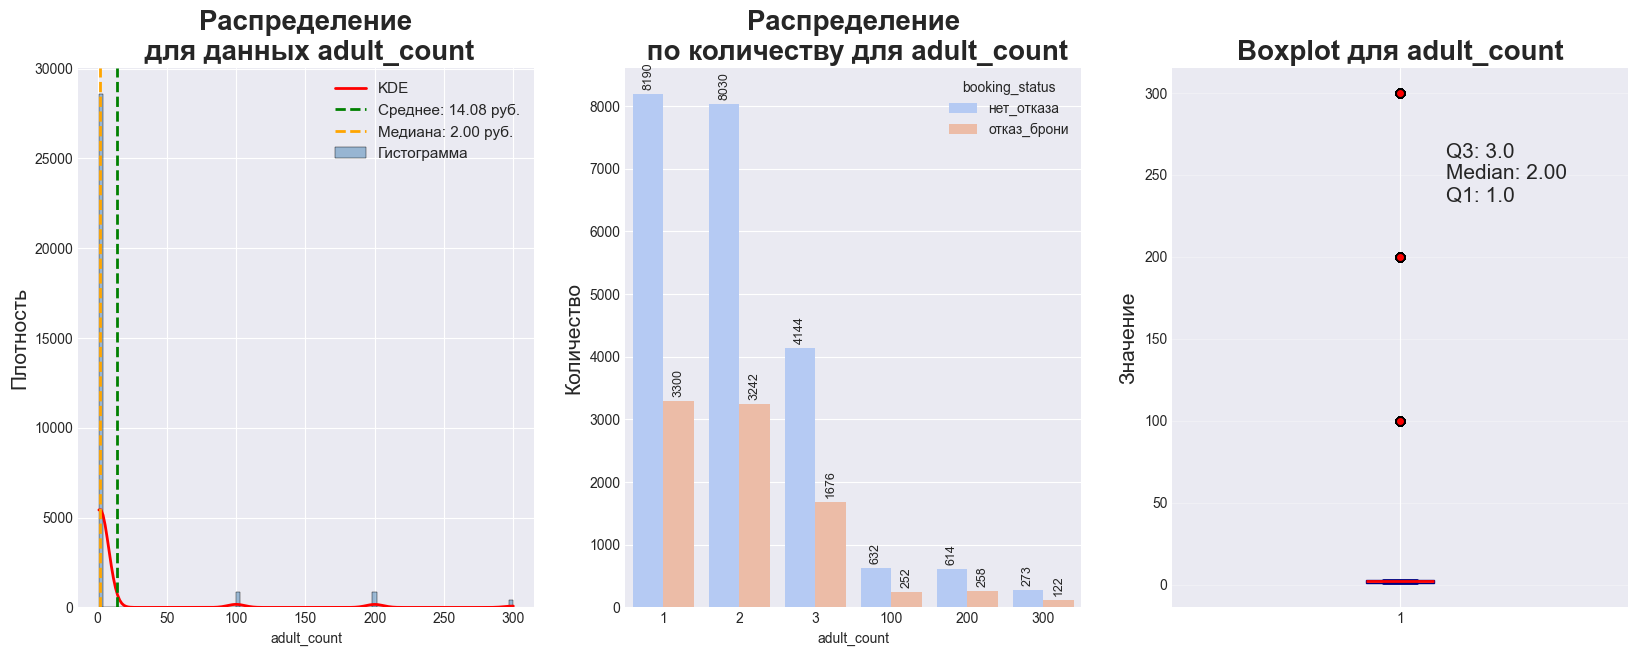

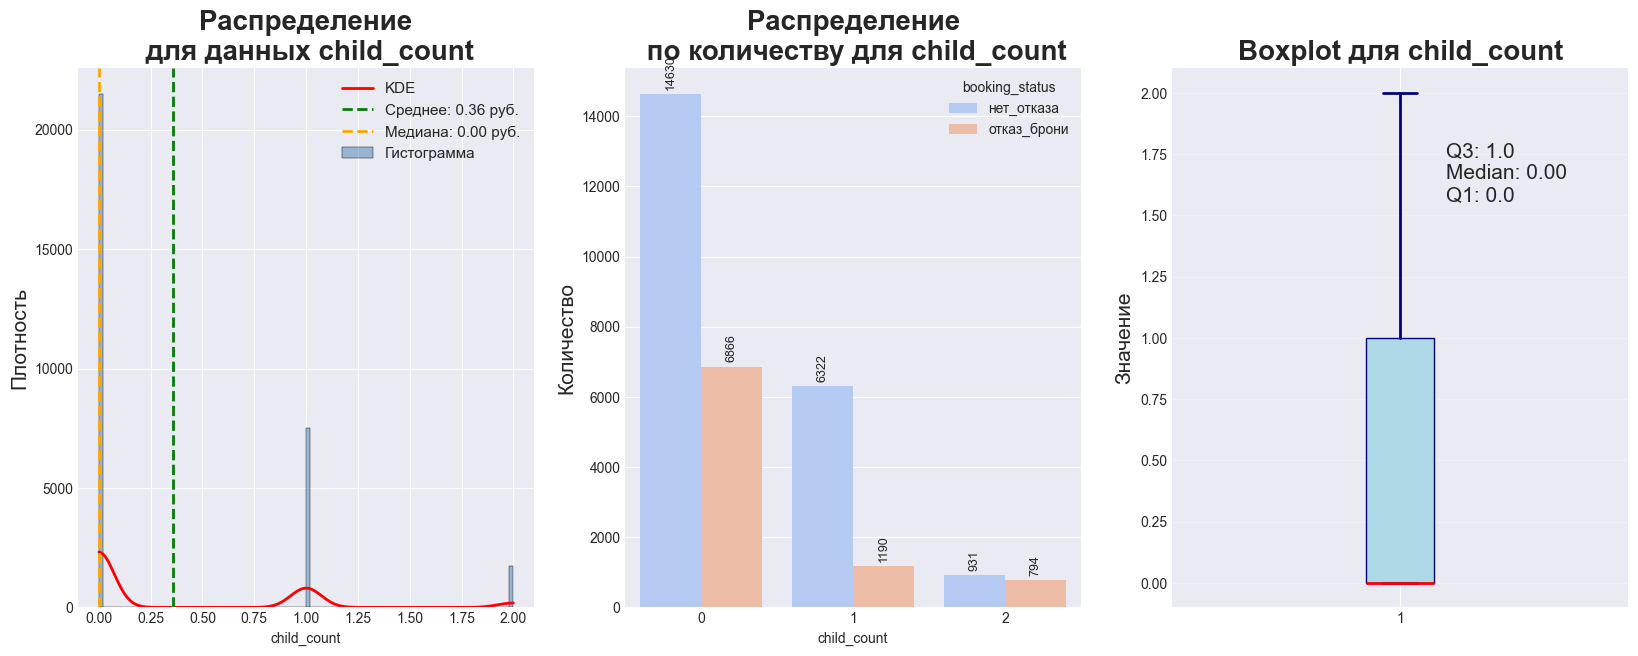

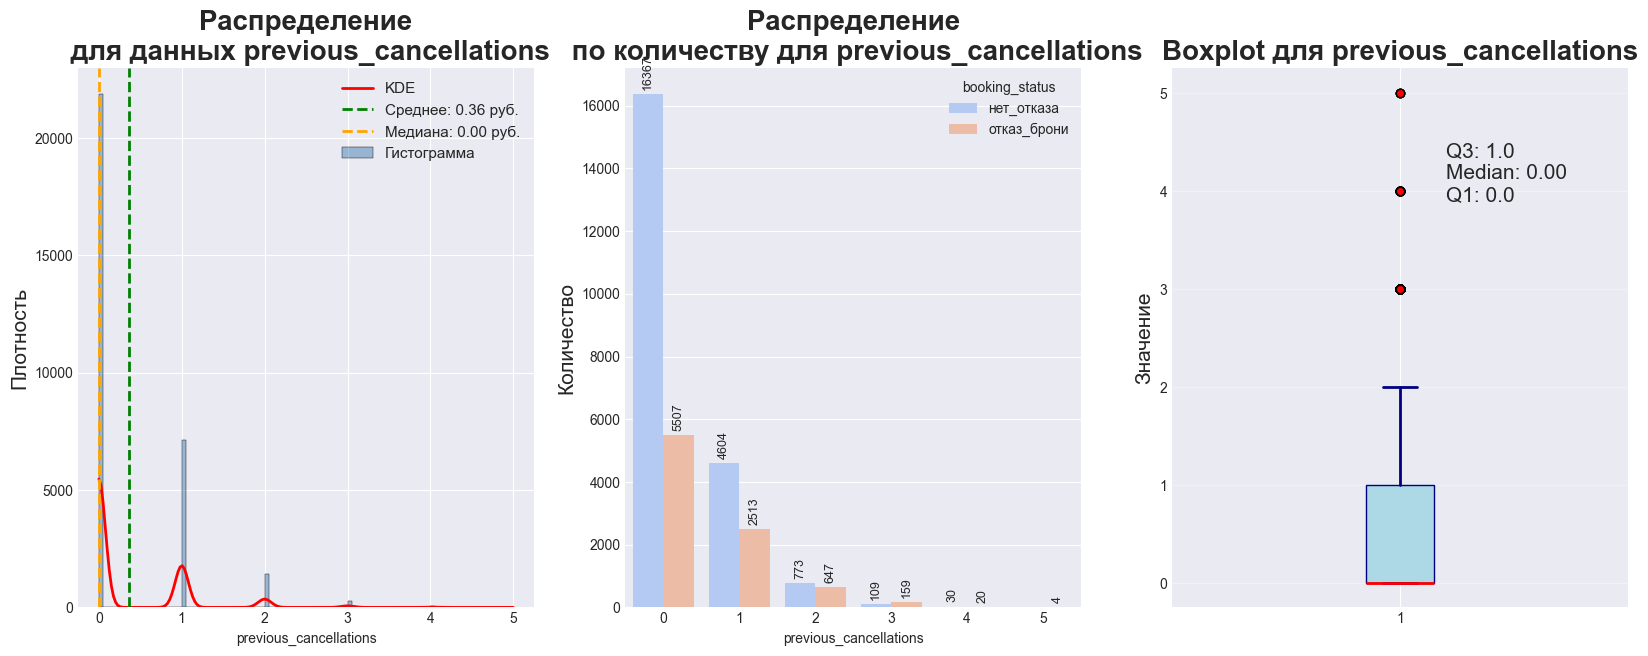

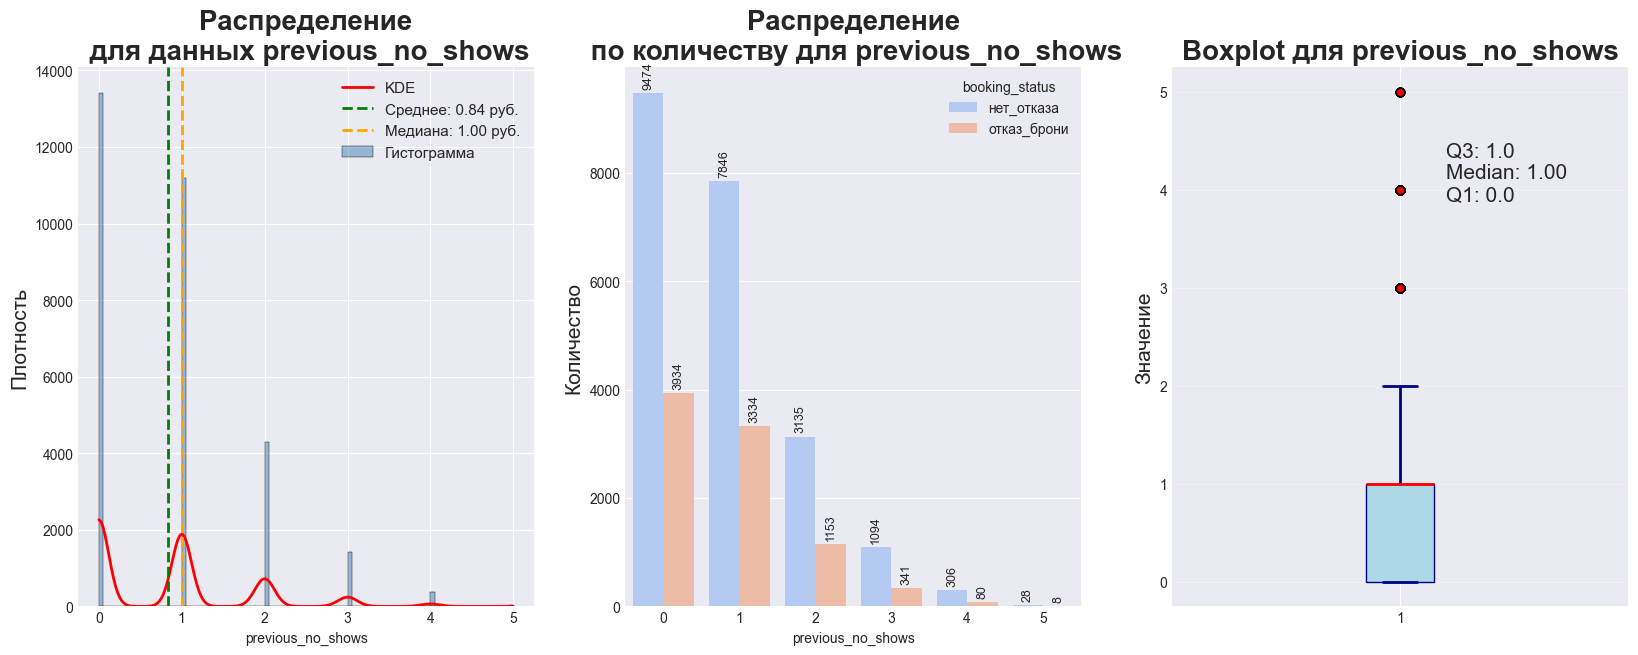

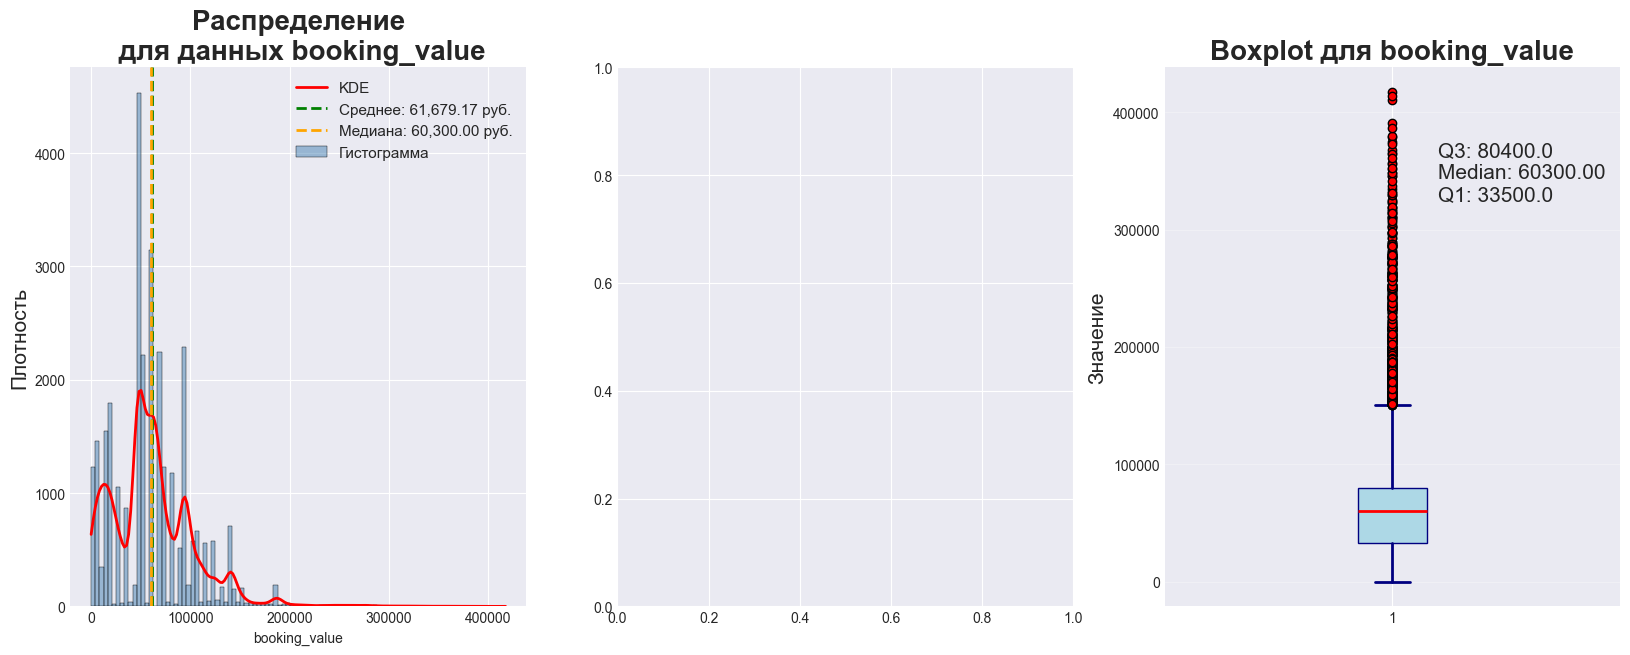

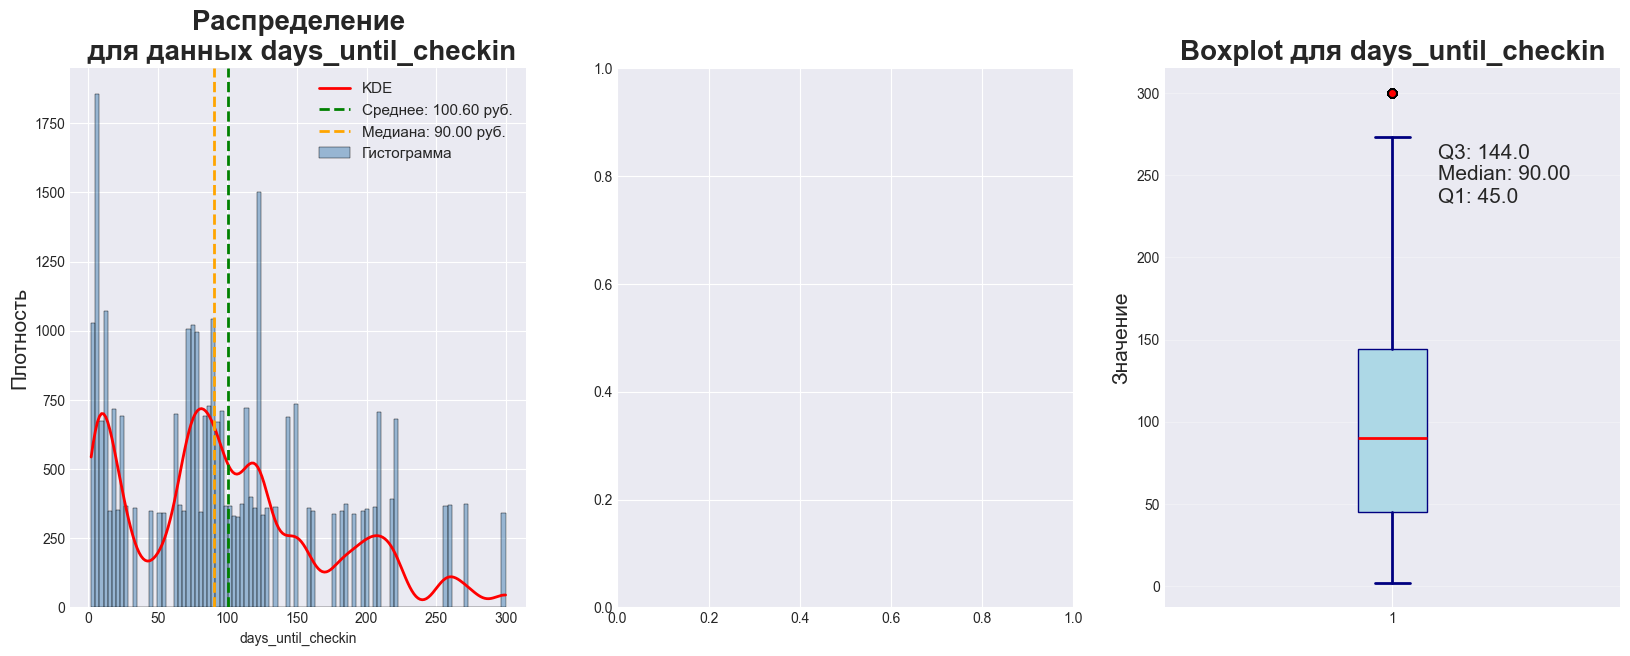

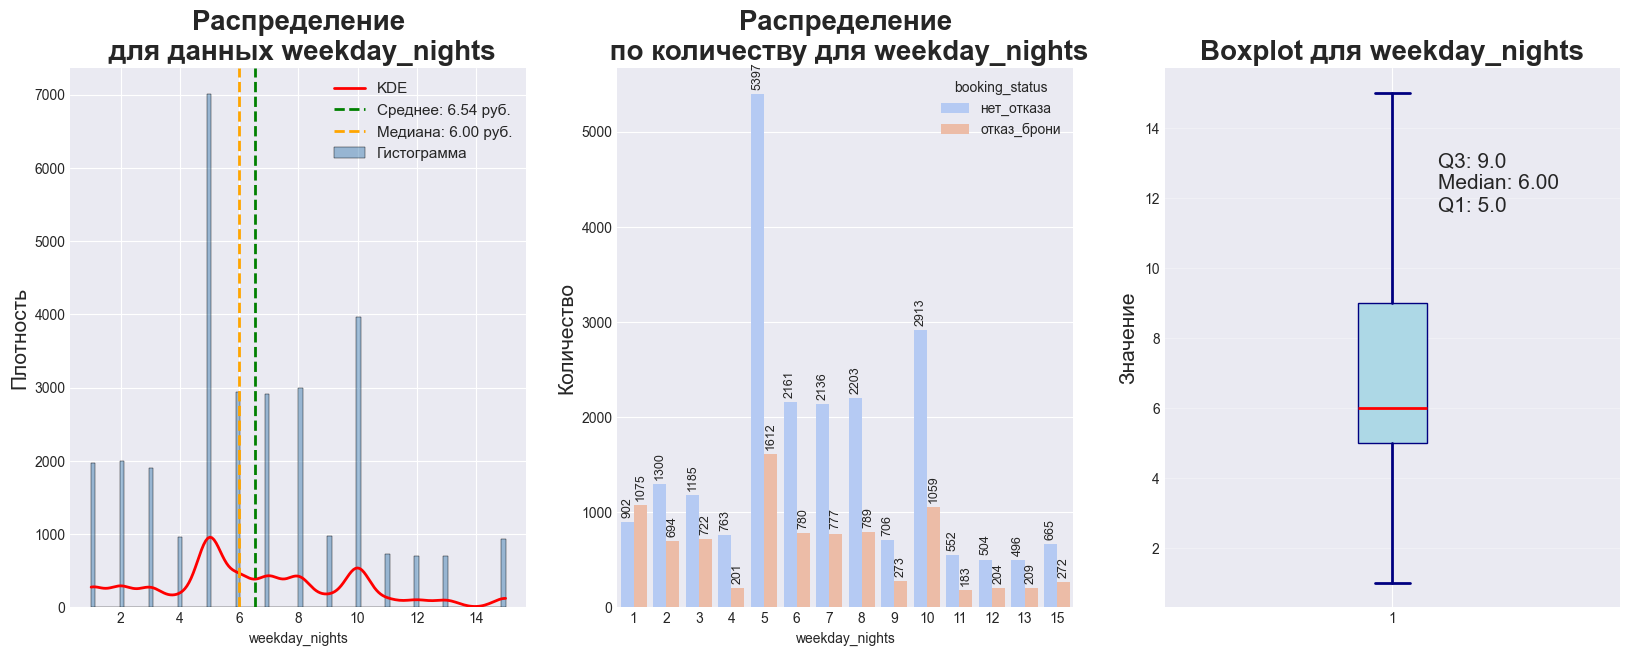

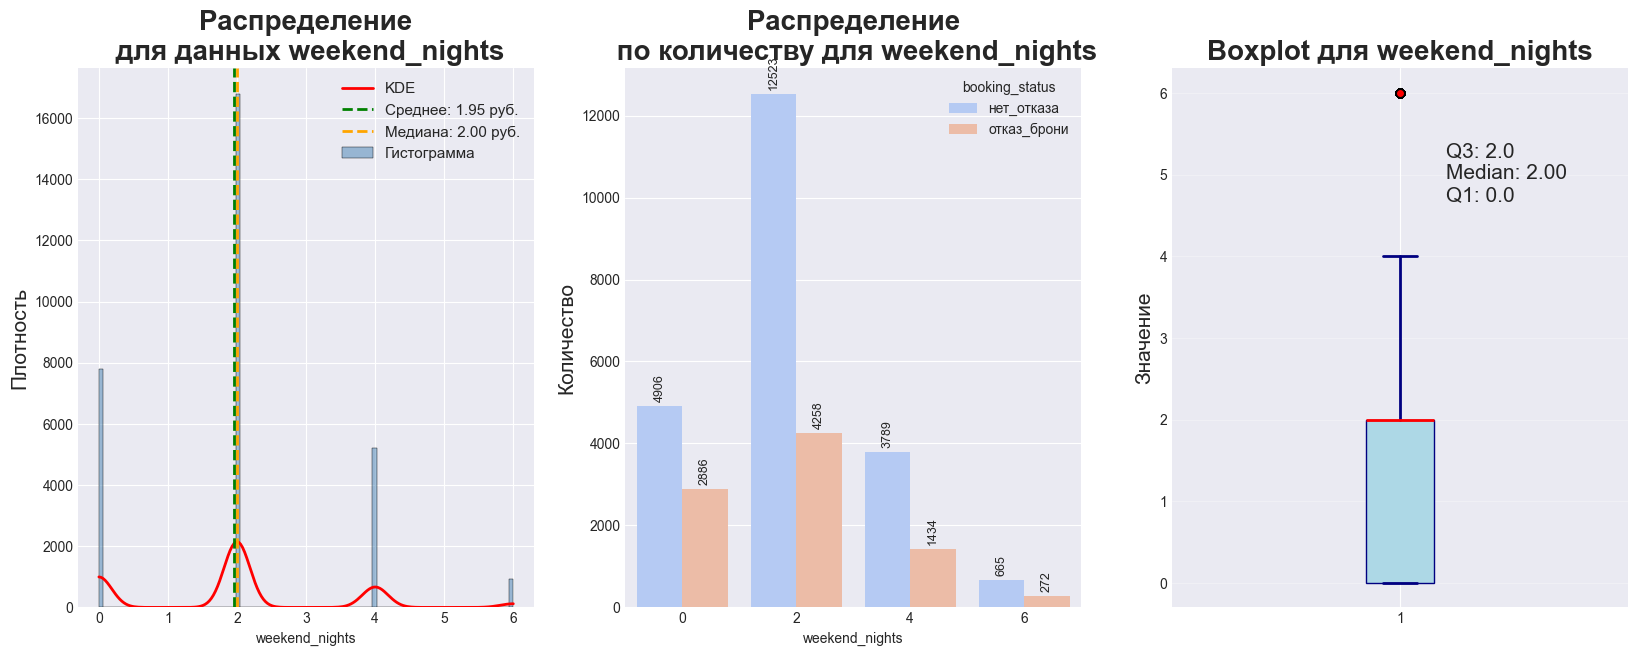

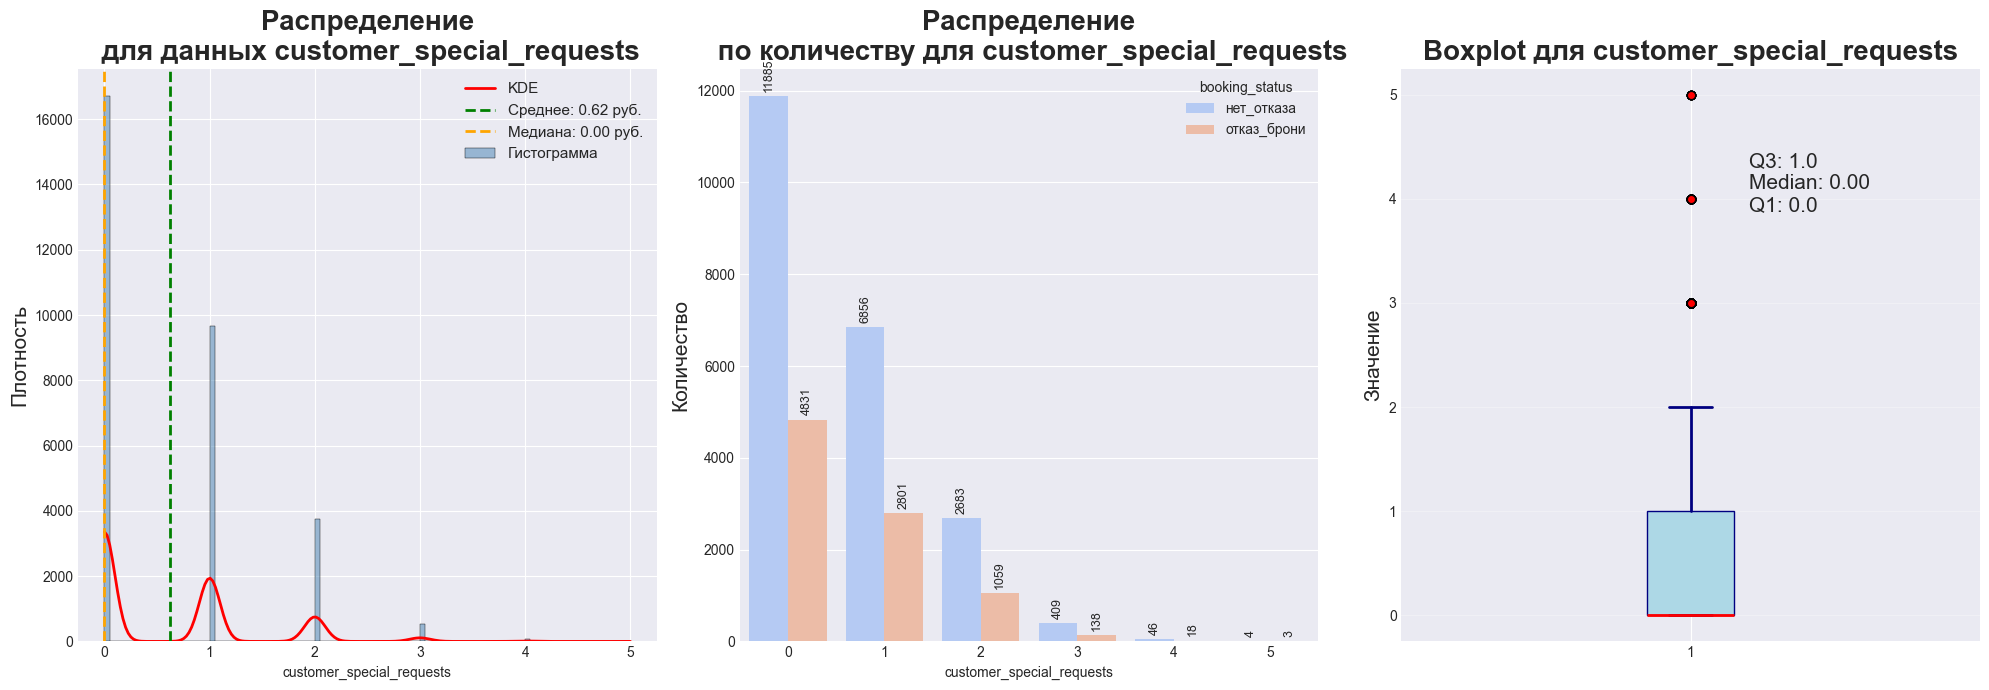

In [18]:
# Выводим графики для датасета df_bookings_drop_dupl
for col in numeric_cols_booking:
    _, axes = plt.subplots(1, 3, figsize=(20, 7))
    print_histplot(df_bookings_drop_dupl, col, axes[0])
    print_countplot(df_bookings_drop_dupl, col, axes[1], 'booking_status', 'coolwarm')
    print_boxplot(df_bookings_drop_dupl, col, axes[2])

plt.tight_layout()
plt.show()

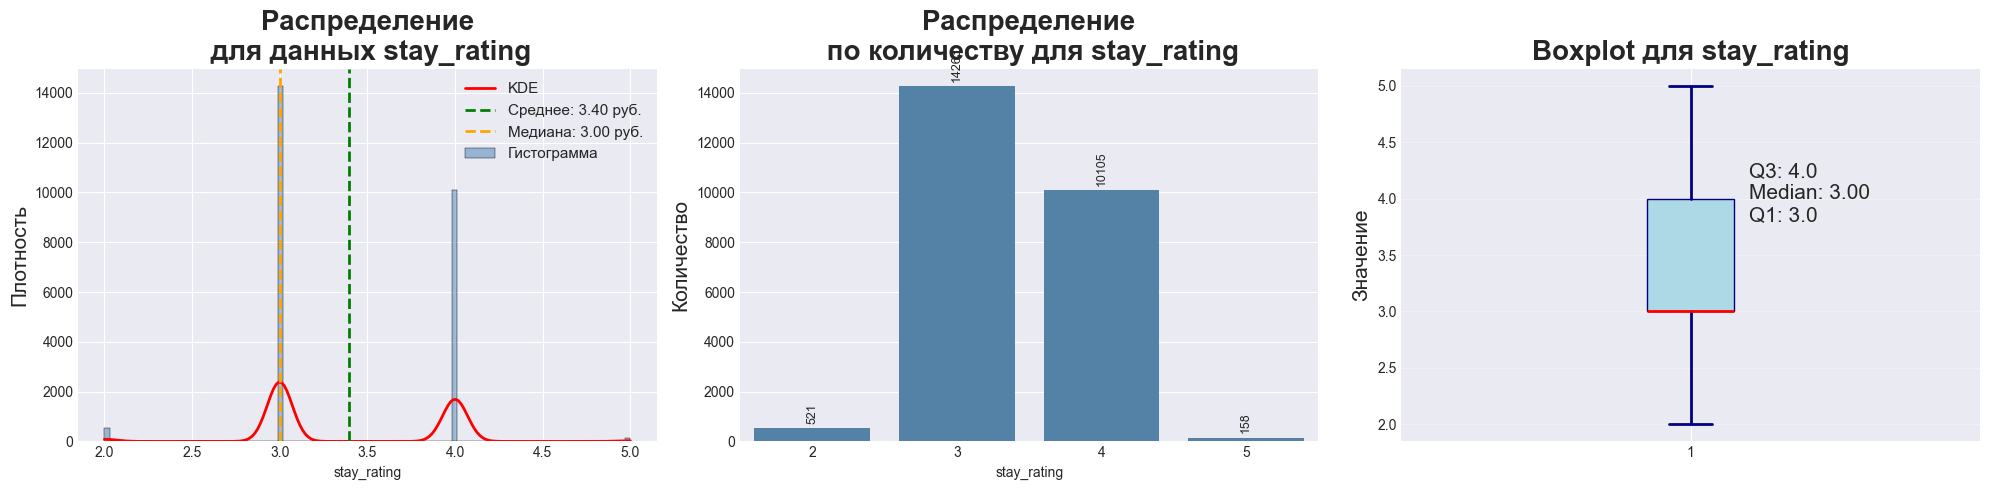

In [19]:
# Выводим графики для датасета df_reviews_drop_dupl
for col in numeric_cols_reviews:
    _, axes = plt.subplots(1, 3, figsize=(20, 5))
    print_histplot(df_reviews_drop_dupl, col, axes[0])
    print_countplot(df_reviews_drop_dupl, col, axes[1])
    print_boxplot(df_reviews_drop_dupl, col, axes[2])

plt.tight_layout()
plt.show()

#### Анализ выбросов

In [20]:
# Функция рассчета выбросов
def mark_iqr_outliers(series): 
    q1 = series.quantile(0.25) 
    q3 = series.quantile(0.75) 
    iqr = q3 - q1 
    lower_bound = q1 - 1.5 * iqr 
    upper_bound = q3 + 1.5 * iqr 
    return ~series.between(lower_bound, upper_bound) 

In [21]:
# Определяем количество выбросов для датасета df_bookings
print('Анализ выбросов для датасета df_bookings\n')
for col in numeric_cols_booking: 
    outliers = mark_iqr_outliers(df_bookings_drop_dupl[col]) 
    print(f"Признак '{col}': найдено {outliers.sum()} выбросов по IQR")

Анализ выбросов для датасета df_bookings

Признак 'adult_count': найдено 2151 выбросов по IQR
Признак 'child_count': найдено 0 выбросов по IQR
Признак 'previous_cancellations': найдено 322 выбросов по IQR
Признак 'previous_no_shows': найдено 1857 выбросов по IQR
Признак 'booking_value': найдено 866 выбросов по IQR
Признак 'days_until_checkin': найдено 340 выбросов по IQR
Признак 'weekday_nights': найдено 0 выбросов по IQR
Признак 'weekend_nights': найдено 937 выбросов по IQR
Признак 'customer_special_requests': найдено 618 выбросов по IQR


In [22]:
# Определяем количество выбросов для датасета df_reviews
print('Анализ выбросов для датасета df_reviews\n')
for col in numeric_cols_reviews: 
    outliers = mark_iqr_outliers(df_reviews_drop_dupl[col]) 
    print(f"Признак '{col}': найдено {outliers.sum()} выбросов по IQR")

Анализ выбросов для датасета df_reviews

Признак 'stay_rating': найдено 0 выбросов по IQR


In [23]:
# Исправляем выбросы
mask = df_bookings_drop_dupl['adult_count'] >= 100
df_bookings_drop_dupl['adult_count'] = df_bookings_drop_dupl['adult_count'].where(~mask, df_bookings_drop_dupl['adult_count'] // 100)

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Верно! Здесь явная ошибка записи. Нужно убрать нули у аномальных значений.</font>

In [24]:
# Удаляем строки с нуливыми ценнами
print(f'Броней с booking_value = 0: {(df_bookings_drop_dupl["booking_value"] == 0).sum()}')
print(f'Строк до очистки: {len(df_bookings_drop_dupl)}')

mask = df_bookings_drop_dupl['booking_value'] == 0
df_bookings_drop_dupl = df_bookings_drop_dupl[~mask]
print(f'Строк после очистки: {len(df_bookings_drop_dupl)}')


Броней с booking_value = 0: 1229
Строк до очистки: 30733
Строк после очистки: 29504


<span style="color: blue; font-weight: bold">Комментарий ревьюера 2: </span> ✔️\
<font color='green'> Убрали непонятные данные с нулевой стоимостью.</font>

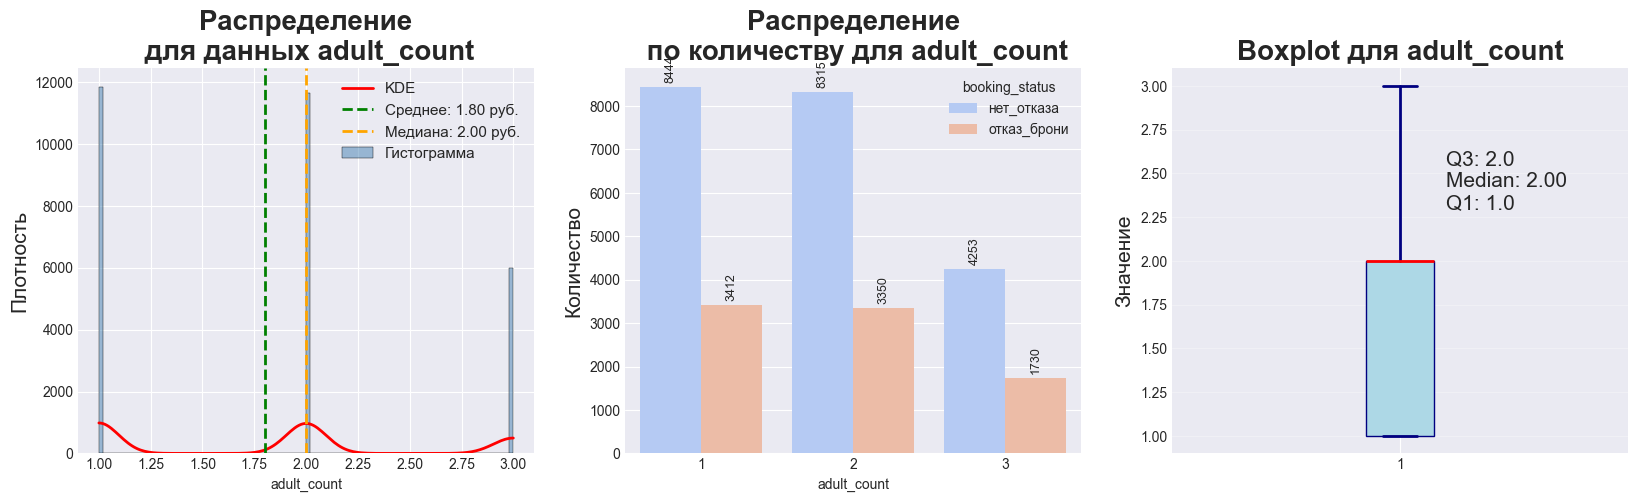

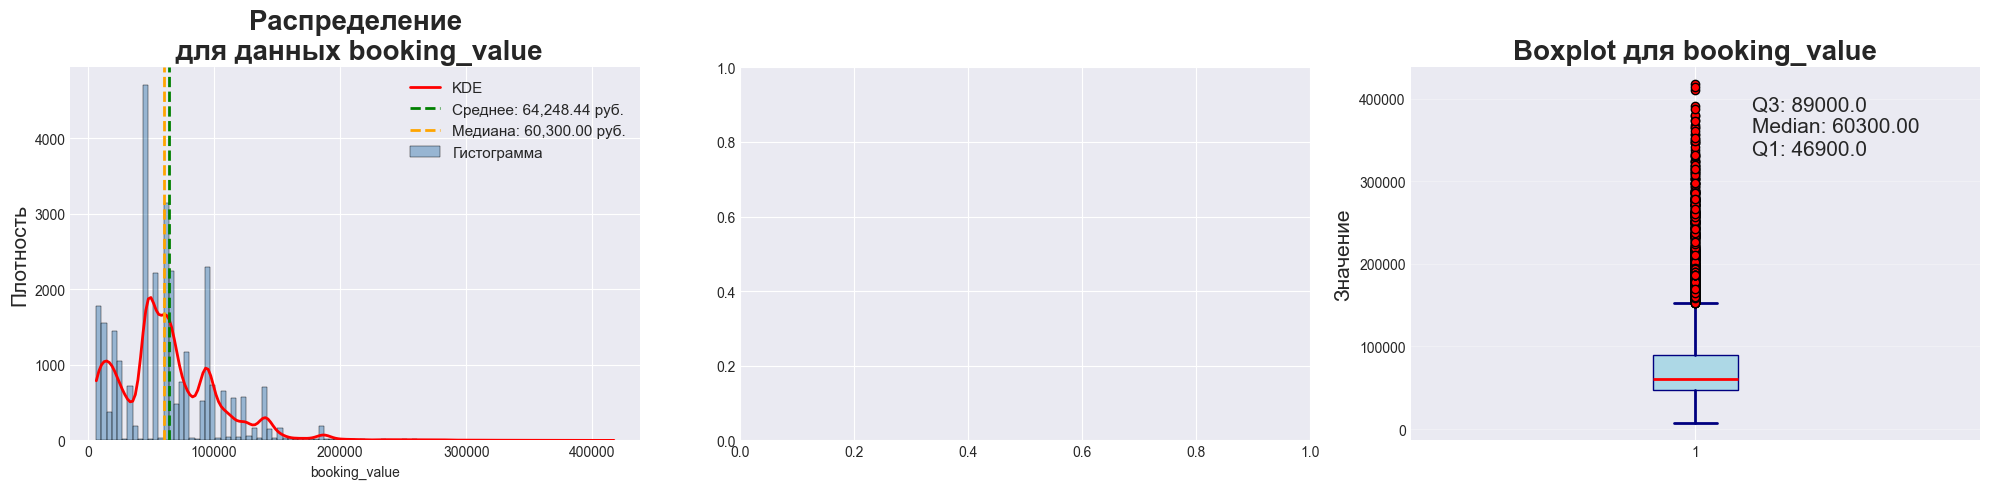

In [25]:
# Выводим графики
for col in ['adult_count', 'booking_value']:
    _, axes = plt.subplots(1, 3, figsize=(20, 5))
    print_histplot(df_bookings_drop_dupl, col, axes[0])
    print_countplot(df_bookings_drop_dupl, col, axes[1], 'booking_status', 'coolwarm')
    print_boxplot(df_bookings_drop_dupl, col, axes[2])

plt.tight_layout()
plt.show()

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>~~Есть много нулевых значений стоимости.
 Причём и у тех кто отменил бронь, и у тех, кто не отменял.
 В данных не должно так быть. Стоимость номера всегда есть. Поэтому, считаем,
 что данные строки по бронированию не качественные. И лучше от них сразу избавиться.~~</font>

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Пропустил данную ошибку в данных. Добавил код для удаления строк с нулевыми ценами за бронирование</span>


<font color='blue'><b>Комментарий ревьюера 2: </b></font> ✔️\
<font color='green'> 👍</font>

#### Анализ категориальных и булевых признаков

In [ ]:
# Определяем категориальные признаки
category_cols_booking = df_bookings_drop_dupl.select_dtypes(include=['object', 'bool']).columns.to_list()
category_cols_booking.remove('booking_id')

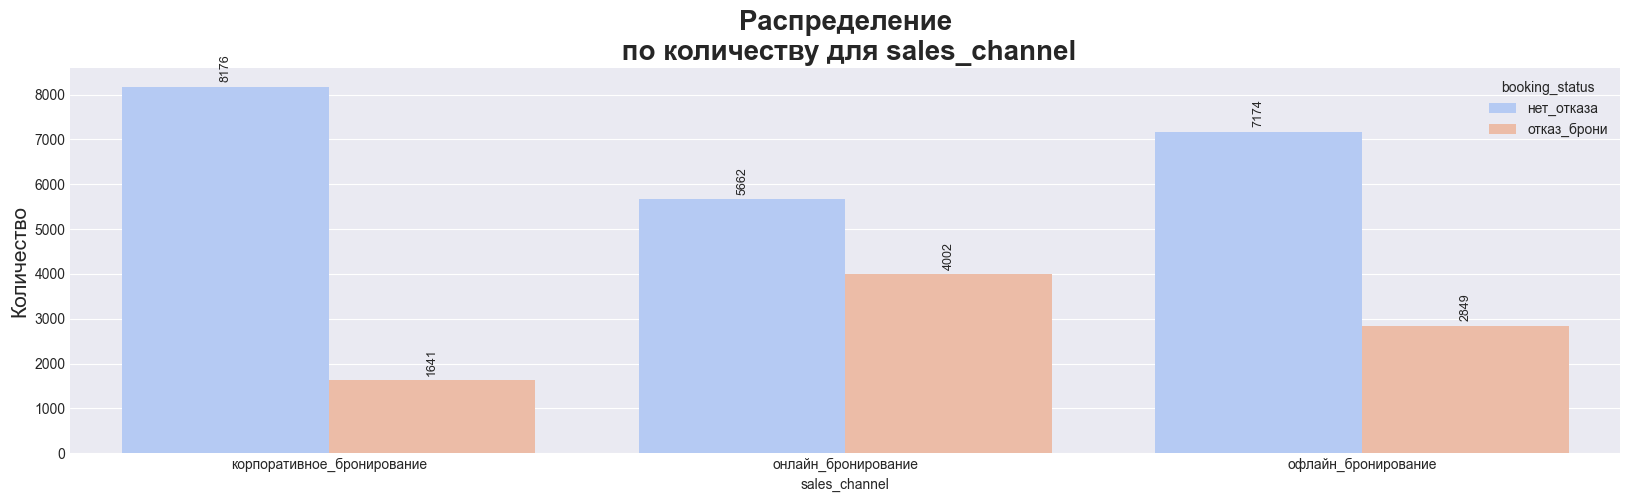

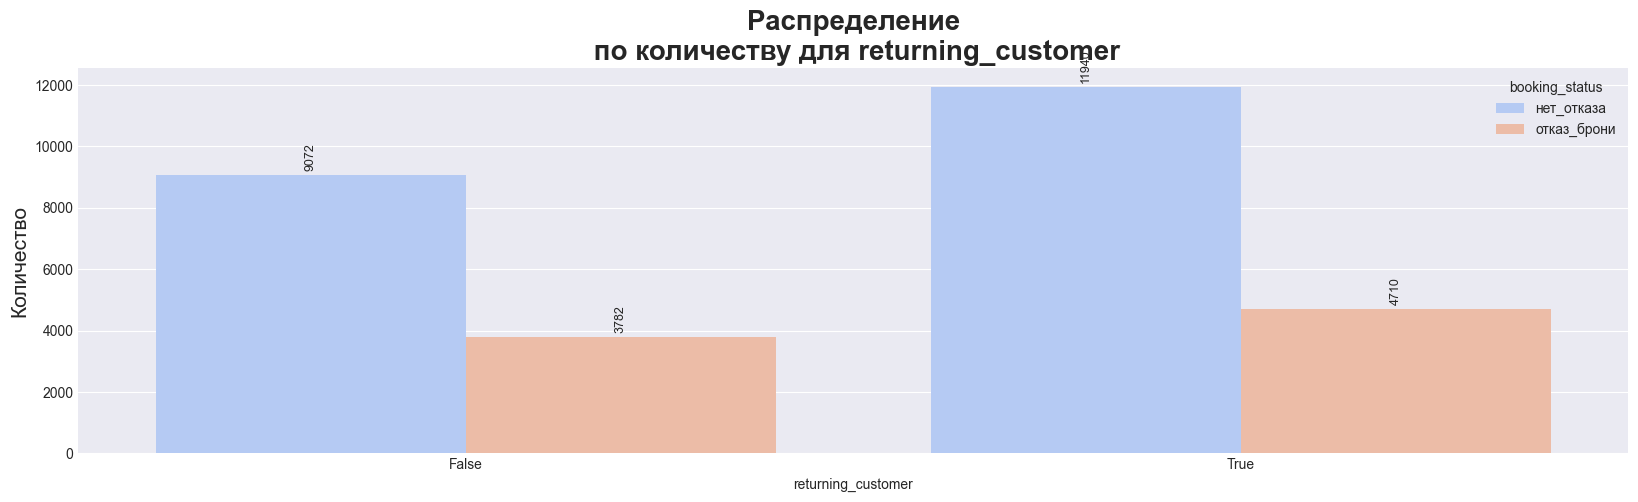

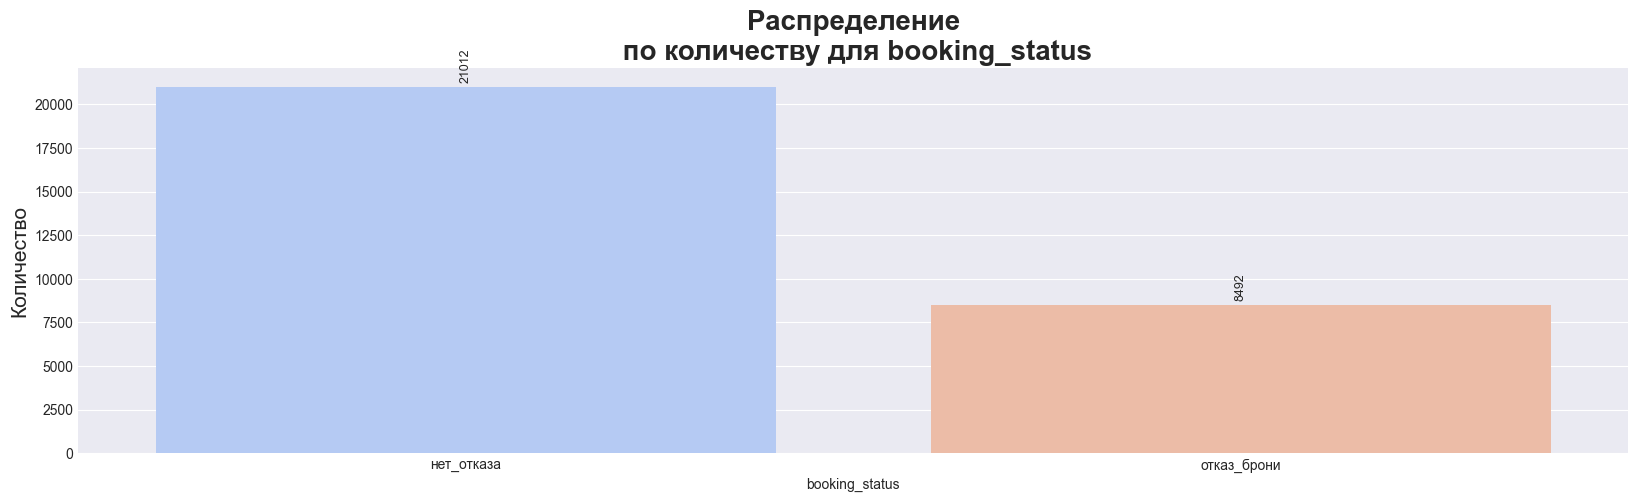

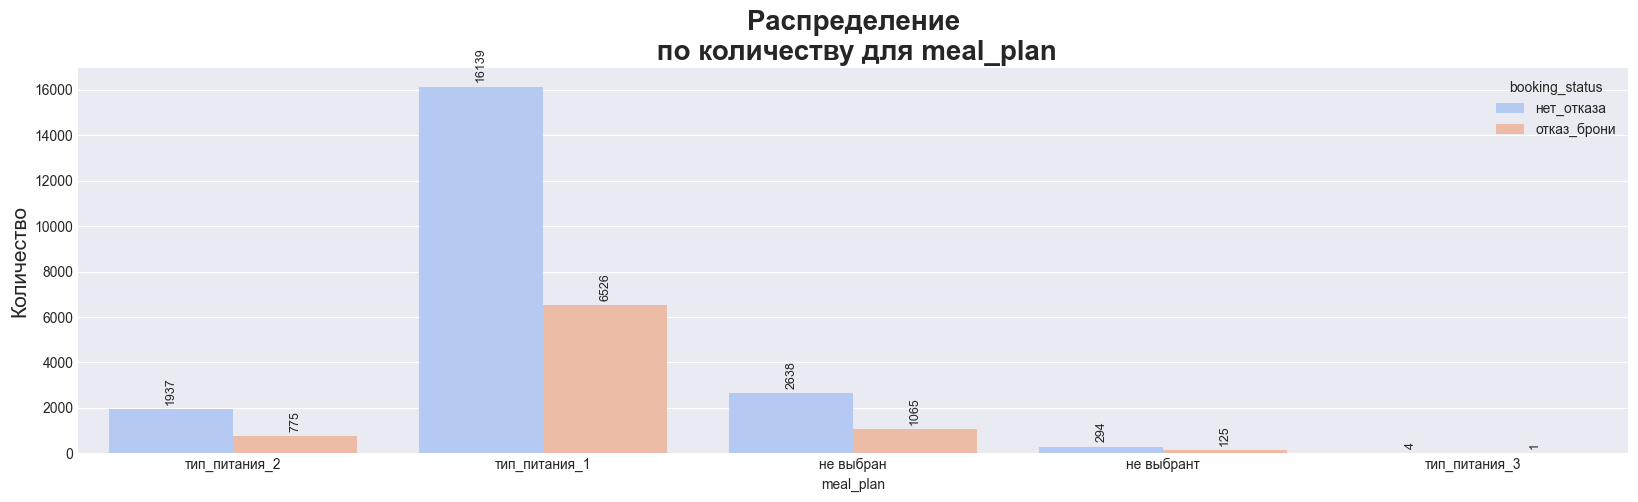

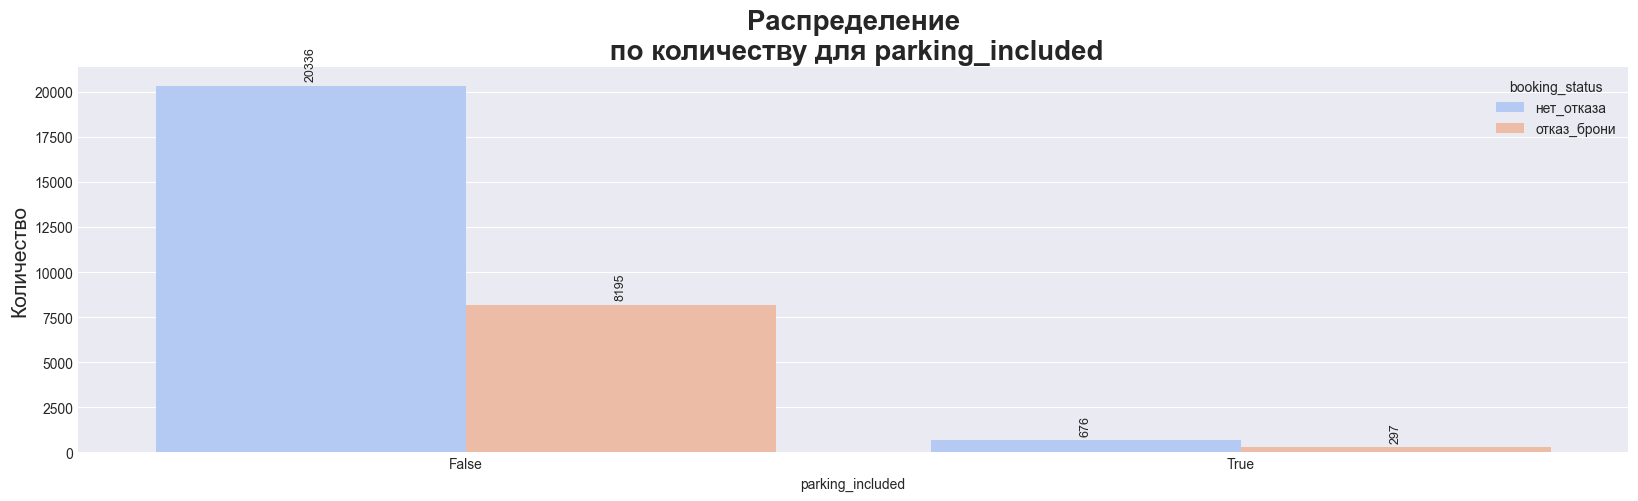

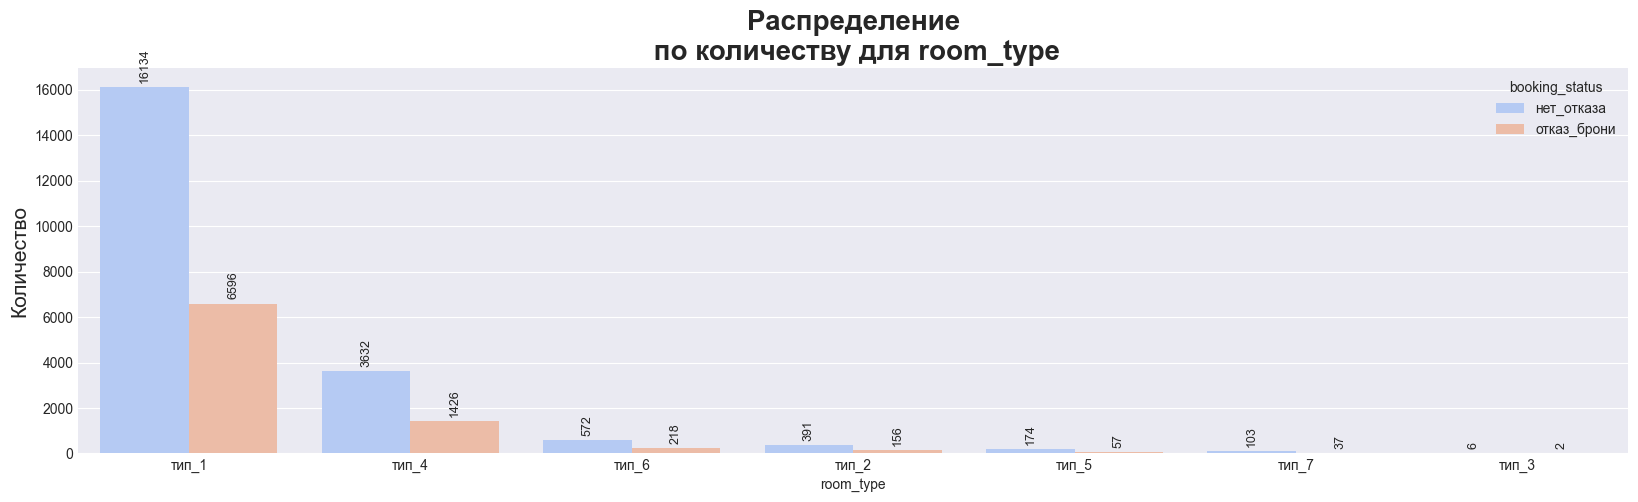

In [27]:
for col in category_cols_booking:
    _, axes = plt.subplots(1, 1, figsize=(20, 5))
    print_countplot(df_bookings_drop_dupl, col, axes, 'booking_status', 'coolwarm')

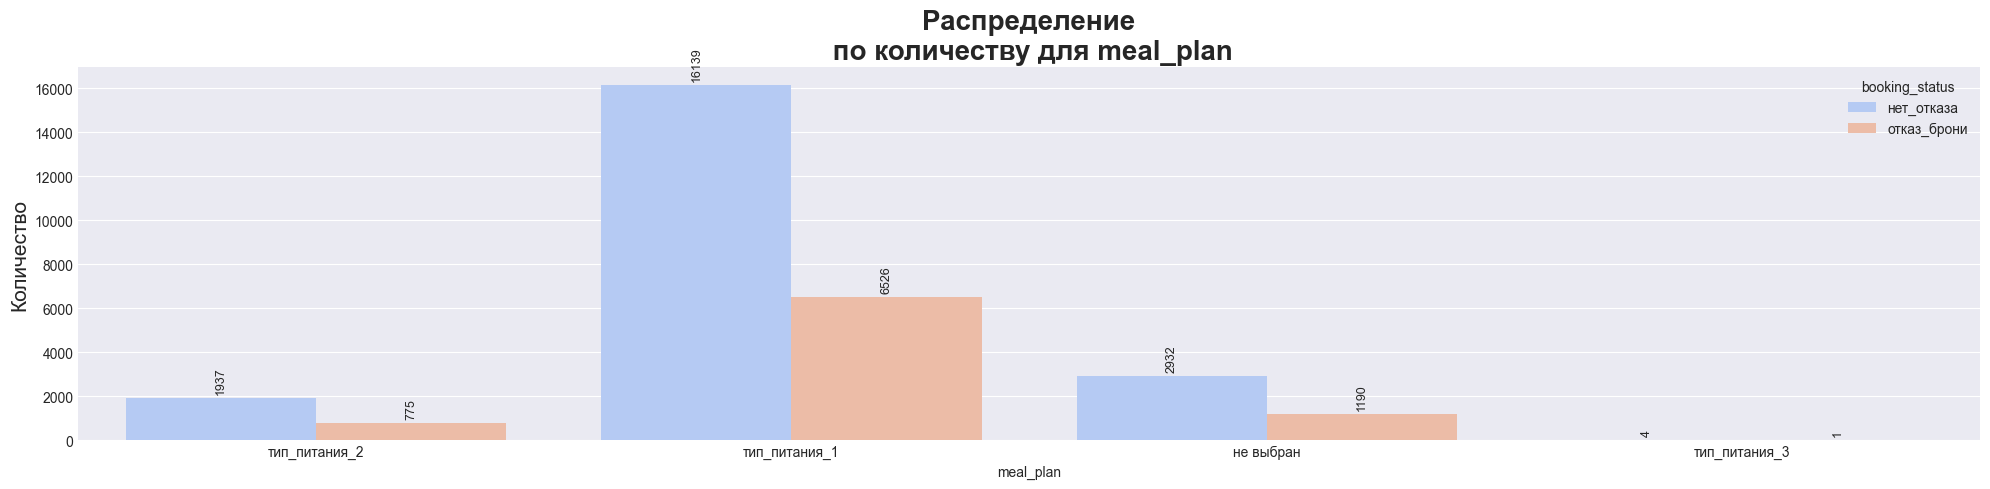

In [28]:
# Исправляем опечатки в признаке 'meal_plan'
df_bookings_drop_dupl['meal_plan'] = df_bookings_drop_dupl['meal_plan'].replace('не выбрант', 'не выбран')

# Выводим графики
_, axes = plt.subplots(1, 1, figsize=(20, 5))
print_countplot(df_bookings_drop_dupl, 'meal_plan', axes, 'booking_status', 'coolwarm')

plt.tight_layout()
plt.show()


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'>Отлично, поправили опечатку!</font>

#### Анализ признаков с датами

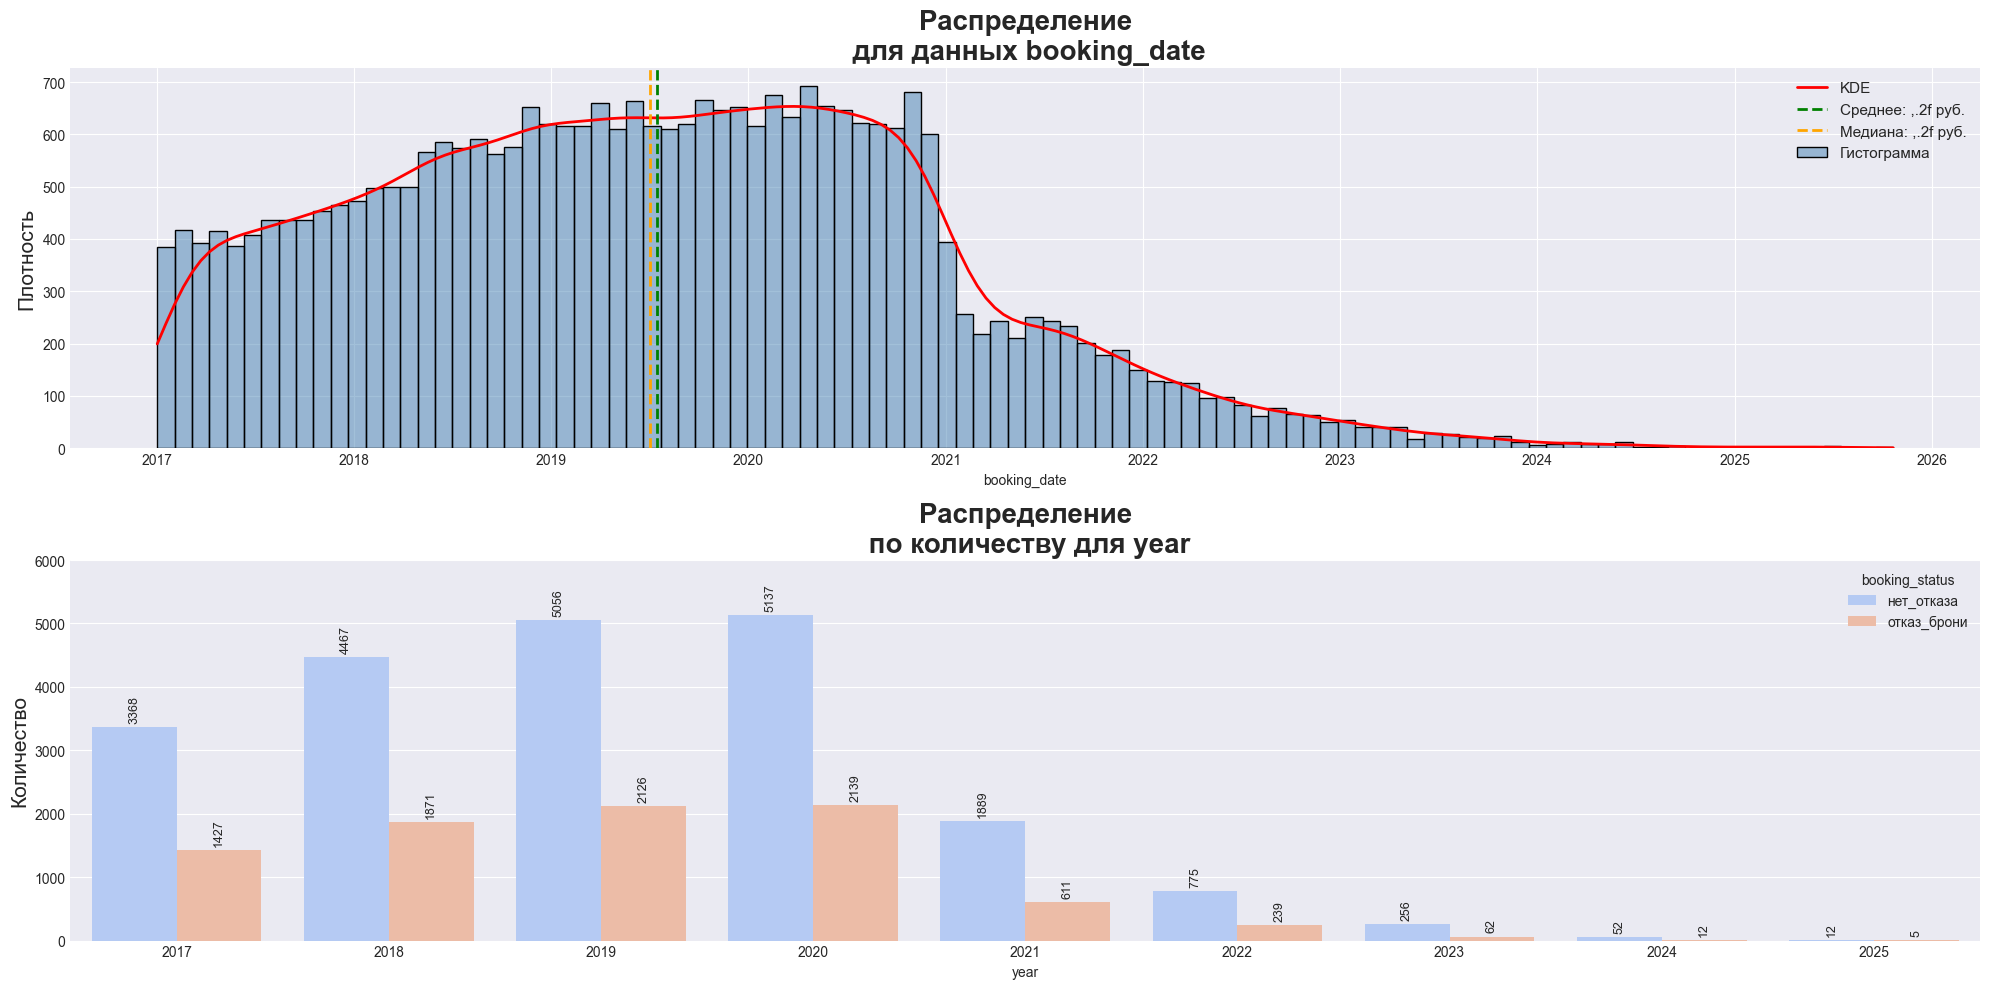

In [29]:
# Выделим из даты год 
df_bookings_date = df_bookings_drop_dupl.copy()
df_bookings_date['year'] = df_bookings_date['booking_date'].dt.strftime('%Y')

# Выводим графики
_, axes = plt.subplots(2, 1, figsize=(20, 10), gridspec_kw={'height_ratios': [1, 1]})
print_histplot(df_bookings_date, 'booking_date', axes[0])
print_countplot(df_bookings_date.sort_values('year'), 'year', axes[1], 'booking_status', 'coolwarm')

axes[1].set_ylim(0, axes[1].get_yticks().max()) 
plt.tight_layout()

#### Анализ корреляционной матрицы

c:\Python Project\Sprint17_Booking_Cancellation_Predict\.ml_env_sprint17\Lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable booking_date is large: 2440. Are you sure this is not an interval variable? Analysis for pairs of variables including booking_date can be slow.
  warnings.warn(


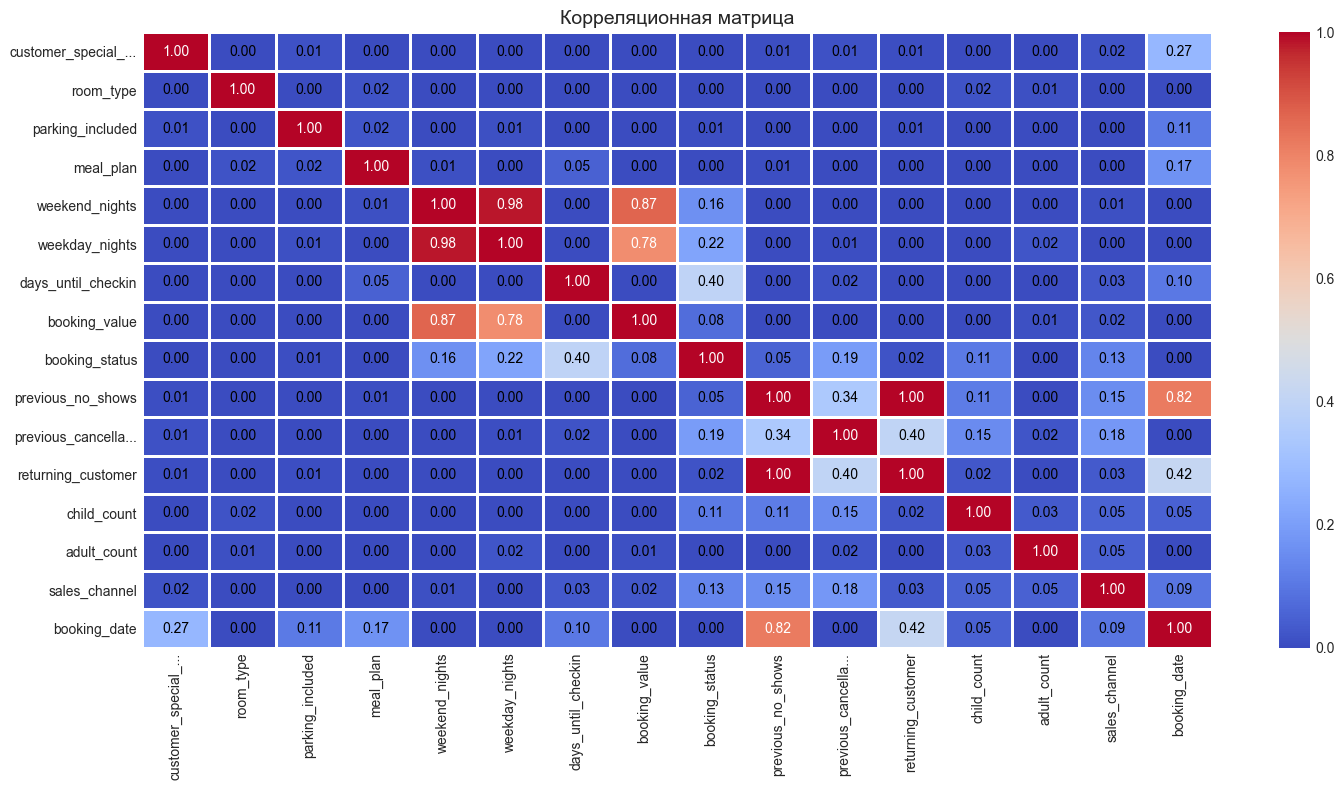

In [30]:
# Удаляем уникальный номер брони
matrix_df = df_bookings_drop_dupl.drop(columns=['booking_id'])

# Рассчитываем матрицу для всех признаков
phik_matrix = matrix_df.phik_matrix(interval_cols=['booking_value'])

# Визуализация матрицы
plot_correlation_matrix(
    phik_matrix.values,
    x_labels=phik_matrix.columns,
    y_labels=phik_matrix.index,
    vmin=0, vmax=1,
    title='Корреляционная матрица',
    figsize=(15, 8),
    color_map='coolwarm'
)

plt.show()

#### Промежуточный вывод по загрузке и предобработка данных

**1. Загрузка данных**

Из базы данных PostgreSQL выгружены две таблицы: `hotel_bookings` (35 341 бронь) и `hotel_reviews` (25 177 отзывов). Пропусков в исходных данных не обнаружено; типы признаков приведены к корректным (даты `booking_date` и `review_date` переведены в `datetime`).

**2. EDA и предобработка**

- Выявлены и удалены явные дубликаты: 4 608 строк в `hotel_bookings` (по `booking_id`) и 130 в `hotel_reviews` (по `customer_id`, `booking_id`, `review_date`). После очистки осталось 30 733 уникальные брони.
- Проанализированы распределения числовых, категориальных и временных признаков (гистограммы с KDE, countplot'ы в разрезе `booking_status`, boxplot'ы). Доля отменённых броней составляет около 29%, что задаёт умеренную несбалансированность классов для задачи классификации.
- По методу IQR выбросы обнаружены в 7 из 9 числовых признаков. Аномалия в `adult_count` (значения ≥ 100) исправлена делением на 100 — это явная ошибка записи.
- Удалены строки с нулевой стоимостью бронирования (`booking_value = 0`): стоимость номера не может быть нулевой, такие записи считаются некачественными. После удаления осталось **29504** броней.
- Исправлена опечатка в признаке `meal_plan` (`не выбрант` → `не выбран`).
- Проанализирована динамика броней во времени: выделен год бронирования, заметны колебания объёма бронирований по годам в разрезе отмен.
- Построена корреляционная матрица на основе φ-k (phik), учитывающая как линейные, так и нелинейные зависимости. Наиболее выраженная связь с отменой брони прослеживается у таких признаков, как срок до заезда (`days_until_checkin`), история клиента (`previous_cancellations`, `previous_no_shows`) и канал продаж (`sales_channel`).

**3. Итог блока**

Данные очищены от дубликатов и некачественных записей, аномалии устранены, опечатки исправлены. Таблица `df_bookings_drop_dupl` готова к следующему шагу — объединению с данными отзывов и созданию новых признаков.

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'>Здорово,что применена `phik` для анализа и нелинейных зависимостей</font>

<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'>~~Здесь заканчивается структурный блок работы - стоит сделать промежуточные выводы о проделанной работе в блоке.~~</font>

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Добавил промежуточный вывод по итогам загрузки и предобработка данных.</span>

<font color='blue'><b>Комментарий ревьюера 2: </b></font> ✔️ <br>
<font color='green'>Здорово, что не забываешь про промежуточные выводы.</font>

### [1.4 Объединение таблиц <a id=1_4></a>](#content)

In [31]:
# Добавляем customer_id в бронирования
customer_map = df_reviews_drop_dupl[['booking_id', 'customer_id']].drop_duplicates().set_index('booking_id')['customer_id']
df_bookings_drop_dupl['customer_id'] = df_bookings_drop_dupl['booking_id'].map(customer_map)

# Разделяем: те, у кого есть customer_id (для слияния) и те, у кого нет (оставляем как есть)
has_customer = df_bookings_drop_dupl['customer_id'].notna()
df_bookings_with_customer = df_bookings_drop_dupl[has_customer].copy()
df_bookings_without_customer = df_bookings_drop_dupl[~has_customer].copy()

# Сортируем для merge_asof
df_bookings_sorted = df_bookings_with_customer.sort_values(
    ['booking_date', 'customer_id'], ascending=[True, True]
).reset_index(drop=True)

df_reviews_sorted = df_reviews_drop_dupl.sort_values(
    ['review_date', 'customer_id'], ascending=[True, True]
).reset_index(drop=True)

# Выполняем слияние
merged = pd.merge_asof(
    df_bookings_sorted,
    df_reviews_sorted[['customer_id', 'review_date', 'stay_rating', 'review_text']],
    left_on='booking_date',
    right_on='review_date',
    by='customer_id',
    direction='backward',
    allow_exact_matches=False
)

# Объединяем с теми записями, у которых не было customer_id (у них добавленные колонки будут NaN)
df_merge_booking = pd.concat([merged, df_bookings_without_customer], ignore_index=True)

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Отлично, что применяется pd.merge_asof</font>

In [32]:
# Выводим общую информацию об объеденненой таблице
primary_info(df_merge_booking, 'df_merge_bookings')

Информация о таблице: df_merge_bookings


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,customer_id,review_date,stay_rating,review_text
0,INN21754,2017-01-01,онлайн_бронирование,3,2,False,0,0,нет_отказа,67 000.000,124,8,2,тип_питания_2,False,тип_2,0,C11662,NaT,NaN,NaN
1,INN22445,2017-01-01,офлайн_бронирование,2,0,False,0,0,нет_отказа,71 200.000,85,6,2,не выбран,False,тип_1,0,C12041,NaT,NaN,NaN
2,INN11824,2017-01-01,корпоративное_бронирование,3,0,False,0,0,нет_отказа,6 700.000,63,1,0,тип_питания_1,False,тип_4,1,C6306,NaT,NaN,NaN
3,INN14477,2017-01-01,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46 900.000,85,5,2,тип_питания_1,True,тип_1,2,C7722,NaT,NaN,NaN
4,INN17387,2017-01-01,офлайн_бронирование,2,0,True,1,1,нет_отказа,73 700.000,79,9,2,тип_питания_1,False,тип_1,2,C9324,NaT,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype        
---  ------                     --------------  -----        
 0   booking_id                 29504 non-null  str          
 1   booking_date               29504 non-null  datetime64[s]
 2   sales_channel              29504 non-null  str          
 3   adult_count                29504 non-null  int64        
 4   child_count                29504 non-null  int64        
 5   returning_customer         29504 non-null  bool         
 6   previous_cancellations     29504 non-null  int64        
 7   previous_no_shows          29504 non-null  int64        
 8   booking_status             29504 non-null  str          
 9   booking_value              29504 non-null  float64      
 10  days_until_checkin         29504 non-null  int64        
 11  weekday_nights             29504 non-null  int64        
 12  weekend_nights             29

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
booking_id,29504,29504,INN21754,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_date,29504,NaN,NaN,NaN,2019-07-15 14:03:02,2017-01-01 00:00:00,2018-06-11 00:00:00,2019-07-03 00:00:00,2020-07-07 00:00:00,2025-10-22 00:00:00,NaN
sales_channel,29504,3,офлайн_бронирование,10023,NaN,NaN,NaN,NaN,NaN,NaN,NaN
adult_count,29 504.000,NaN,NaN,NaN,1.801,1.000,1.000,2.000,2.000,3.000,0.752
child_count,29 504.000,NaN,NaN,NaN,0.357,0.000,0.000,0.000,1.000,2.000,0.585
returning_customer,29504,2,True,16650,NaN,NaN,NaN,NaN,NaN,NaN,NaN
previous_cancellations,29 504.000,NaN,NaN,NaN,0.358,0.000,0.000,0.000,1.000,5.000,0.629
previous_no_shows,29 504.000,NaN,NaN,NaN,0.841,0.000,0.000,1.000,1.000,5.000,0.933
booking_status,29504,2,нет_отказа,21012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_value,29 504.000,NaN,NaN,NaN,64 248.437,6 700.000,46 900.000,60 300.000,89 000.000,417 221.200,41 683.137


**Промежуточный вывод**

- К бронированиям добавлен `customer_id`: он найден для 21 012 записей через сопоставление по `booking_id` из таблицы отзывов.

- С помощью `pd.merge_asof` (direction='backward', allow_exact_matches=False) к каждой брони подтянут последний по времени **предыдущий** отзыв того же клиента — такой подход корректно использует историю клиента без «заглядывания в будущее».

- Отзывные признаки (`stay_rating`, `review_date`, `review_text`) получили 8 021 бронь; у остальных записей они отсутствуют (`NaN`) — у клиента нет предыдущих отзывов.

- Итоговая таблица `df_merge_booking` содержит 29 504 строки и 21 колонку. Пропуски сосредоточены только в отзывных признаках, целевая переменная `booking_status` сохранена.


<font color='blue'><b>Комментарий ревьюера : </b></font> ❌\
<font color='red'>~~Вывод.~~  </font> 

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Добавил краткий вывод.</span>


<font color='blue'><b>Комментарий ревьюера 2: </b></font> ✔️\
<font color='green'> 👍</font>

### [1.5 Создание новых признаков <a id=1_5></a>](#content)

In [33]:
# Объявляем множество из стоп-слов русского языка
russian_stopwords = set(stopwords.words('russian'))

# Создаем базовую токенизацию
_word_re = re.compile(r'[а-яё]+', re.IGNORECASE)

# Объявляем функцию для токенизации текста
def tokenize_ru(text):
    return _word_re.findall(str(text).lower())

# Объявляем функцию для удаления стоп-слов
def remove_stopwords(text):
    return " ".join([word for word in text if word not in russian_stopwords])

In [34]:
def add_booking_features(df):
    """
    Создаем дополнительные признаки для датафрейма
    """
    df = df.copy()

    # Состав гостей 
    df['total_guests'] = df['adult_count'] + df['child_count']
    guests_safe = df['total_guests'].clip(lower=1)
    df['children_share'] = df['child_count'] / guests_safe
    df['adults_share'] = df['adult_count'] / guests_safe
    df['has_adults'] = (df['adult_count'] > 0).astype(int)
    df['has_children'] = (df['child_count'] > 0).astype(int)
    df['is_large_group'] = (df['total_guests'] >= 4).astype(int)

    # Длительность проживания
    df['total_nights'] = df['weekday_nights'] + df['weekend_nights']
    nights_safe = df['total_nights'].replace(0, 1)  # защита от нуля

    df['weekend_share'] = df['weekend_nights'] / nights_safe
    df['is_long_stay'] = (df['total_nights'] >= 7).astype(int)

    bins_stay = [-1, 1, 3, 6, 1000]
    labels_stay = ['single_night', 'short', 'medium', 'long']
    df['stay_length_bucket'] = pd.cut(
        df['total_nights'], bins=bins_stay, labels=labels_stay, right=True
    )

    # Стоимость    
    df['avg_price_per_night'] = df['booking_value'] / nights_safe
    df['price_per_guest'] = df['booking_value'] / guests_safe
    df['price_per_guest_per_night'] = df['booking_value'] / (guests_safe * nights_safe)  

    premium_threshold = df['booking_value'].quantile(0.75)
    df['is_premium'] = (df['booking_value'] >= premium_threshold).astype(int)
    df['log_price'] = np.log1p(df['booking_value'])

    # Календарь: дата заезда
    df['checkin_date'] = pd.to_datetime(df['booking_date']) + pd.to_timedelta(
        df['days_until_checkin'], unit='D'
    )

    # Категоризация дней до заезда
    bins = [-1, 7, 30, 90, 1000]
    labels = ['very_soon', 'soon', 'medium', 'long_ahead']
    df['days_until_checkin_bucket'] = pd.cut(
        df['days_until_checkin'], bins=bins, labels=labels, right=True
    )

    # Сервисы и канал
    df['has_meal_plan'] = (df['meal_plan'] != 'не выбран').astype(int)
    df['has_special_request'] = (df['customer_special_requests'] > 0).astype(int)
    df['request_density'] = df['customer_special_requests'] / nights_safe
    df['service_level'] = (
        df['parking_included'].astype(int)
        + df['has_meal_plan']
        + df['has_special_request']
    )

    # История клиента (из готовых признаков)
    df['total_issues'] = df['previous_cancellations'] + df['previous_no_shows']
    df['has_cancelled_before'] = (df['previous_cancellations'] > 0).astype(int)
    df['has_no_show_before'] = (df['previous_no_shows'] > 0).astype(int)
    df['issues_rate'] = df['total_issues'] / (df['total_issues'] + 1)

    # Отзывы (прошлый отзыв клиента)
    df['has_review'] = df['stay_rating'].notna().astype(int)

    review_gap = (
        pd.to_datetime(df['booking_date']) - pd.to_datetime(df['review_date'])
    ).dt.days
    df['days_since_review'] = review_gap.clip(lower=0).fillna(-1)

    df['rating_bucket'] = pd.cut(
        df['stay_rating'],
        bins=[0, 2.5, 3.5, 5.5],
        labels=['low', 'mid', 'high']
    )
    df['rating_bucket'] = df['rating_bucket'].astype('object').fillna('no_review')

    # Взаимодействия
    df['prev_cancel_x_noshow'] = (
        df['previous_cancellations'] * df['previous_no_shows']
    )
    df['returning_x_cancels'] = (
        df['returning_customer'].astype(int) * df['previous_cancellations']
    )
    df['guests_x_weekend'] = df['total_guests'] * df['weekend_share']
    df['requests_x_parking'] = (
        df['customer_special_requests'] * df['parking_included'].astype(int)
    )

    return df

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> 👍</font>

In [35]:
def add_booking_features_old(df):
    """
    Создаем дополнительные признаки для датафрейма
    """
    df = df.copy()

    # Общая длительность прибывания
    df['total_nights'] = df['weekday_nights'] + df['weekend_nights']

    # Стоимость одной ночи за гостя
    guests_count = df['adult_count'] + df['child_count'] + 1 # защита от нуля и появления ошибки ZeroDivisionError
    nights_count = df['total_nights'].replace(0, 1) # временная замена для расчета
    df['price_per_guest_per_night'] = df['booking_value'] / (guests_count * nights_count)

    # Категоризация дней до заезда
    bins = [-1, 7, 30, 90, 1000]
    labels = ['very_soon', 'soon', 'medium', 'long_ahead']
    df['days_until_checkin_bucket'] = pd.cut(
        df['days_until_checkin'],
        bins=bins,
        labels=labels,
        right=True
    )

    return df

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> 👍</font>

In [36]:
def feature_extraction_text(df):
    """
    Функция токенезирует признак с отзывами
    """
    df = df.copy()

    # Заполняем пропуски пустой строкой, чтобы TF-IDF не падал
    texts = df['review_text'].fillna('').astype(str)

    processed_texts = []
    for text in texts:
        tokens = tokenize_ru(text)
        filtered_tokens = remove_stopwords(tokens)
        processed_texts.append(filtered_tokens)

    vectorizer = TfidfVectorizer(
        max_features=50,
        ngram_range=(1, 2)
    )

    tfidf_matrix = vectorizer.fit_transform(processed_texts)

    # Превращаем в DataFrame с понятными именами колонок
    tfidf_df = pd.DataFrame(
        tfidf_matrix.toarray(),
        columns=[f'review_tfidf_{i}' for i in range(tfidf_matrix.shape[1])],
        index=df.index
    )

    return pd.concat([df.drop(columns=['review_text']), tfidf_df], axis=1)

In [37]:
def extract_time_features(df):
    """Функция для извлечения новых признаков из datetime"""
    df = df.copy()
    
    for col in df.select_dtypes(include='datetime').columns.to_list():
        # Если дата пропущена, заполняем дефолтной эпохой, чтобы .dt работал без ошибок
        temp_date = df[col].fillna(pd.Timestamp('1970-01-01'))
        
        df[f'{col}_year'] = temp_date.dt.year
        df[f'{col}_month'] = temp_date.dt.month
        df[f'{col}_day_of_week'] = temp_date.dt.day_of_week 
        
        # Циклические признаки для месяца
        df[f'{col}_month_sin'] = np.sin(2 * np.pi * df[f'{col}_month'] / 12)
        df[f'{col}_month_cos'] = np.cos(2 * np.pi * df[f'{col}_month'] / 12)
        
        # Удаляем исходный признак
        df.drop([col], axis=1, inplace=True)

    return df

In [38]:
# Создаем новые признаки и токенизацию отзывов
df_merge_booking_with_features = add_booking_features(df_merge_booking)
df_merge_booking_with_features = extract_time_features(df_merge_booking_with_features)
df_merge_booking_with_features = feature_extraction_text(df_merge_booking_with_features)
df_merge_booking_with_features

,booking_id,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,customer_id,stay_rating,total_guests,children_share,adults_share,has_adults,has_children,is_large_group,total_nights,weekend_share,is_long_stay,stay_length_bucket,avg_price_per_night,price_per_guest,price_per_guest_per_night,is_premium,log_price,days_until_checkin_bucket,has_meal_plan,has_special_request,request_density,service_level,total_issues,has_cancelled_before,has_no_show_before,issues_rate,has_review,days_since_review,rating_bucket,prev_cancel_x_noshow,returning_x_cancels,guests_x_weekend,requests_x_parking,booking_date_year,booking_date_month,booking_date_day_of_week,booking_date_month_sin,booking_date_month_cos,review_date_year,review_date_month,review_date_day_of_week,review_date_month_sin,review_date_month_cos,checkin_date_year,checkin_date_month,checkin_date_day_of_week,checkin_date_month_sin,checkin_date_month_cos,review_tfidf_0,review_tfidf_1,review_tfidf_2,review_tfidf_3,review_tfidf_4,review_tfidf_5,review_tfidf_6,review_tfidf_7,review_tfidf_8,review_tfidf_9,review_tfidf_10,review_tfidf_11,review_tfidf_12,review_tfidf_13,review_tfidf_14,review_tfidf_15,review_tfidf_16,review_tfidf_17,review_tfidf_18,review_tfidf_19,review_tfidf_20,review_tfidf_21,review_tfidf_22,review_tfidf_23,review_tfidf_24,review_tfidf_25,review_tfidf_26,review_tfidf_27,review_tfidf_28,review_tfidf_29,review_tfidf_30,review_tfidf_31,review_tfidf_32,review_tfidf_33,review_tfidf_34,review_tfidf_35,review_tfidf_36,review_tfidf_37,review_tfidf_38,review_tfidf_39,review_tfidf_40,review_tfidf_41,review_tfidf_42,review_tfidf_43,review_tfidf_44,review_tfidf_45,review_tfidf_46,review_tfidf_47,review_tfidf_48,review_tfidf_49
0,INN21754,онлайн_бронирование,3,2,False,0,0,нет_отказа,67 000.000,124,8,2,тип_питания_2,False,тип_2,0,C11662,NaN,5,0.400,0.600,1,1,1,10,0.200,1,long,6 700.000,13 400.000,1 340.000,0,11.112,long_ahead,1,0,0.000,1,0,0,0,0.000,0,-1.000,no_review,0,0,1.000,0,2017,1,6,0.500,0.866,1970,1,3,0.500,0.866,2017,5,4,0.500,-0.866,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,INN22445,офлайн_бронирование,2,0,False,0,0,нет_отказа,71 200.000,85,6,2,не выбран,False,тип_1,0,C12041,NaN,2,0.000,1.000,1,0,0,8,0.250,1,long,8 900.000,35 600.000,4 450.000,0,11.173,medium,0,0,0.000,0,0,0,0,0.000,0,-1.000,no_review,0,0,0.500,0,2017,1,6,0.500,0.866,1970,1,3,0.500,0.866,2017,3,0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,INN11824,корпоративное_бронирование,3,0,False,0,0,нет_отказа,6 700.000,63,1,0,тип_питания_1,False,тип_4,1,C6306,NaN,3,0.000,1.000,1,0,0,1,0.000,0,single_night,6 700.000,2 233.333,2 233.333,0,8.810,medium,1,1,1.000,2,0,0,0,0.000,0,-1.000,no_review,0,0,0.000,0,2017,1,6,0.500,0.866,1970,1,3,0.500,0.866,2017,3,6,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,INN14477,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46 900.000,85,5,2,тип_питания_1,True,тип_1,2,C7722,NaN,1,0.000,1.000,1,0,0,7,0.286,1,long,6 700.000,46 900.000,6 700.000,0,10.756,medium,1,1,0.286,3,2,1,1,0.667,0,-1.000,no_review,1,1,0.286,2,2017,1,6,0.5

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'> ~~Векторизатор нельзя обучать на всём корпусе текстов (до разделения на выборки)\
На данном этапе достаточно сконфигурировать TfidfVectorizer, а обучать внутри кросс-валидации.~~</font>

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>

<span style="color: blue">Поясню: ячейка с созданием признаков и TF-IDF-векторизацией носила ознакомительный характер — она нужна была, чтобы посмотреть, какие признаки и какого размера таблица получаются на выходе. Полученная таблица `df_merge_booking_with_features` для обучения не используется: обучающая выборка строится из исходной таблицы `df_merge_booking`, а все функции создания признаков вместе с векторизацией переносятся в пайплайн, который обучается на фолдах внутри кросс-валидации.</span>


<font color='blue'><b>Комментарий ревьюера 2: </b></font> ⚠️\
<font color='darkorange'>Это лишняя работа и расход памяти.</font>

</span><br><span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Понял, в будующем так делать не буду.</span>

### [1.6 Анализ итоговой таблицы <a id=1_6></a>](#content)

In [39]:
# Выводим предворительную информацию
primary_info(df_merge_booking_with_features, 'df_merge_booking_with_features')

Информация о таблице: df_merge_booking_with_features


,booking_id,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests,customer_id,stay_rating,total_guests,children_share,adults_share,has_adults,has_children,is_large_group,total_nights,weekend_share,is_long_stay,stay_length_bucket,avg_price_per_night,price_per_guest,price_per_guest_per_night,is_premium,log_price,days_until_checkin_bucket,has_meal_plan,has_special_request,request_density,service_level,total_issues,has_cancelled_before,has_no_show_before,issues_rate,has_review,days_since_review,rating_bucket,prev_cancel_x_noshow,returning_x_cancels,guests_x_weekend,requests_x_parking,booking_date_year,booking_date_month,booking_date_day_of_week,booking_date_month_sin,booking_date_month_cos,review_date_year,review_date_month,review_date_day_of_week,review_date_month_sin,review_date_month_cos,checkin_date_year,checkin_date_month,checkin_date_day_of_week,checkin_date_month_sin,checkin_date_month_cos,review_tfidf_0,review_tfidf_1,review_tfidf_2,review_tfidf_3,review_tfidf_4,review_tfidf_5,review_tfidf_6,review_tfidf_7,review_tfidf_8,review_tfidf_9,review_tfidf_10,review_tfidf_11,review_tfidf_12,review_tfidf_13,review_tfidf_14,review_tfidf_15,review_tfidf_16,review_tfidf_17,review_tfidf_18,review_tfidf_19,review_tfidf_20,review_tfidf_21,review_tfidf_22,review_tfidf_23,review_tfidf_24,review_tfidf_25,review_tfidf_26,review_tfidf_27,review_tfidf_28,review_tfidf_29,review_tfidf_30,review_tfidf_31,review_tfidf_32,review_tfidf_33,review_tfidf_34,review_tfidf_35,review_tfidf_36,review_tfidf_37,review_tfidf_38,review_tfidf_39,review_tfidf_40,review_tfidf_41,review_tfidf_42,review_tfidf_43,review_tfidf_44,review_tfidf_45,review_tfidf_46,review_tfidf_47,review_tfidf_48,review_tfidf_49
0,INN21754,онлайн_бронирование,3,2,False,0,0,нет_отказа,67 000.000,124,8,2,тип_питания_2,False,тип_2,0,C11662,NaN,5,0.400,0.600,1,1,1,10,0.200,1,long,6 700.000,13 400.000,1 340.000,0,11.112,long_ahead,1,0,0.000,1,0,0,0,0.000,0,-1.000,no_review,0,0,1.000,0,2017,1,6,0.500,0.866,1970,1,3,0.500,0.866,2017,5,4,0.500,-0.866,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,INN22445,офлайн_бронирование,2,0,False,0,0,нет_отказа,71 200.000,85,6,2,не выбран,False,тип_1,0,C12041,NaN,2,0.000,1.000,1,0,0,8,0.250,1,long,8 900.000,35 600.000,4 450.000,0,11.173,medium,0,0,0.000,0,0,0,0,0.000,0,-1.000,no_review,0,0,0.500,0,2017,1,6,0.500,0.866,1970,1,3,0.500,0.866,2017,3,0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,INN11824,корпоративное_бронирование,3,0,False,0,0,нет_отказа,6 700.000,63,1,0,тип_питания_1,False,тип_4,1,C6306,NaN,3,0.000,1.000,1,0,0,1,0.000,0,single_night,6 700.000,2 233.333,2 233.333,0,8.810,medium,1,1,1.000,2,0,0,0,0.000,0,-1.000,no_review,0,0,0.000,0,2017,1,6,0.500,0.866,1970,1,3,0.500,0.866,2017,3,6,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,INN14477,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46 900.000,85,5,2,тип_питания_1,True,тип_1,2,C7722,NaN,1,0.000,1.000,1,0,0,7,0.286,1,long,6 700.000,46 900.000,6 700.000,0,10.756,medium,1,1,0.286,3,2,1,1,0.667,0,-1.000,no_review,1,1,0.286,2,2017,1,6,0.5

<class 'pandas.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Columns: 114 entries, booking_id to review_tfidf_49
dtypes: bool(2), category(2), float64(69), int32(9), int64(25), object(1), str(6)
memory usage: 23.9+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
booking_id,29504,29504,INN21754,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales_channel,29504,3,офлайн_бронирование,10023,NaN,NaN,NaN,NaN,NaN,NaN,NaN
adult_count,29 504.000,NaN,NaN,NaN,1.801,0.752,1.000,1.000,2.000,2.000,3.000
child_count,29 504.000,NaN,NaN,NaN,0.357,0.585,0.000,0.000,0.000,1.000,2.000
returning_customer,29504,2,True,16650,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
review_tfidf_45,29 504.000,NaN,NaN,NaN,0.014,0.067,0.000,0.000,0.000,0.000,0.390
review_tfidf_46,29 504.000,NaN,NaN,NaN,0.008,0.067,0.000,0.000,0.000,0.000,0.872
review_tfidf_47,29 504.000,NaN,NaN,NaN,0.012,0.057,0.000,0.000,0.000,0.000,0.728
review_tfidf_48,29 504.000,NaN,NaN,NaN,0.011,0.054,0.000,0.000,0.000,0.000,0.303


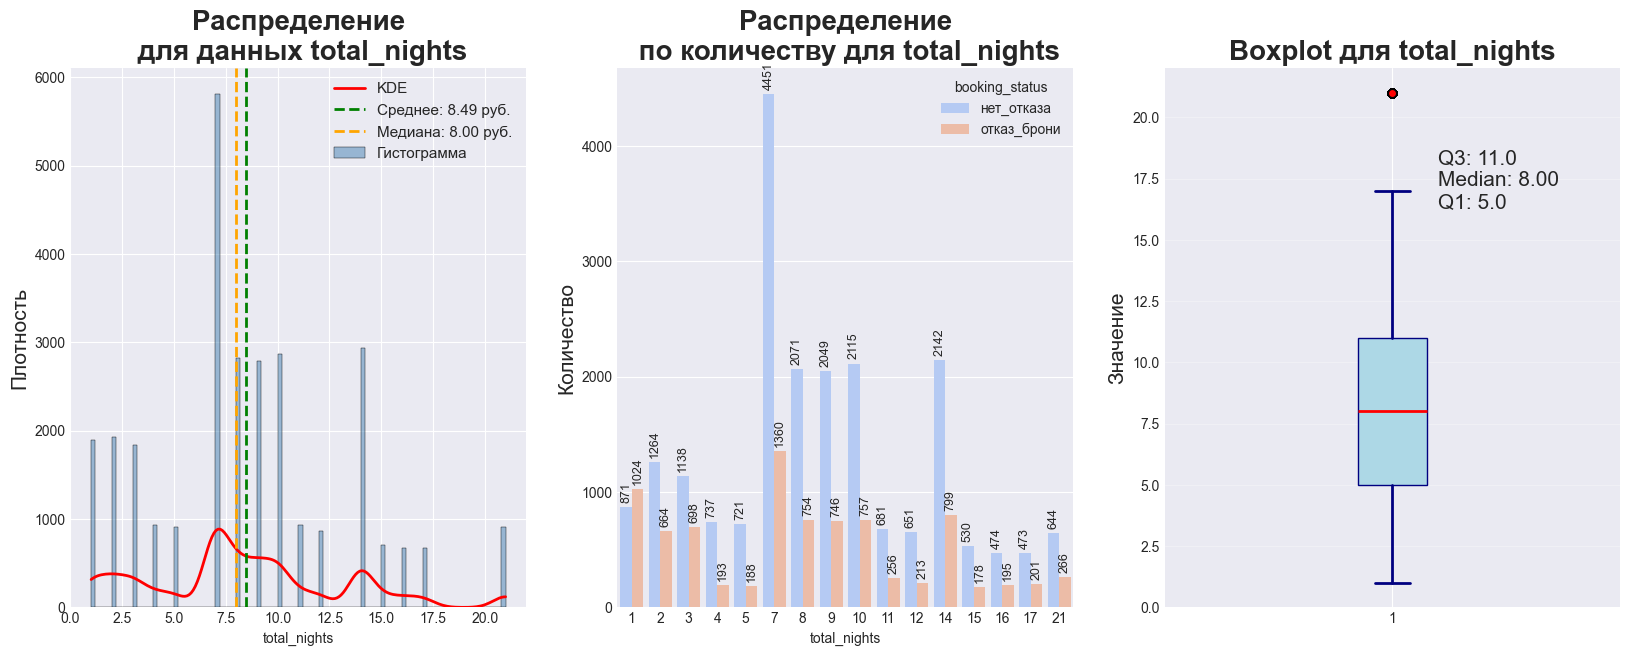

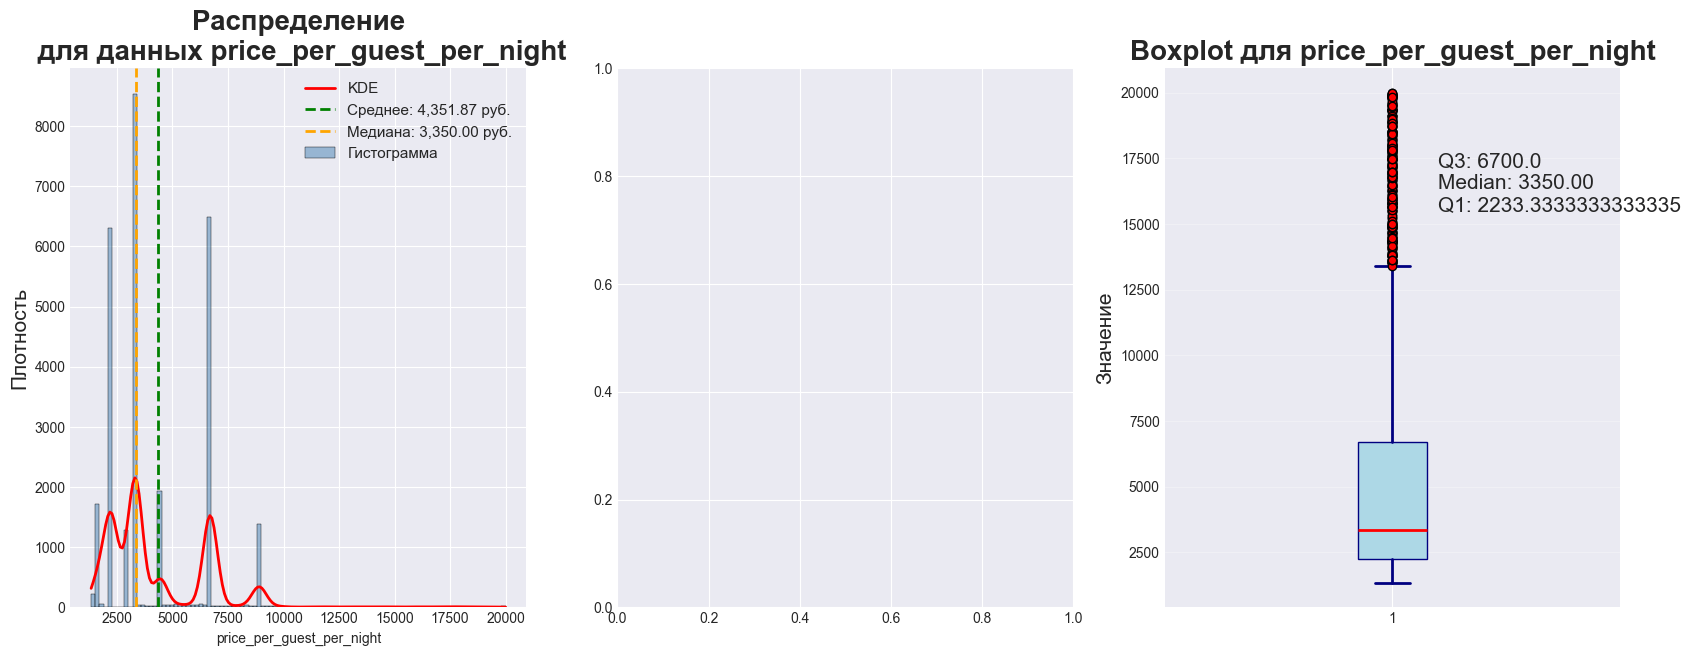

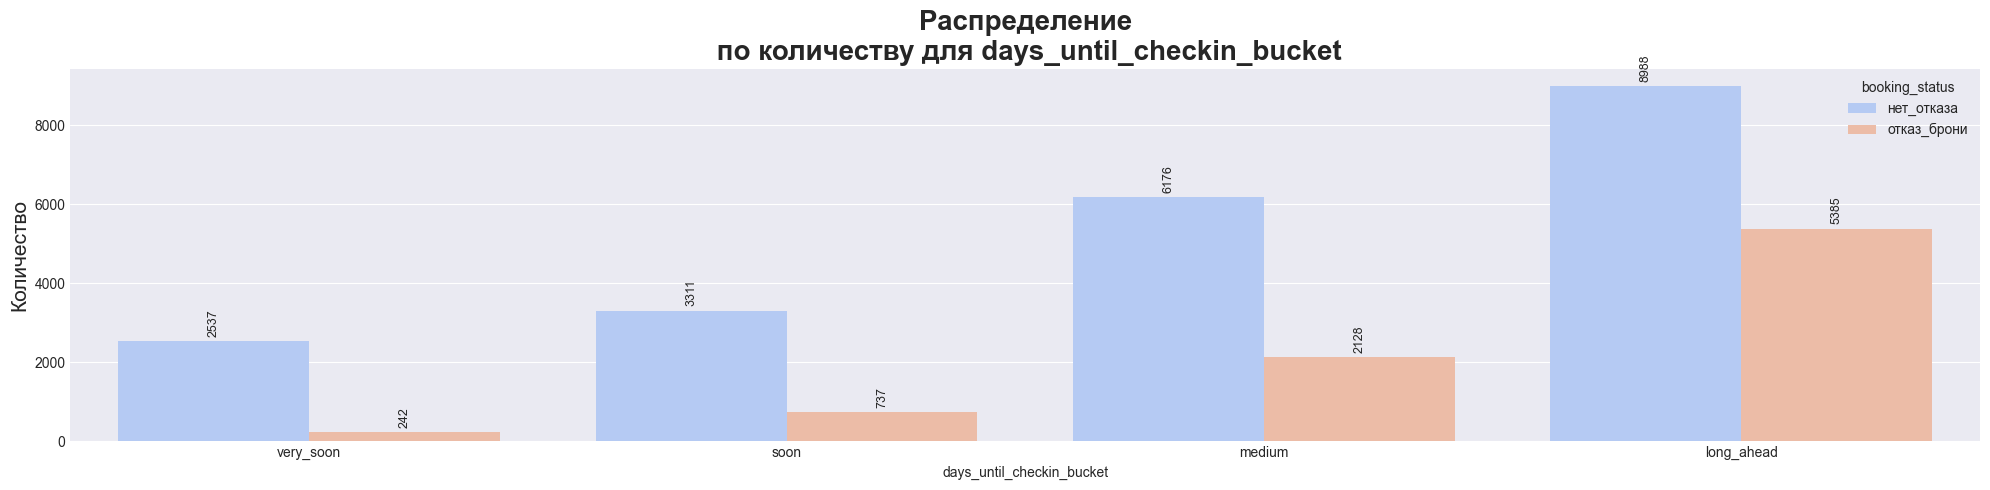

In [40]:
# Список новых признаков
new_columns = [
    'total_nights',
    'price_per_guest_per_night',
]

# Выводим графики для новых числовых признаков
for new_col in new_columns:
    _, axes = plt.subplots(1, 3, figsize=(20, 7))
    print_histplot(df_merge_booking_with_features, new_col, axes[0])
    print_countplot(df_merge_booking_with_features, new_col, axes[1], 'booking_status', 'coolwarm')
    print_boxplot(df_merge_booking_with_features, new_col, axes[2])

# Выводим график для нового категориального признака
_, axes = plt.subplots(1, 1, figsize=(20, 5))
print_countplot(df_merge_booking_with_features, 'days_until_checkin_bucket', axes, 'booking_status', 'coolwarm')

plt.tight_layout()
plt.show()

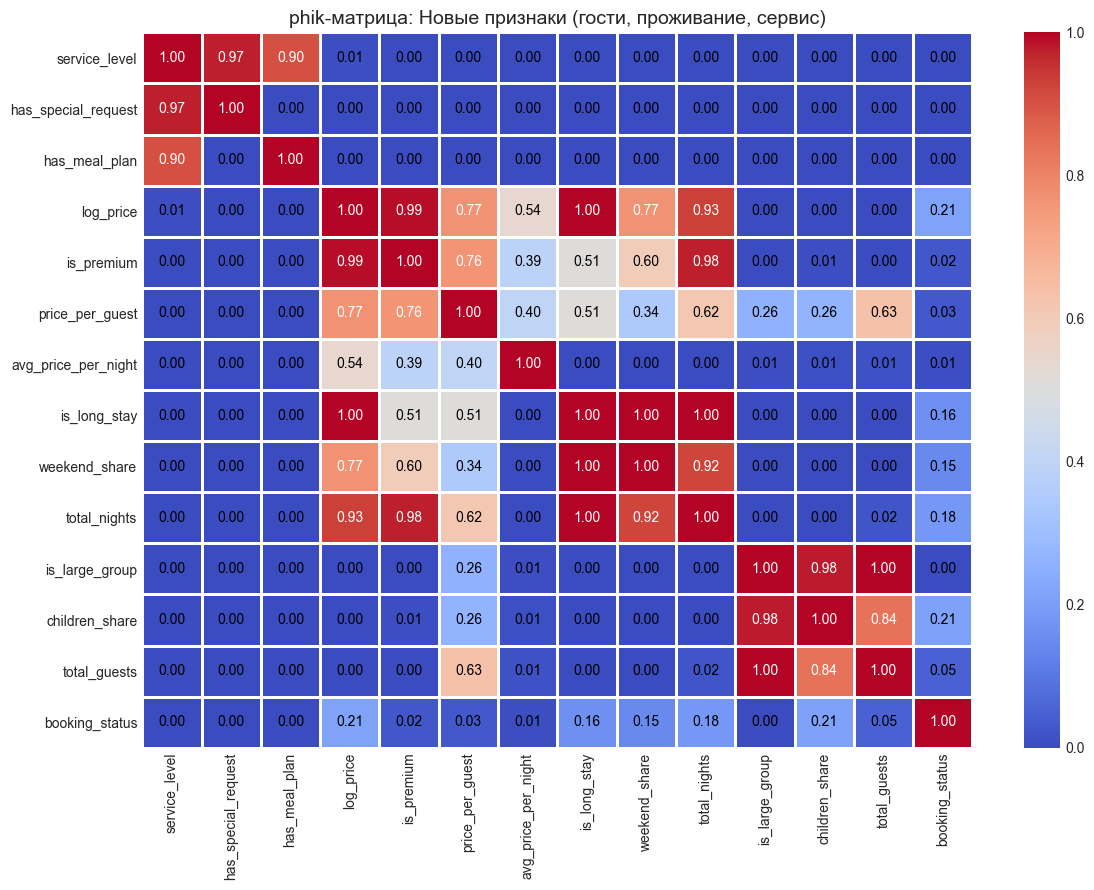

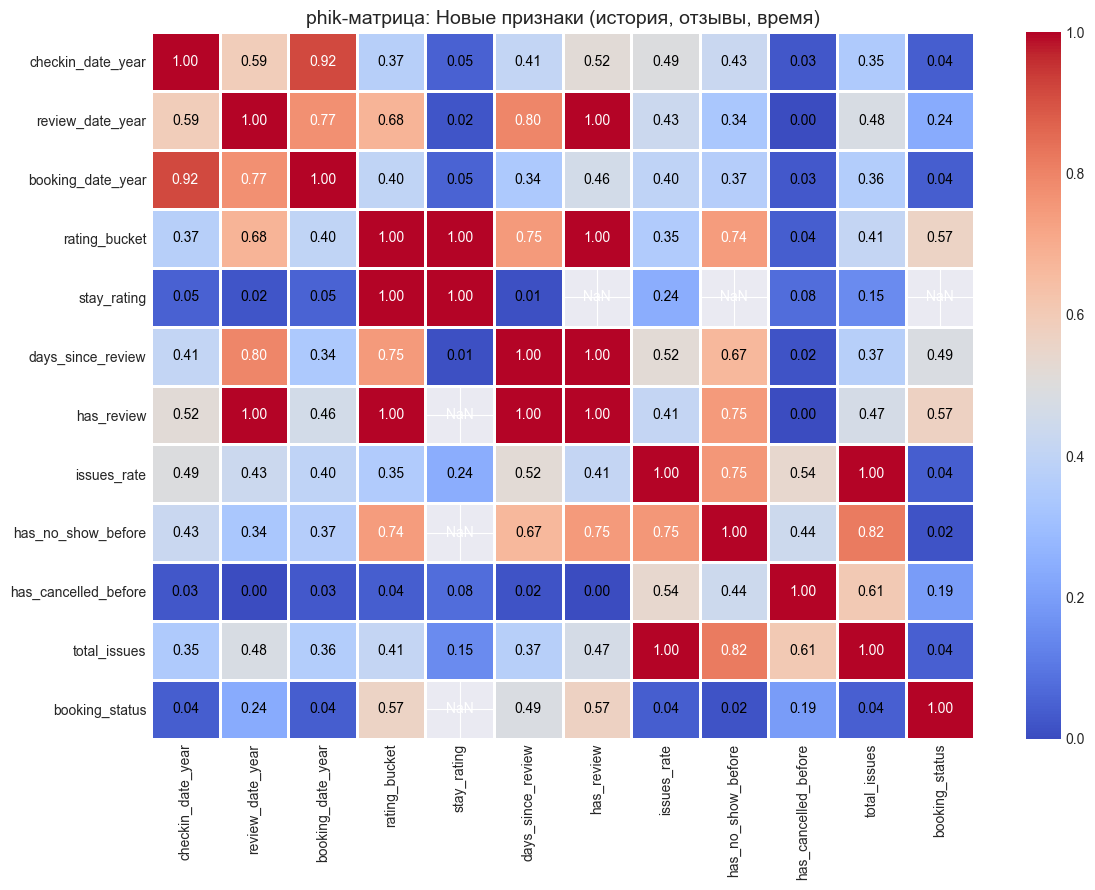

In [41]:
# Исключаем неинформативные колонки: текст, id и разреженные TF-IDF
phik_exclude_cols = (
    ['booking_id', 'customer_id', 'review_text']
    + [col for col in df_merge_booking_with_features.columns if col.startswith('review_tfidf_')]
)
phik_cols = [col for col in df_merge_booking_with_features.columns if col not in phik_exclude_cols]

# Непрерывные признаки — их phik должен бинировать в интервалы (иначе медленно и некорректно)
interval_cols = [
    col for col in phik_cols
    if pd.api.types.is_numeric_dtype(df_merge_booking_with_features[col])
    and df_merge_booking_with_features[col].nunique() > 2
]

phik_groups = {
    'Новые признаки (гости, проживание, сервис)': ['booking_status', 'total_guests', 'children_share',
                               'is_large_group', 'total_nights', 'weekend_share', 'is_long_stay',
                               'avg_price_per_night', 'price_per_guest', 'is_premium', 'log_price',
                               'has_meal_plan', 'has_special_request', 'service_level'],
    'Новые признаки (история, отзывы, время)': ['booking_status', 'total_issues', 'has_cancelled_before',
                               'has_no_show_before', 'issues_rate', 'has_review', 'days_since_review',
                               'stay_rating', 'rating_bucket', 'booking_date_year', 'review_date_year',
                               'checkin_date_year'],
}

for group_name, cols in phik_groups.items():
    grp_interval = [c for c in cols if c in interval_cols]
    grp_matrix = df_merge_booking_with_features[cols].phik_matrix(interval_cols=grp_interval)
    plot_correlation_matrix(
        grp_matrix.values,
        x_labels=grp_matrix.columns,
        y_labels=grp_matrix.index,
        vmin=0, vmax=1,
        title=f'phik-матрица: {group_name}',
        figsize=(12, 9),
        color_map='coolwarm'
    )
    plt.show()


### [1.7 Промежуточный итог <a id=1_7></a>](#content)

**1. Загрузка данных**

Из базы данных PostgreSQL с помощью SQLAlchemy выгружены две таблицы: `hotel_bookings` (35 341 бронь, 17 признаков) и `hotel_reviews` (25 177 отзывов, 5 признаков). Пропусков в исходных данных не обнаружено.

**2. EDA и предобработка**

- Выявлены и удалены дубликаты: 4 608 строк в `hotel_bookings` (по `booking_id`) и 130 в `hotel_reviews` — после очистки осталось 30 733 уникальные брони.
- Проведён анализ распределений числовых, категориальных и датовых признаков, построена корреляционная матрица (phik).
- По методу IQR найдены выбросы в 7 из 9 числовых признаков; аномалия в `adult_count` (значения ≥ 100) исправлена делением на 100 — это ошибка ввода данных.
- Исправлена опечатка в признаке `meal_plan` (`не выбрант` → `не выбран`).

**3. Объединение таблиц**

- К броням добавлен `customer_id` (для 21 012 записей).
- С помощью `pd.merge_asof` к каждой брони подтянут последний по времени предыдущий отзыв того же клиента — 8 021 записей получили `stay_rating`, `review_date` и `review_text`.
- Итоговая объединённая таблица: 29 504 строки, 21 колонка.

**4. Feature Engineering**

Создано 97 новых признаков:
- 32 признака на основе данных брони: состав гостей (`total_guests`, `children_share`, `is_large_group`), длительность проживания (`total_nights`, `weekend_share`, `stay_length_bucket`), стоимость (`avg_price_per_night`, `price_per_guest`, `is_premium`, `log_price`), срок до заезда (`days_until_checkin_bucket`), уровень сервиса (`service_level`, `has_special_request`), история клиента (`total_issues`, `has_cancelled_before`, `issues_rate`), признаки отзывов (`has_review`, `days_since_review`, `rating_bucket`) и взаимодействия признаков;
- 15 временных признаков (год, месяц, день недели и циклические sin/cos для дат брони, отзыва и заезда);
- 50 TF-IDF признаков из текстов отзывов (`TfidfVectorizer`, n-граммы 1–2, стоп-слова удалены).

**5. Анализ корреляций в итоговой таблице**

На финальной таблице с новыми признаками проведён корреляционный анализ методом phik (φ-k), который учитывает нелинейные зависимости и категориальные признаки (дополняет аналогичную матрицу для таблицы бронирований). Матрицы рассчитаны отдельно для групп новых признаков — «гости, проживание, сервис» и «история, отзывы, время». Ключевые наблюдения:

- наибольшая связь с отменой брони сохраняется у срока до заезда (`days_until_checkin`), истории клиента (`previous_no_shows`, `total_issues`) и давности отзыва (`days_since_review`);
- признаки лояльности (`has_review`, `stay_rating`, `rating_bucket`) связаны с отменой обратно — клиенты с положительным опытом прошлых проживаний реже отменяют новые брони;
- заметную связь показывают также канал продаж и год бронирования/отзыва, что согласуется с выводами раздела 1.3 и подтверждает информативность созданных признаков.

**6. Итог этапа**

Финальная таблица `df_merge_booking_with_features`: 29 504 × 114 колонок. Пропуски сосредоточены только в отзывных признаках (у клиента нет предыдущего отзыва), целевая переменная `booking_status` сохранена. Данные подготовлены и готовы к этапу моделирования.

<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'> ~~Нужно провести анализ корреляций в итоговой таблице, как стандартный шаг ИАД~~.</font>

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Добавил анализ корреляций по итоговой таблице. В промежуточный итог добавил упоминание про корреляцию.</span>


<font color='blue'><b>Комментарий ревьюера 2: </b></font> ✔️\
<font color='green'>Здорово,что применена `phik` для анализа и нелинейных зависимостей</font>

## [Этап 2: Моделирование <a id=2></a>](#content)

### [2.1 Обучение базовых моделей <a id=2_1></a>](#content)

In [42]:
# Сортируем данные по времяни бронирования
df_merge_booking_sorted = df_merge_booking.sort_values(['booking_date', 'booking_id']).reset_index(drop=True)

# Выделяем целевой признак
X = df_merge_booking_sorted.drop(columns=['booking_status', 'booking_id', 'customer_id'])
y = df_merge_booking_sorted['booking_status'].map({'нет_отказа': 0, 'отказ_брони': 1})

# Разделяем данные на Обучающую, калибровочную и тестовую выборки
X_train_cal, X_test, y_train_cal, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    shuffle=False
) 

X_train, X_cal, y_train, y_cal = train_test_split(
    X_train_cal, y_train_cal,
    test_size=0.25,
    shuffle=False
)

# Выводим информацию о размерах выборок
# Контроль: выборки не пересекаются во времени, test — самая поздняя
dates = df_merge_booking_sorted['booking_date']
print(f"Train: {X_train.shape}, период {dates.iloc[0].date()} → {dates.iloc[len(X_train)-1].date()}")
print(f"Cal:   {X_cal.shape}, период {dates.iloc[len(X_train)].date()} → {dates.iloc[len(X_train)+len(X_cal)-1].date()}")
print(f"Test:  {X_test.shape}, период {dates.iloc[len(X_train)+len(X_cal)].date()} → {dates.iloc[-1].date()}")

Train: (17702, 18), период 2017-01-01 → 2019-12-01
Cal:   (5901, 18), период 2019-12-01 → 2020-09-20
Test:  (5901, 18), период 2020-09-20 → 2025-10-22


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'> Для разделения данных на выборки, нужно отсортировать данные по времени ('booking_date'), а затем разделить без перемешивания, что бы тестовая выборка была позже всех.</font>

<font color='blue'><b>Комментарий ревьюера : </b></font> ⚠️\
<font color='darkorange'>Для этого можно применять `train_test_split` если данные отсортированы по дате, но отключить перемешивание и стратификацию.</font>

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Я когда уже отправил проект на проверку, понял что у нас же временные ряды и разделение и обучение нужно деласть с учетом этого, что бы не произошло утечки данных. Я скорректировал код по разделению выборок.</span>


<font color='blue'><b>Комментарий ревьюера 2: </b></font> ❌\
<font color='red'> Данные нужно сортировать только по дате.\
`train_test_split` перемешивает данные при разбиении по умолчанию. Необходимо указать параметр `shuffle=False`\
`random_state` без перемешивания не нужен.</font> 

</span><br><span style="color: purple; font-weight: bold">Комментарий студента v2</span>
<span style="color: blue"><br>Тут я оплашал, не проверил в документации какое значение для параметра shuffle по умолчанию применяется.</span>

In [ ]:
# Создаем пустой датафрейм с метриками
metrics_result_df = pd.DataFrame(
    columns=[
        'Accuracy', 
        'Precision', 
        'Recall', 
        'F1-score', 
        'AUC-ROC', 
        'TP', 
        'FP', 
        'FN', 
        'TN', 
        'Incremental Revenue'
    ]
).astype({
    'Accuracy': 'float64',
    'Precision': 'float64',
    'Recall': 'float64',
    'F1-score': 'float64',
    'AUC-ROC': 'float64',
    'TP': 'int64',
    'FP': 'int64',
    'FN': 'int64',
    'TN': 'int64',
    'Incremental Revenue': 'int64'
})

# Создаем пустой словарь для хранения обученых моделей
all_model_dict = {}

# Определяем числовые и категориальные признаки
numeric_cols_booking_merge = X_train.select_dtypes(include=[np.number, 'bool']).columns.to_list()
category_cols_booking_merge = X_train.select_dtypes(include=['object']).columns.to_list()
category_cols_booking_merge.remove('review_text')
dt_cols_booking_merge = X_train.select_dtypes(include='datetime64').columns.to_list()

In [44]:
def calculate_ir(y_true, y_pred):
    '''
    Функция для расчета прироста дохода благодаря модели IR
    '''
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    total_success = (y_true == 0).sum()
    total_cancellations = (y_true == 1).sum()

    ir_before = total_success * AVG_REV - total_cancellations * LOST_REV
    ir_after = tp * PER_REBOOKING + tn * AVG_REV - fp * COST_FP - fn * LOST_REV

    return ir_after - ir_before

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'>Расчёт incremental revenue (IR) верный.</font>

<span style="color: blue;: bold">Комментарий ревьюера : </span> ⚠️\
<font color='darkorange'>К `confusion_matrix(y_true, y_pred).ravel()` стоит добавить явную фиксацию сетки классов: `labels=[0, 1]`. Это застрахует код от ошибки ValueError, если на каком-то из фолдов модель временно предскажет только один класс.</font>

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Упустил этот параметр. Исправил код.</span>

<font color='blue'><b>Комментарий ревьюера 2: </b></font> ✔️\
<font color='green'> 👍</font>

In [45]:
# Функция для расчета метрик
def metrics_calc(y_true, y_pred, y_proba):
    '''
    Функция для рассчета метрик
    '''
    # Матрица ошибок
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred),
        'AUC-ROC': roc_auc_score(y_true, y_proba),
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn,
        'Incremental Revenue': calculate_ir(y_true, y_pred)
    }

    return metrics

In [46]:
# Функция для добавления метрик в список
def add_metrics(metrics_result_df, model_name, y_true, y_pred, y_proba):
    '''
    Функция для добавления метрик их в общий датафрейм для сравнения
    '''

    metrics = metrics_calc(y_true, y_pred, y_proba)
    metrics['Модель'] = model_name

    # Добавляем новую строку в metrics_result_df
    metrics_result_df.loc[model_name] = metrics
    metrics_result_df.sort_values(by='AUC-ROC', ascending=True, inplace=True)

In [47]:
# Создание числового пайплайна
numeric_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

# Создание категориального пайплайна
category_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('one', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Создаем пайплайны для моделей
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, make_column_selector(dtype_include=['int64', 'float64'])),
        ('cat', category_pipe, make_column_selector(dtype_include=['object', 'category', 'string']))
    ],
    remainder='passthrough'
)

# Создание базового пайплайна
def create_pipeline(model):
    return Pipeline([
        ('add_features', FunctionTransformer(add_booking_features, validate=False)),
        ('extract_time', FunctionTransformer(extract_time_features, validate=False)),
        ('extraction_text', FunctionTransformer(feature_extraction_text, validate=False)),
        ('preprocessor', preprocessor),
        ('model', model)
    ])

<span style="color: blue;: bold">Комментарий ревьюера : </span> ⚠️\
<font color='darkorange'> Оба бустера, применяемые ниже имеют внутренние алгоритмы кодировки признаков.\
Вот что есть в документации :</font>
![](https://pictures.s3.yandex.net/resources/Snimok_ekrana_2026-02-27_133836_1773595080.png)
![](https://pictures.s3.yandex.net/resources/Snimok_ekrana_2026-03-20_121315_1773998077.png)

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Я про это помнил, но решил предворительно обработать категориальные признаки для того что бы обе модели получили одинаковую матрицу признаков и обучались на абсолютно индетичных данных для сравнения.</span>


<font color='blue'><b>Комментарий ревьюера 2: </b></font> ⚠️\
<font color='darkorange'> Специфичная предобработка под каждую модель позволяет выжать из моделей максимум.\
Сравниваем мы Пайплайны целиком, а не классификаторы.</font>

In [48]:
def fit_predict_cv(model, name_model, X_train, y_train, metrics_result_df, all_model_dict=None):
    """
    Обучает модель через кросс-валидацию, считает средние метрики по фолдам
    и записывает одну строку в metrics_result_df.
    Модель обученную на всём train, сохраняет в all_model_dict.
    """
    tss = TimeSeriesSplit(n_splits=3, test_size=2000)

    fold_metrics = []

    for train_idx, val_idx in tss.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = clone(model)
        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]

        fold_metrics.append(metrics_calc(y_val, y_pred, y_proba))

    # Усредняем метрики по фолдам
    avg_series = pd.DataFrame(fold_metrics).mean(numeric_only=True)

    # Преобразуем только нужные колонки в int (счётчики и потери)
    int_cols = ['TP', 'FP', 'FN', 'TN', 'Incremental Revenue']
    for col in int_cols:
        if col in avg_series.index:
            avg_series[col] = int(round(avg_series[col]))

    avg_metrics = avg_series.to_dict()
    avg_metrics['Модель'] = name_model

    # Добавляем новую строку в metrics_result_df
    metrics_result_df.loc[name_model] = avg_metrics
    all_model_dict[name_model] = model
    metrics_result_df.sort_values(by='AUC-ROC', ascending=True, inplace=True)


<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'> ~~Здесь нужен специальный Сплитер для кросс-валидации - [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) с test_size=2000 .~~</font>

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Исправил: кросс-валидацию перевел на TimeSeriesSplit</span>


<font color='blue'><b>Комментарий ревьюера 2: </b></font> ✔️\
<font color='green'>Верно, что применяешь TimeSeriesSplit для кросс-валидации временных рядов.</font>

In [49]:
# Определячем базовую модель LGBMClassifier
lightgbm_base = create_pipeline(
    LGBMClassifier(
        random_state=RANDOM_STATE
    )
)

# Определячем базовую модель CatBoostClassifier
catboost_base = create_pipeline(
    CatBoostClassifier(
        random_state=RANDOM_STATE
    )
)

# Обучаем базовые модели
for model, name in [(catboost_base, 'CatBoostClassifier_Base'), (lightgbm_base, 'LGBMClassifier_Base')]:
    fit_predict_cv(
        model,
        name,
        X_train,
        y_train,
        metrics_result_df,
        all_model_dict
    )

# Выводим полученные метрики
display(metrics_result_df)

Learning rate set to 0.02945
0:	learn: 0.6743181	total: 248ms	remaining: 4m 8s
1:	learn: 0.6561045	total: 303ms	remaining: 2m 31s
2:	learn: 0.6412496	total: 342ms	remaining: 1m 53s
3:	learn: 0.6277238	total: 392ms	remaining: 1m 37s
4:	learn: 0.6134973	total: 533ms	remaining: 1m 46s
5:	learn: 0.6002277	total: 583ms	remaining: 1m 36s
6:	learn: 0.5910182	total: 637ms	remaining: 1m 30s
7:	learn: 0.5801849	total: 685ms	remaining: 1m 24s
8:	learn: 0.5703654	total: 731ms	remaining: 1m 20s
9:	learn: 0.5609928	total: 783ms	remaining: 1m 17s
10:	learn: 0.5546286	total: 832ms	remaining: 1m 14s
11:	learn: 0.5475594	total: 888ms	remaining: 1m 13s
12:	learn: 0.5418597	total: 937ms	remaining: 1m 11s
13:	learn: 0.5365256	total: 986ms	remaining: 1m 9s
14:	learn: 0.5296546	total: 1.04s	remaining: 1m 8s
15:	learn: 0.5228538	total: 1.09s	remaining: 1m 7s
16:	learn: 0.5178101	total: 1.14s	remaining: 1m 6s
17:	learn: 0.5134898	total: 1.19s	remaining: 1m 5s
18:	learn: 0.5102751	total: 1.24s	remaining: 1m 4s


,Accuracy,Precision,Recall,F1-score,AUC-ROC,TP,FP,FN,TN,Incremental Revenue
CatBoostClassifier_Base,0.815,0.732,0.587,0.651,0.881,346.000,127.000,243.000,1 284.000,28 793 833.000
LGBMClassifier_Base,0.817,0.736,0.590,0.655,0.882,348.000,125.000,241.000,1 286.000,29 155 833.000


In [50]:
# Создаем словарь гиперпораметров моделей
MODEL_CONFIGS = {
    'LGBMClassifier': {
        'class': lightgbm_base,
        'suggest': lambda t: {
            'n_estimators': t.suggest_int('n_estimators', 100, 1000),
            'learning_rate': t.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'num_leaves': t.suggest_int('num_leaves', 20, 200),
            'max_depth': t.suggest_int('max_depth', 3, 10),
            'verbose': -1,
        },
        'fit_kwargs': {
            'callbacks': [lgb.early_stopping(stopping_rounds=EARLY_STOPPING_ROUNDS)], 
            #'n_jobs': -1
        }
    },
    'CatBoostClassifier': {
        'class': catboost_base,
        'suggest': lambda t: {
            'iterations': t.suggest_int('iterations', 100, 1000),
            'learning_rate': t.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'depth': t.suggest_int('depth', 3, 10),
            'l2_leaf_reg': t.suggest_float('l2_leaf_reg', 1, 15, log=True),
            'verbose': 0,
        },
        'fit_kwargs': {
            'early_stopping_rounds': EARLY_STOPPING_ROUNDS,
            #'n_jobs': -1
        }
    },
}

In [51]:
# Определяем функцию оптимизации
def objective(trial, model_name, X, y):
    """
    Целевая функция для Optuna: возвращает среднюю Incremental Revenue по кросс‑валидации.
    """

    cfg = MODEL_CONFIGS[model_name]
    params = cfg['suggest'](trial)
    kwargs = cfg['fit_kwargs']

    tss = TimeSeriesSplit(n_splits=3, test_size=2000)
    ir_scores = []

    for train_idx, val_idx in tss.split(X, y):
        X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

        pipe =clone(cfg['class'])
        pipe.set_params(
            **{f'model__{k}': v for k, v in params.items()},
            **{f'model__{k}': v for k, v in kwargs.items()}
        )

        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_va)
        ir_scores.append(calculate_ir(y_va, y_pred))

    return np.mean(ir_scores)

<font color='blue'><b>Комментарий ревьюера: </b></font> ❌\
<font color='red'>~~Здесь тоже нужен специальный Сплитер для кросс-валидации - [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html).~~</font>

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Исправил функцию оптимизации.</span>


<font color='blue'><b>Комментарий ревьюера 2: </b></font> ✔️\
<font color='green'> 👍</font>

In [52]:
# Запускем оптимизацию моделей
for name in MODEL_CONFIGS:
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        study_name=f'{name}_tuning',
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10)
    )
    study.optimize(
        lambda trial, n=name: objective(trial, n, X_train, y_train),
        n_trials=10,
        n_jobs=-1,
        show_progress_bar=False
    )

    MODEL_CONFIGS[name]['best_params'] = study.best_params
    MODEL_CONFIGS[name]['best_score'] = study.best_value

In [53]:
# Обучение оптимизированных моделей
for name in MODEL_CONFIGS:
    pipe =clone(MODEL_CONFIGS[name]['class'])
    pipe.set_params(
        **{f'model__{k}': v for k, v in MODEL_CONFIGS[name]['best_params'].items()}
    )

    fit_predict_cv(
        pipe,
        f'{name}_tuning',
        X_train,
        y_train,
        metrics_result_df,
        all_model_dict
    )

display(metrics_result_df)

[LightGBM] [Info] Number of positive: 3472, number of negative: 8230
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014980 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3689
[LightGBM] [Info] Number of data points in the train set: 11702, number of used features: 128
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.296701 -> initscore=-0.863055
[LightGBM] [Info] Start training from score -0.863055
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

,Accuracy,Precision,Recall,F1-score,AUC-ROC,TP,FP,FN,TN,Incremental Revenue
CatBoostClassifier_Base,0.815,0.732,0.587,0.651,0.881,346.000,127.000,243.000,1 284.000,28 793 833.000
LGBMClassifier_Base,0.817,0.736,0.590,0.655,0.882,348.000,125.000,241.000,1 286.000,29 155 833.000
CatBoostClassifier_tuning,0.816,0.737,0.586,0.652,0.883,345.000,124.000,244.000,1 287.000,28 935 333.000
LGBMClassifier_tuning,0.818,0.743,0.584,0.654,0.883,344.000,119.000,245.000,1 292.000,29 159 500.000


**Промежуточный итог**

**1. Подготовка данных и разделение**

Данные отсортированы по времени и разделены без перемешивания: обучающая выборка — 17 702 записи (60%), калибровочная — 5 901 (20%), тестовая — 5 901 (20%). Тестовая выборка состоит из самых поздних по времени броней (период 2020-09-20 → 2025-10-22), что соответствует сценарию внедрения. В исходном виде используется 18 признаков, после пайплайна — 128.

**2. Кросс-валидация и оптимизация**

Для оценки моделей применена временная кросс-валидация `TimeSeriesSplit` (3 фолда, размер валидации 2000 записей) — обучающее окно расширяется во времени, каждая модель валидируется только на «будущих» относительно обучения данных.

Гиперпараметры оптимизированы в Optuna (TPESampler, 10 испытаний на модель, MedianPruner): целевая метрика — средний Incremental Revenue по фолдам.

**3. Результаты сравнения моделей (временная CV)**

| Модель | Accuracy | Precision | Recall | F1 | AUC-ROC | IR, руб. |
|---|---|---|---|---|---|---|
| CatBoostClassifier_Base | 0.815 | 0.732 | 0.587 | 0.651 | 0.881 | 28 793 833 |
| LGBMClassifier_Base | 0.817 | 0.736 | 0.590 | 0.655 | 0.882 | 29 155 833 |
| CatBoostClassifier_tuning | 0.816 | 0.737 | 0.586 | 0.652 | 0.883 | 28 935 333 |
| **LGBMClassifier_tuning** | **0.818** | **0.743** | 0.584 | 0.654 | **0.883** | **29 159 500** |

**4. Вывод**

Лучшей моделью по ключевой бизнес-метрике `IR` стал `LGBMClassifier_tuning` (29 159 500 руб.) — он же показывает лучшие Accuracy (0.818) и Precision (0.743) при максимальном AUC-ROC (0.883). Оптимизация гиперпараметров дала небольшой прирост `IR` у обеих моделей (CatBoost: +141 500 руб., LGBM: +3 667 руб.).

<font color='blue'><b>Комментарий ревьюера : </b></font> ❌\
<font color='red'> ~~Вывод~~ </font> 

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Добавил промежуточный итог</span>


<font color='blue'><b>Комментарий ревьюера 2: </b></font> ✔️\
<font color='green'> 👍</font>

### [2.2 Калибровка модели и пересчёт результатов <a id=2_2></a>](#content)

In [54]:
# Фиксируем модель-победитель
best_model_name = metrics_result_df['Incremental Revenue'].idxmax()
best_model = all_model_dict[best_model_name]

# Обучаем неоткалиброванную модель на полной тренировочной выборке.
best_model.fit(X_train, y_train)

print(f'Лучшая модель: {best_model_name}')
print(f'Прирост дохода (IR): {metrics_result_df.loc[best_model_name, "Incremental Revenue"]:,.0f} руб.')

[LightGBM] [Info] Number of positive: 5239, number of negative: 12463
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019725 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4747
[LightGBM] [Info] Number of data points in the train set: 17702, number of used features: 128
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.295955 -> initscore=-0.866634
[LightGBM] [Info] Start training from score -0.866634
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

<Figure size 600x600 with 0 Axes>

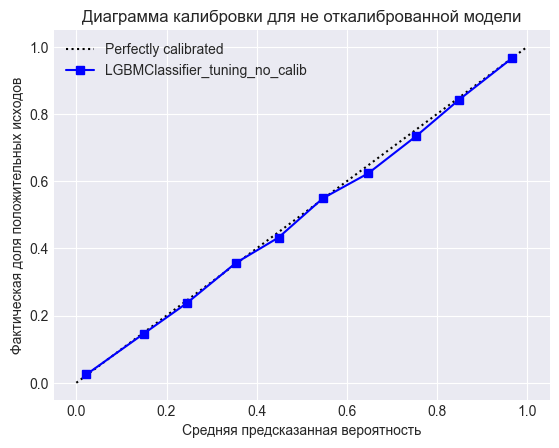

In [55]:
# Получаем вероятности
y_pred_no_calib = best_model.predict_proba(X_cal)[:, 1] 

# Рассчитываем калибровочную кривую
prob_true, prob_pred = calibration_curve(y_cal, y_pred_no_calib, n_bins=10) 

# Строим диаграмму
plt.figure(figsize=(6,6))
CalibrationDisplay(prob_true, prob_pred, y_cal).plot(label=f'{best_model_name}_no_calib', color='blue')

plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Фактическая доля положительных исходов")
plt.title("Диаграмма калибровки для не откалиброванной модели")
plt.legend()
plt.grid(True)
plt.show()

In [56]:
# Определяем функцию для расчёта метрик качества калибровки
def calibration_metrics(y_true, y_proba, n_bins=10):
    """
    Считает качество калибровки вероятностей:
    Brier score и Log loss (чем меньше, тем лучше),
    а также средний разрыв reliability-кривой с идеальной диагональю.
    """
    frac_pos, mean_pred = calibration_curve(y_true, y_proba, n_bins=n_bins, strategy='uniform')

    return {
        'Brier score': brier_score_loss(y_true, y_proba),
        'Log loss': log_loss(y_true, y_proba),
        'Средний разрыв кривой': np.abs(frac_pos - mean_pred).mean(),
    }

In [57]:
calibration_methods = ['sigmoid', 'isotonic']

# Получаем вероятности на калибровочной выборке для всех версий модели
proba_cal_dict = {
    f'{best_model_name}_no_calib': y_pred_no_calib
}

for method in calibration_methods:
    name_model = f'{best_model_name}_{method}'

    calibrated_best_model = CalibratedClassifierCV(
        estimator=clone(best_model),
        method=method,
        cv=TimeSeriesSplit(n_splits=3, test_size=2000),
        n_jobs=-1,  
    )
    calibrated_best_model.fit(X_train, y_train)

    proba_cal_dict[name_model] = calibrated_best_model.predict_proba(X_cal)[:, 1]
    all_model_dict[name_model] = calibrated_best_model

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'> ~~Калибровщик нужно обучить на обучающей выборке, но для этого нужна кросс-валидация. с tscv.\
`X_calib` для оценки калибровки.~~</font>
>  Калибровка лучшей модели. Выбрав модель, откалибруйте её на полной тренировочной выборке, чтобы повысить обобщающую способность и адаптировать предсказания под бизнес-задачи.

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Тут я что-то сильно напутал, что не заметил что модель проверяю на данных на которых она калибровалась. Скорректировал код.</span>


<font color='blue'><b>Комментарий ревьюера 2: </b></font> ✔️\
<font color='green'> 👍</font>

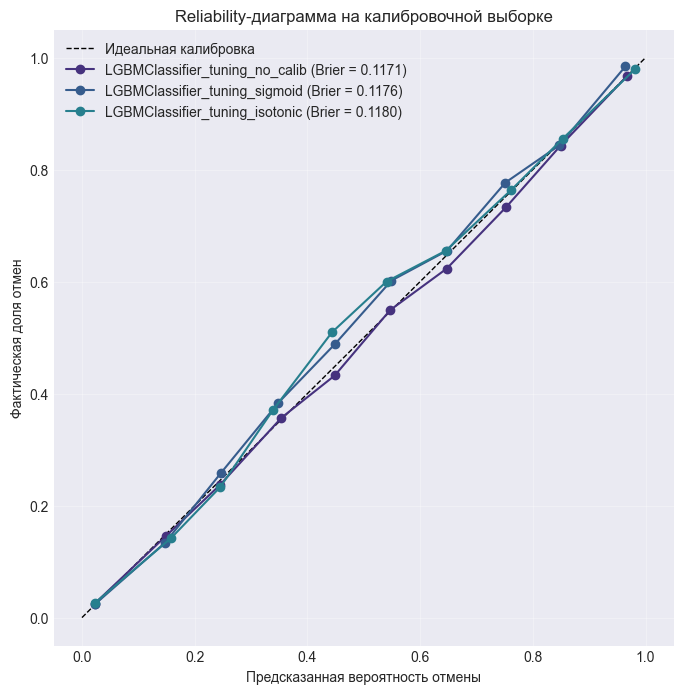

In [58]:
# Строим калибровочную диаграмму: точки должны лежать на пунктирной диагонали
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Идеальная калибровка')

for name_model, proba in proba_cal_dict.items():
    frac_pos, mean_pred = calibration_curve(y_cal, proba, n_bins=10, strategy='uniform')
    ax.plot(
        mean_pred,
        frac_pos,
        marker='o',
        label=f'{name_model} (Brier = {brier_score_loss(y_cal, proba):.4f})'
    )

ax.set_xlabel('Предсказанная вероятность отмены')
ax.set_ylabel('Фактическая доля отмен')
ax.set_title('Reliability-диаграмма на калибровочной выборке')
ax.grid(alpha=0.3)
ax.legend()
plt.show()

In [59]:
# Пересчитываем классические метрики
for name_model, proba in proba_cal_dict.items():
    y_pred = (proba >= 0.5).astype(int)

    metrics_model = metrics_calc(y_cal, y_pred, proba)
    metrics_model['Модель'] = name_model

    metrics_result_df.loc[name_model] = metrics_model
    metrics_result_df.sort_values(by='AUC-ROC', ascending=True, inplace=True)

display(metrics_result_df)

,Accuracy,Precision,Recall,F1-score,AUC-ROC,TP,FP,FN,TN,Incremental Revenue
CatBoostClassifier_Base,0.815,0.732,0.587,0.651,0.881,346.000,127.000,243.000,1 284.000,28 793 833.000
LGBMClassifier_Base,0.817,0.736,0.590,0.655,0.882,348.000,125.000,241.000,1 286.000,29 155 833.000
CatBoostClassifier_tuning,0.816,0.737,0.586,0.652,0.883,345.000,124.000,244.000,1 287.000,28 935 333.000
LGBMClassifier_tuning,0.818,0.743,0.584,0.654,0.883,344.000,119.000,245.000,1 292.000,29 159 500.000
LGBMClassifier_tuning_isotonic,0.823,0.776,0.564,0.653,0.896,982.000,284.000,760.000,3 875.000,87 223 000.000
LGBMClassifier_tuning_sigmoid,0.824,0.771,0.576,0.660,0.896,1 004.000,298.000,738.000,3 861.000,88 631 000.000
LGBMClassifier_tuning_no_calib,0.826,0.734,0.644,0.686,0.896,1 122.000,407.000,620.000,3 752.000,93 758 500.000


**Промежуточный итог**

Лучшая по `IR` модель `LGBMClassifier_tuning` дообучена на полной обучающей выборке. Вероятности откалиброваны двумя методами — `sigmoid` и `isotonic` — через `CalibratedClassifierCV` с временной кросс-валидацией `TimeSeriesSplit` (3 фолда, test_size=2000). Качество калибровки оценено независимо на калибровочной выборке `X_cal` (reliability-диаграмма, Brier score, Log loss, классические метрики при пороге 0.5).

| Модель | Accuracy | Precision | Recall | F1 | AUC-ROC | IR, руб. |
|---|---|---|---|---|---|---|
| `LGBMClassifier_tuning_no_calib` | 0.826 | 0.734 | 0.644 | 0.686 | 0.896 | 93 758 500 |
| `LGBMClassifier_tuning_sigmoid` | 0.824 | 0.771 | 0.576 | 0.660 | 0.896 | 88 631 000 |
| `LGBMClassifier_tuning_isotonic` | 0.823 | 0.776 | 0.564 | 0.653 | 0.896 | 87 223 000 |

При пороге 0.5 калибровка снижает `IR` относительно неоткалиброванной модели (93 758 500 → 88 631 000 / 87 223 000 руб.), поскольку смещает вероятности к фактическим частотам отмен; по условию проекта модель должна быть откалибрована, поэтому рабочей выбрана калиброванная версия. Среди калиброванных вариантов максимальный `IR` обеспечивает сигмоидная калибровка — `LGBMClassifier_tuning_sigmoid` (88 631 000 руб.) — при наибольшем среди калиброванных Recall (0.576); она и зафиксирована как рабочая.

AUC-ROC у всех трёх вариантов одинаков (0.896) — калибровка не ухудшила ранжирующую способность модели.

Для дальнейшей работы зафиксирована калиброванная модель `LGBMClassifier_tuning_sigmoid`. Следующий шаг — подбор оптимального порога классификации по максимуму `Incremental Revenue`.


<font color='blue'><b>Комментарий ревьюера : </b></font> ❌\
<font color='red'> ~~Вывод~~ </font> 

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Добавил вывод.</span>


<font color='blue'><b>Комментарий ревьюера 2: </b></font> ✔️\
<font color='green'> 👍</font>

### [2.3 Поиск порога классификации <a id=2_3></a>](#content)

In [60]:
# Выбираем лучшую калиброванную модель
calibrated_candidates = [f'{best_model_name}_{method}' for method in calibration_methods]
calibrated_metrics = pd.DataFrame({
    'Модель': calibrated_candidates,
    'Incremental Revenue': [metrics_result_df.loc[name, 'Incremental Revenue'] for name in calibrated_candidates],
    'AUC-ROC': [metrics_result_df.loc[name, 'AUC-ROC'] for name in calibrated_candidates],
    'Brier score': [brier_score_loss(y_cal, proba_cal_dict[name]) for name in calibrated_candidates],
})

calibrated_metrics = calibrated_metrics.sort_values(
    ['Incremental Revenue', 'Brier score', 'AUC-ROC'],
    ascending=[False, True, False]
)

best_calibrated_model_name = calibrated_metrics.iloc[0]['Модель']
best_calibrated_model = all_model_dict[best_calibrated_model_name]
best_calibrated_proba = proba_cal_dict[best_calibrated_model_name]

print('Лучшая калиброванная модель после калибровки:')
display(calibrated_metrics[calibrated_metrics['Модель'] == best_calibrated_model_name])

Лучшая калиброванная модель после калибровки:


,Модель,Incremental Revenue,AUC-ROC,Brier score
0,LGBMClassifier_tuning_sigmoid,88 631 000.000,0.896,0.118


In [61]:
# Поиск оптимального порога классификации на калибровочной выборке
thresholds = np.linspace(0.05, 0.99, num=100)
threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (best_calibrated_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_cal, y_pred_threshold, labels=[0, 1]).ravel()

    threshold_results.append({
        'threshold': threshold,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'TN': tn,
        'Accuracy': accuracy_score(y_cal, y_pred_threshold),
        'Precision': precision_score(y_cal, y_pred_threshold, zero_division=0),
        'Recall': recall_score(y_cal, y_pred_threshold, zero_division=0),
        'F1-score': f1_score(y_cal, y_pred_threshold, zero_division=0),
        'IR': calculate_ir(y_cal, y_pred_threshold),
        'flagged_share': y_pred_threshold.mean()
    })

threshold_df = pd.DataFrame(threshold_results)

<font color='blue'><b>Комментарий ревьюера : </b></font> ❌\
<font color='red'><s>
При таком подходе последний порог равен ровно `1.0`. При `threshold = 1.0` условие `best_calibrated_proba >= 1.0` выдает **все нули** (`y_pred_threshold = [0, 0, ...]`), если в предсказаниях нет ровно единиц.

1. **`ZeroDivisionError` и `Precision = 0`:**
    
    Когда модель предсказывает только нули ($TP = 0, FP = 0$), `precision_score(y_cal, y_pred_threshold)` и `f1_score` возвращают `0.0` (или `np.nan` с предупреждением от sklearn).
    
2. **Искажение `calculate_ir` (Incremental Revenue):**
    
    Если при `threshold = 1.0` модель никого не привлекает/не отправляет в коммуникацию, ее затраты равны 0. Если бизнес-логика `calculate_ir` при $TP=0$ и $FP=0$ возвращает `0` (или некорректное значение из-за деления на 0), этот «пустой» порог может ломать сортировку.
    
3. **Фильтр `flagged_share <= 0.1`:**
    
    При пороге 0.885 доля положительных предсказаний (`flagged_share`) становится очень маленькой (например, 1-2%). Это легко проходит фильтр `<= 0.1`. Функция `calculate_ir` считает доход относительно объемов затрат, при микроскопическом охвате показатель **IR** на одного клиента может выглядеть аномально высоким из-за отсутствия FP-ошибок.</s>
</font>

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Убрал порог 1.0 из сетки (`np.linspace(0.05, 0.99, num=100)`), я поставил 1 по привычке, что последнее значение в диапазоне не включается. Добавил `zero_division=0` в метрики и ограничил долю помеченных броней диапазоном 5–10%. Итоговые метрики и выводы пересчитал.</span>


<font color='blue'><b>Комментарий ревьюера : </b></font> ❌\
<font color='red'>Обрати внимание, IR калиброванной модели с порогом 0.5 — `86 993 500`\
С подобранным порогом почти в два раза меньше — `54 122 500`\
Зачем нам этот фильтр:
```python
threshold_df[
    (threshold_df['flagged_share'] >= 0.05) &
    (threshold_df['flagged_share'] <= 0.1)
]
```
?\
Порог нужно подобрать только по IR</font>
> Шаг 3: оптимальный порог. Используя откалиброванную модель и калибровочную выборку, найдите порог классификации, при котором достигается максимальный Incremental Revenue.

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Что-то я совсем плохо понимаю бизнес метрики((((. Я убрал фильтр, и произошло чудо, у меня впервые значения метрик показали требуемые значения. Так же решил добавить визуализацию зависимости IR от порого и скорректировал все следующие ввыводы с учетом новых выходных данных.</span>


Оптимальный порог классификации на калибровочной выборке: 0.344
Максимальный Incremental Revenue при этом пороге: 96,894,500 руб.


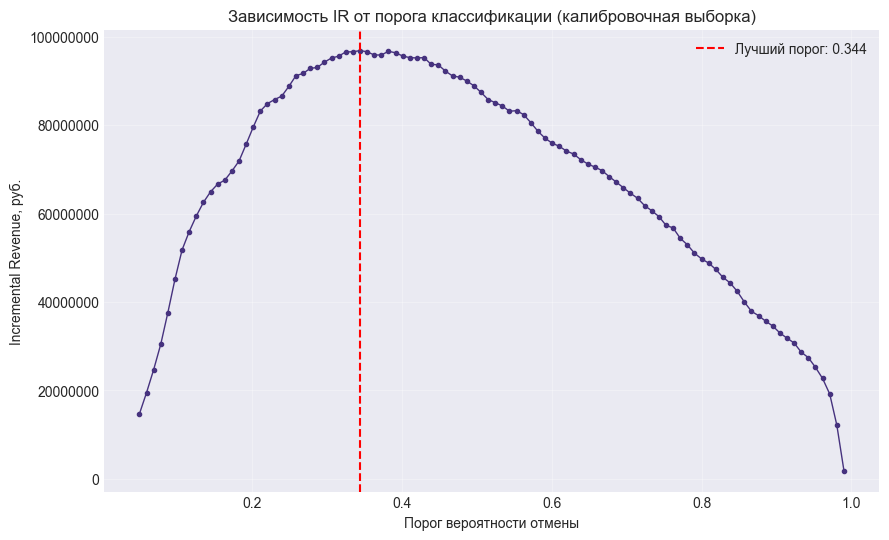

In [73]:
# Сортируем по Incremental Revenue для выбора порога
threshold_df = threshold_df.sort_values('threshold').reset_index(drop=True)

best_idx = threshold_df['IR'].idxmax()   
best_threshold = threshold_df.loc[best_idx, 'threshold']
best_threshold_IR = threshold_df.loc[best_idx, 'IR']


print(f'Оптимальный порог классификации на калибровочной выборке: {best_threshold:.3f}')
print(f'Максимальный Incremental Revenue при этом пороге: {best_threshold_IR:,.0f} руб.')

plt.figure(figsize=(10, 6))
plt.plot(threshold_df['threshold'], threshold_df['IR'], marker='o', lw=1, ms=3)
plt.axvline(best_threshold, color='red', ls='--', label=f'Лучший порог: {best_threshold:.3f}')
plt.xlabel('Порог вероятности отмены')
plt.ylabel('Incremental Revenue, руб.')
plt.title('Зависимость IR от порога классификации (калибровочная выборка)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Сохраняем значения для дальнейшего использования
best_calibrated_threshold = best_threshold
best_calibrated_threshold_ir = best_threshold_IR
best_calibrated_predictions = (best_calibrated_proba >= best_calibrated_threshold).astype(int)

**Промежуточный итог**

1. **Выбор рабочей модели.** После калибровки зафиксирована модель `LGBMClassifier_tuning_sigmoid` как лучшая среди калиброванных по ключевой бизнес-метрике `IR`: сигмоидная калибровка обеспечила максимальный прирост дохода (88 631 000 руб. при пороге 0.5).

2. **Методика подбора порога.** Оптимальный порог классификации перебирался на калибровочной выборке по сетке значений вероятности отмены (`np.linspace(0.05, 0.99, num=100)`). Кандидаты оценивались строго по `Incremental Revenue` — порог выбран там, где эта метрика максимальна, без дополнительных ограничений (стоимость ложных срабатываний уже учтена в формуле IR).

3. **Результат.** Оптимальный порог классификации на калибровочной выборке — **0.344**, при нём достигнут максимальный `Incremental Revenue` ≈ **96 894 500 руб.** (TP 1 340, FP 697, FN 402, TN 3 462; Accuracy 0.814, Precision 0.658, Recall 0.769, F1-score 0.709, AUC-ROC 0.896; доля помеченных ≈ 34.5%).

4. **Значение для дальнейшей работы.** Выбранная рабочая точка (модель `LGBMClassifier_tuning_sigmoid` + порог 0.344) фиксируется и применяется далее для анализа матрицы классификаций, проверки стабильности модели на тестовой выборке и расчёта экономической эффективности.


<font color='blue'><b>Комментарий ревьюера : </b></font> ❌\
<font color='red'> ~~Вывод~~ </font> 

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Добавил промежуточный вывод.</span>

<font color='blue'><b>Комментарий ревьюера 2: </b></font> ✔️\
<font color='green'> 👍</font>

### [2.4 Анализ матрицы классификаций <a id=2_4></a>](#content)


Итоговые метрики и IR на калибровочной выборке:


,0,1,2,3,4,5,6,7,8,9
Показатель,Accuracy,Precision,Recall,F1-score,AUC-ROC,TP,FP,FN,TN,IR
Значение,0.814,0.658,0.769,0.709,0.896,1 340.000,697.000,402.000,3 462.000,96 894 500.000



Итоговые метрики и IR на тестовой выборке:


,0,1,2,3,4,5,6,7,8,9
Показатель,Accuracy,Precision,Recall,F1-score,AUC-ROC,TP,FP,FN,TN,IR
Значение,0.922,0.836,0.863,0.849,0.978,1 304.000,256.000,207.000,4 134.000,124 484 000.000


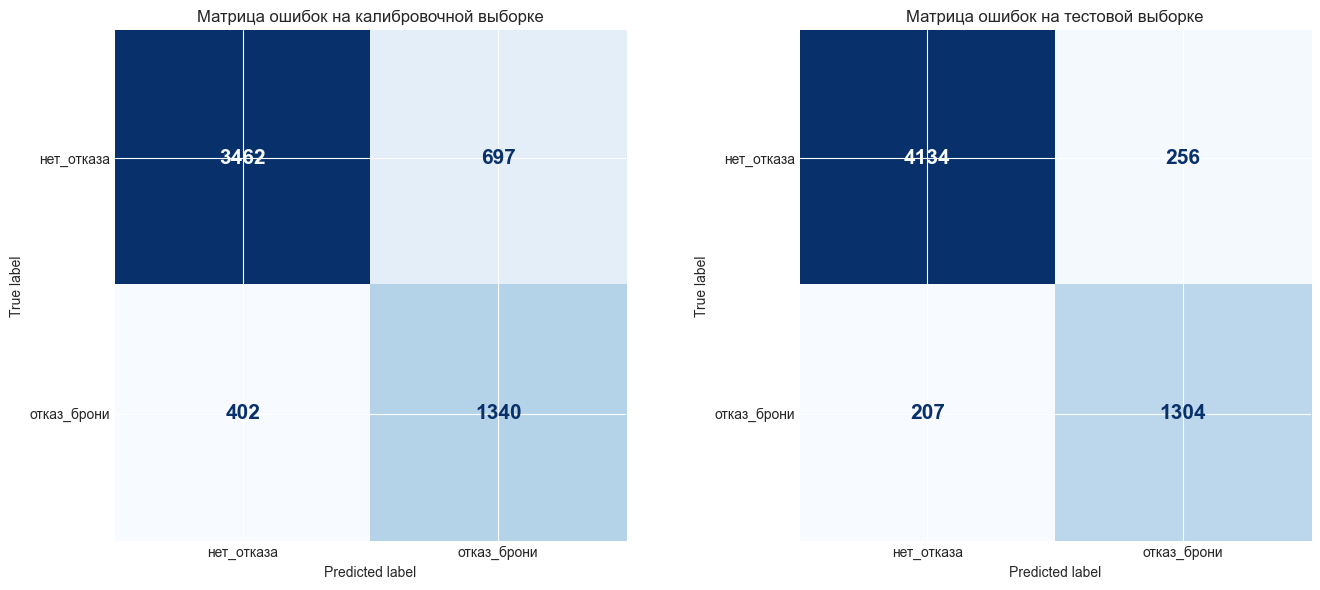

In [74]:
# Анализ матрицы классификаций на калибровочной и тестовой выборках

# Предсказания для калибровочной выборки и теста
calib_proba = best_calibrated_model.predict_proba(X_cal)[:, 1]
test_proba = best_calibrated_model.predict_proba(X_test)[:, 1]

calib_predictions = (calib_proba >= best_calibrated_threshold).astype(int)
test_predictions = (test_proba >= best_calibrated_threshold).astype(int)

# Классификационные матрицы
calib_confusion = confusion_matrix(y_cal, calib_predictions, labels=[0, 1])
test_confusion = confusion_matrix(y_test, test_predictions, labels=[0, 1])

# Метрики и IR для калибровочной и тестовой выборок
calib_metrics = metrics_calc(y_cal, calib_predictions, calib_proba)
test_metrics = metrics_calc(y_test, test_predictions, test_proba)

calib_ir = calculate_ir(y_cal, calib_predictions)
test_ir = calculate_ir(y_test, test_predictions)

# Добавляем даты и удобный вывод в DataFrame
calib_summary = pd.DataFrame(
    {
        'Показатель': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC-ROC', 'TP', 'FP', 'FN', 'TN', 'IR'],
        'Значение': [
            calib_metrics['Accuracy'],
            calib_metrics['Precision'],
            calib_metrics['Recall'],
            calib_metrics['F1-score'],
            calib_metrics['AUC-ROC'],
            calib_metrics['TP'],
            calib_metrics['FP'],
            calib_metrics['FN'],
            calib_metrics['TN'],
            calib_ir
        ]
    }
)

# Для теста

test_summary = pd.DataFrame(
    {
        'Показатель': ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC-ROC', 'TP', 'FP', 'FN', 'TN', 'IR'],
        'Значение': [
            test_metrics['Accuracy'],
            test_metrics['Precision'],
            test_metrics['Recall'],
            test_metrics['F1-score'],
            test_metrics['AUC-ROC'],
            test_metrics['TP'],
            test_metrics['FP'],
            test_metrics['FN'],
            test_metrics['TN'],
            test_ir
        ]
    }
)

print('\nИтоговые метрики и IR на калибровочной выборке:')
display(calib_summary.T)

print('\nИтоговые метрики и IR на тестовой выборке:')
display(test_summary.T)

# Визуализация матриц ошибок на калибровочной и тестовой выборках
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay(
    calib_confusion, display_labels=['нет_отказа', 'отказ_брони']
).plot(ax=axes[0], cmap='Blues', colorbar=False, text_kw={'fontsize': 15, 'fontweight': 'bold'})
axes[0].set_title('Матрица ошибок на калибровочной выборке')

ConfusionMatrixDisplay(
    test_confusion, display_labels=['нет_отказа', 'отказ_брони']
).plot(ax=axes[1], cmap='Blues', colorbar=False, text_kw={'fontsize': 15, 'fontweight': 'bold'})
axes[1].set_title('Матрица ошибок на тестовой выборке')

plt.tight_layout()
plt.show()

# Подготовка отдельных переменных для дальнейшей работы
calib_confusion_matrix = calib_confusion
test_confusion_matrix = test_confusion
calib_ir_value = calib_ir
test_ir_value = test_ir

# Сохранение предсказаний для последующего использования
calib_predictions_for_report = calib_predictions
test_predictions_for_report = test_predictions

<font color='blue'><b>Комментарий ревьюера: </b></font> ⚠️\
<font color='darkorange'> Здесь зашла бы визуализация.</font>

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Добавил визуализацию матриц ошибок.</span>

<font color='blue'><b>Комментарий ревьюера 2: </b></font> ✔️\
<font color='green'> Отличная визуализация результата!</font>

### [2.5 Фиксирование итоговой модели <a id=2_5></a>](#content)

In [75]:
# Фиксирование итоговой модели и порога

# Лучший результат после калибровки
final_model_name = best_calibrated_model_name
final_model = best_calibrated_model
final_threshold = best_calibrated_threshold

# Финальный порог и предсказания на тестовой выборке
final_test_proba = final_model.predict_proba(X_test)[:, 1]
final_test_predictions = (final_test_proba >= final_threshold).astype(int)

# Финальные метрики на тестовой выборке
final_test_metrics = metrics_calc(y_test, final_test_predictions, final_test_proba)
final_test_ir = calculate_ir(y_test, final_test_predictions)

# Сохраняем финальное состояние для последующих этапов
final_model_name_for_report = final_model_name
final_model_for_report = final_model
final_threshold_for_report = final_threshold
final_test_proba_for_report = final_test_proba
final_test_predictions_for_report = final_test_predictions

print(f'Фиксированная итоговая модель: {final_model_name}')
print(f'Фиксированный порог классификации: {final_threshold:.3f}')
print(f'IR на тестовой выборке при финальном пороге: {final_test_ir:,.0f} руб.')
print('Тестовые метрики финальной модели:')
for key, value in final_test_metrics.items():
    if isinstance(value, (int, float)):
        print(f'{key}: {value:.3f}')


Фиксированная итоговая модель: LGBMClassifier_tuning_sigmoid
Фиксированный порог классификации: 0.344
IR на тестовой выборке при финальном пороге: 124,484,000 руб.
Тестовые метрики финальной модели:
Accuracy: 0.922
Precision: 0.836
Recall: 0.863
F1-score: 0.849
AUC-ROC: 0.978


### [2.6 Анализ важности признаков <a id=2_6></a>](#content)

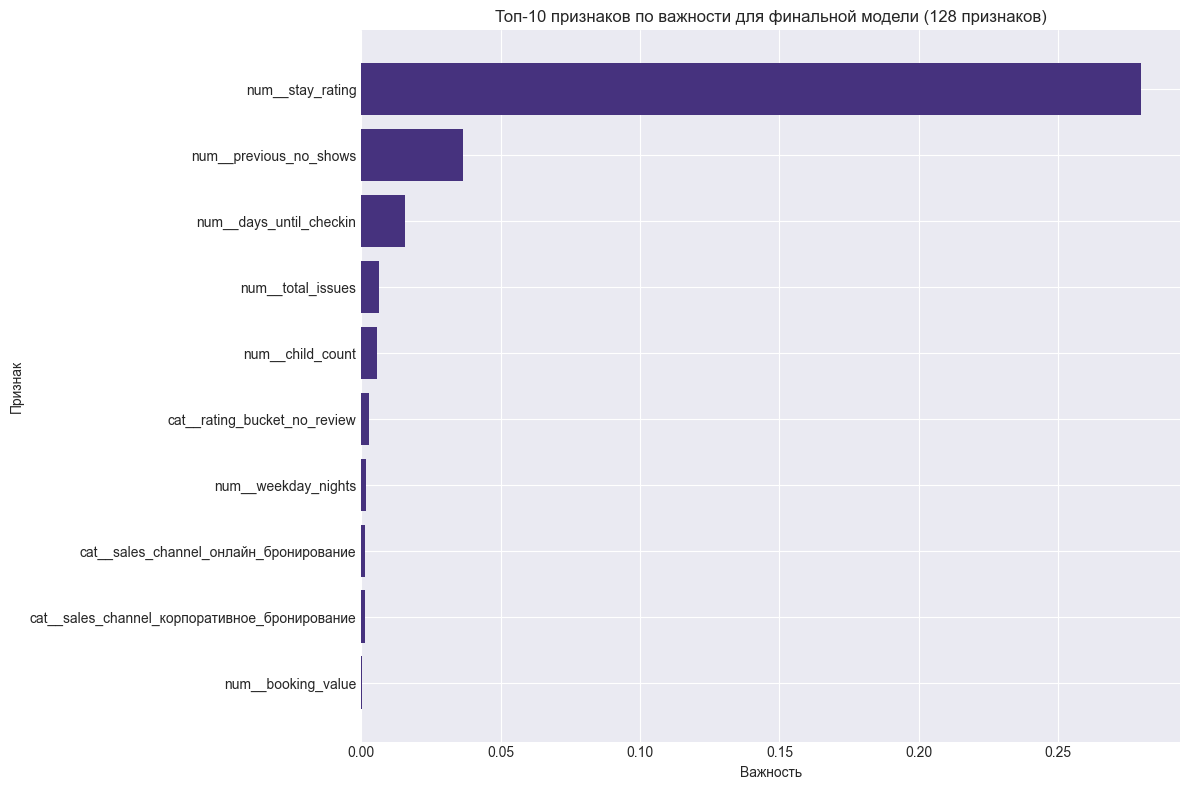


Топ-10 признаков:


,feature,importance
0,num__stay_rating,0.280
1,num__previous_no_shows,0.037
2,num__days_until_checkin,0.016
3,num__total_issues,0.007
4,num__child_count,0.006
5,cat__rating_bucket_no_review,0.003
6,num__weekday_nights,0.002
7,cat__sales_channel_онлайн_бронирование,0.001
8,cat__sales_channel_корпоративное_бронирование,0.001
9,num__booking_value,0.000


In [76]:
# Анализ важности признаков на уровне 128 преобразованных признаков

# 1. Применяем к X_test преобразования один раз: 3 функции + препроцессор
X_test_transformed = best_model[:-1].transform(X_test)

# 2. Перестановочная важность по преобразованной матрице
#    (best_model[-1] — сама модель CatBoost внутри пайплайна)
perm_res = permutation_importance(
    best_model[-1],
    X_test_transformed,
    y_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring='roc_auc'
)
feature_importance = perm_res.importances_mean

# 3. Имена 128 признаков после препроцессора
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

# 4. Визуализация топ-10
plt.figure(figsize=(12, 8))
sorted_top10 = feature_importance_df.head(10).sort_values('importance', ascending=True)

plt.barh(sorted_top10['feature'], sorted_top10['importance'])
plt.title('Топ-10 признаков по важности для финальной модели (128 признаков)')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

# 5. Сохраняем для дальнейшего использования в выводах
top_features = feature_importance_df.head(10).copy().reset_index()

print('\nТоп-10 признаков:')
display(top_features[['feature', 'importance']])

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> 👍</font>

### [2.7 Промежуточный итог <a id=2_7></a>](#content)

**1. Разделение данных и обучение базовых моделей**

Данные разделены на три выборки без перемешивания: обучающая — 17 702 записи (60%), калибровочная — 5 901 (20%), тестовая — 5 901 (20%). В исходном виде используется 18 признаков (после пайплайна — 128).

Обучены две модели — `CatBoostClassifier` и `LGBMClassifier` — в базовой и оптимизированной версиях. Кросс-валидация проводилась на 3 фолдах (`TimeSeriesSplit`, test_size=2000). Гиперпараметры подбирались в `Optuna` (TPESampler, 10 испытаний на модель, MedianPruner). Целевая метрика оптимизации — средний `Incremental Revenue` по фолдам.

Результаты сравнения моделей по приросту дохода `IR`:

* `CatBoostClassifier_Base` — AUC-ROC 0.881, IR 28 793 833 руб.;
* `LGBMClassifier_Base` — AUC-ROC 0.882, IR 29 155 833 руб.;
* `CatBoostClassifier_tuning` — AUC-ROC 0.883, IR 28 935 333 руб.;
* **`LGBMClassifier_tuning` — AUC-ROC 0.883, IR 29 159 500 руб.**

Лучшей по ключевой бизнес-метрике стала `LGBMClassifier_tuning` с наибольшим приростом дохода.

**2. Калибровка модели**

Лучшая модель дообучена на полной обучающей выборке. Вероятности откалиброваны с помощью `CalibratedClassifierCV` (3 фолда) методами `sigmoid` и `isotonic`. Метрики на калибровочной выборке (порог 0.5): `LGBMClassifier_tuning_sigmoid` — IR 88 631 000 руб., AUC-ROC 0.896; `LGBMClassifier_tuning_isotonic` — IR 87 223 000 руб., AUC-ROC 0.896. По ключевой бизнес-метрике `IR` среди калиброванных вариантов выбрана сигмоидная калибровка: `LGBMClassifier_tuning_sigmoid`.

**3. Поиск оптимального порога**

Порог классификации перебирался на калибровочной выборке по максимуму `Incremental Revenue` (без ограничений). Оптимальный порог — **0.344**, при нём `IR` на калибровочной выборке составил 96 894 500 руб. (TP 1 340, FP 697, FN 402, TN 3 462; Accuracy 0.814, Precision 0.658, Recall 0.769).

**4. Оценка стабильности модели**

Сравнение матриц ошибок и IR на калибровочной и тестовой выборках:

| Метрика | Калибровочная выборка | Тестовая выборка |
|---|---|---|
| TP | 1 340 | 1 304 |
| FP | 697 | 256 |
| FN | 402 | 207 |
| TN | 3 462 | 4 134 |
| Accuracy | 0.814 | 0.922 |
| Precision | 0.658 | 0.836 |
| Recall | 0.769 | 0.863 |
| F1-score | 0.709 | 0.849 |
| AUC-ROC | 0.896 | 0.978 |
| IR | 96 894 500 руб. | 124 484 000 руб. |

Метрики на тестовой выборке заметно выше калибровочных (Accuracy 0.922, Precision 0.836, Recall 0.863, AUC-ROC 0.978), IR на тесте — 124 484 000 руб. Модель демонстрирует высокое качество и стабильность на новых данных.

**5. Фиксация итоговой модели**

Итоговая модель: `LGBMClassifier_tuning_sigmoid`, порог классификации 0.344. На тестовой выборке модель достигает IR 124 484 000 руб. (Accuracy 0.922, Precision 0.836, Recall 0.863, F1-score 0.849, AUC-ROC 0.978).

**6. Анализ важности признаков**

Важность оценена методом permutation importance (5 повторов, метрика AUC-ROC) на уровне 128 преобразованных признаков пайплайна. Топ-10 признаков, влияющих на риск отмены брони: `stay_rating` (0.280), `previous_no_shows` (0.037), `days_until_checkin` (0.016), `total_issues` (0.007), `child_count` (0.006), `rating_bucket_no_review` (0.003), `weekday_nights` (0.002), `sales_channel` онлайн бронирование (0.001), `sales_channel` корпоративное бронирование (0.001), `booking_value` (0.000).

**Итог этапа**

Выбрана, откалибрована и зафиксирована модель `LGBMClassifier` с сигмоидной калибровкой и порогом 0.344. Модель показывает высокие метрики на тесте (Accuracy 0.922, Precision 0.836, Recall 0.863, AUC-ROC 0.978) и готова к расчёту экономической эффективности.


## [Этап 3: расчёт экономической эффективности модели <a id=3></a>](#content)

### [3.1 Подготовка данных для расчётов <a id=3_1></a>](#content)

In [77]:
# Приводим целевую переменную к массиву для расчётов
y_test_arr = y_test.to_numpy(dtype=int)
final_test_predictions = final_test_predictions.astype(int)

total = len(y_test_arr)

# До внедрения модели: фактические доля отмен и загрузка на тестовых данных
baseline_cancel_share = y_test_arr.mean()
baseline_occupancy = 1 - baseline_cancel_share

# IR до внедрения: доход без модели
baseline_ir = ((y_test_arr == 0).sum() * AVG_REV) - ((y_test_arr == 1).sum() * LOST_REV)

# Матрица ошибок для расчёта показателей после внедрения модели
tn, fp, fn, tp = confusion_matrix(y_test_arr, final_test_predictions, labels=[0, 1]).ravel()

# Реальная доля отмен после внедрения = не найденные моделью отмены (FN)
post_model_cancel_share = fn / total

# Загрузка отеля после внедрения = реально занятые номера (TN)
post_model_occupancy = tn / total

# IR после внедрения модели
post_model_ir = tp * PER_REBOOKING + tn * AVG_REV - fp * COST_FP - fn * LOST_REV

# Сохраняем промежуточные переменные
stage3_before = {
    'cancel_share': baseline_cancel_share,
    'occupancy': baseline_occupancy,
    'ir': baseline_ir,
}

stage3_after = {
    'cancel_share': post_model_cancel_share,
    'occupancy': post_model_occupancy,
    'ir': post_model_ir,
}

print('Подготовка данных завершена.')
print(f'Фактическая доля отмен до внедрения: {baseline_cancel_share:.2%}')
print(f'Доля отмен после внедрения: {post_model_cancel_share:.2%}')
print(f'Загрузка отеля до внедрения: {baseline_occupancy:.2%}')
print(f'Загрузка отеля после внедрения: {post_model_occupancy:.2%}')
print(f'IR до внедрения: {baseline_ir:,.0f} руб.')
print(f'IR после внедрения: {post_model_ir:,.0f} руб.')


Подготовка данных завершена.
Фактическая доля отмен до внедрения: 25.61%
Доля отмен после внедрения: 3.51%
Загрузка отеля до внедрения: 74.39%
Загрузка отеля после внедрения: 70.06%
IR до внедрения: 185,695,500 руб.
IR после внедрения: 310,179,500 руб.


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'><s>
- `predicted_cancel_share = final_test_predictions.mean()` Это не «доля отмен», а доля срабатывания модели. Реальная доля отмен после внедрения: это те, кого модель не нашла (FN). Все остальные либо приехали сами, либо были «спасены».
- `post_model_occupancy = 1 - predicted_cancel_share` — это (tn + tp + fp) / total. Но в контексте данной брони при tp и fp заселения не происходит, поскольку модель отменяет бронь. Нужно считать только реально занятые номера (TN), когда номер свободен и может быть снова забронирован — это не заселённый номер.</s>
</font>

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Учёл замечание. Все выводы ниже скорректировал с учетом новых данных.</span>

<font color='blue'><b>Комментарий ревьюера 2: </b></font> ✔️\
<font color='green'> 👍</font>

### [3.2 Расчёт показателей до и после внедрения модели <a id=3_2></a>](#content)

In [78]:
# Относительный IR на основе корректно сохранённых значений
relative_ir_pct = ((stage3_after['ir'] - stage3_before['ir']) / stage3_before['ir'])

# Проверяем достижение целевых метрик
cancel_share_target_met = stage3_after['cancel_share'] <= TARGET_CANCEL_SHARE
occupancy_drop_allowed = stage3_after['occupancy'] >= (stage3_before['occupancy'] * (1 - MAX_OCCUPANCY_DROP))
relative_ir_target_met = relative_ir_pct >= MIN_RELATIVE_IR

# Подготавливаем итоговую табличку
kpi_check_df = pd.DataFrame(
    [
        {
            'Ключевой показатель': 'Доля отмен после внедрения',
            'Значение': stage3_after['cancel_share'],
            'Целевой уровень': TARGET_CANCEL_SHARE,
            'Статус': 'Да' if cancel_share_target_met else 'Нет',
        },
        {
            'Ключевой показатель': 'Загрузка отеля после внедрения',
            'Значение': stage3_after['occupancy'],
            'Целевой уровень': stage3_before['occupancy'] * (1 - MAX_OCCUPANCY_DROP),
            'Статус': 'Да' if occupancy_drop_allowed else 'Нет',
        },
        {
            'Ключевой показатель': 'Относительный IR',
            'Значение': relative_ir_pct,
            'Целевой уровень': MIN_RELATIVE_IR,
            'Статус': 'Да' if relative_ir_target_met else 'Нет',
        },
    ]
)

# Приводим значения к процентам, где нужно
kpi_check_df['Значение'] = kpi_check_df['Значение'].apply(lambda x: f'{x:.2%}' if pd.notna(x) else x)
kpi_check_df['Целевой уровень'] = kpi_check_df['Целевой уровень'].apply(
    lambda x: f'{x:.2%}' if isinstance(x, (int, float)) else x
)

print('Проверка целевых KPI:')
display(kpi_check_df)

# Дополнительно сохраняем для дальнейшего анализа
stage3_kpi = {
    'cancel_share_target_met': cancel_share_target_met,
    'occupancy_drop_allowed': occupancy_drop_allowed,
    'relative_ir_target_met': relative_ir_target_met,
    'kpi_check_df': kpi_check_df,
}


Проверка целевых KPI:


,Ключевой показатель,Значение,Целевой уровень,Статус
0,Доля отмен после внедрения,3.51%,10.00%,Да
1,Загрузка отеля после внедрения,70.06%,68.44%,Да
2,Относительный IR,67.04%,50.00%,Да


### [3.3 Проверка целевых KPI <a id=3_3></a>](#content)

In [79]:
# Динамика доли отмен
cancel_share_change = ((stage3_after['cancel_share'] - stage3_before['cancel_share']) / stage3_before['cancel_share']) * 100

# Динамика загрузки отеля
occupancy_change = ((stage3_after['occupancy'] - stage3_before['occupancy']) / stage3_before['occupancy']) * 100

# Относительный IR
relative_ir = ((stage3_after['ir'] - stage3_before['ir']) / stage3_before['ir']) * 100

stage3_dynamics = {
    'cancel_share_change_pct': cancel_share_change,
    'occupancy_change_pct': occupancy_change,
    'relative_ir_pct': relative_ir,
}

stage3_dynamics_df = pd.DataFrame(
    [
        {
            'Показатель': 'Доля отмен бронирования',
            'До внедрения': stage3_before['cancel_share'],
            'После внедрения': stage3_after['cancel_share'],
            'Изменение, %': cancel_share_change,
        },
        {
            'Показатель': 'Загрузка отеля',
            'До внедрения': stage3_before['occupancy'],
            'После внедрения': stage3_after['occupancy'],
            'Изменение, %': occupancy_change,
        },
        {
            'Показатель': 'IR',
            'До внедрения': stage3_before['ir'],
            'После внедрения': stage3_after['ir'],
            'Изменение, %': relative_ir,
        },
    ]
)

print('Динамика изменения основных показателей')
display(stage3_dynamics_df)


Динамика изменения основных показателей


,Показатель,До внедрения,После внедрения,"Изменение, %"
0,Доля отмен бронирования,0.256,0.035,-86.300
1,Загрузка отеля,0.744,0.701,-5.831
2,IR,185 695 500.000,310 179 500.000,67.037


### [3.4 Промежуточный итог <a id=3_4></a>](#content)

**1. Итоговые экономические показатели**

*До внедрения модели (фактические значения на тестовой выборке):*

* Доля отмен бронирования: 25.61%
* Загрузка отеля: 74.39%
* `IR` до внедрения: 185 695 500 руб.

*После внедрения модели* (итоговая модель `LGBMClassifier_tuning_sigmoid`, калибровка `sigmoid`, фиксированный порог классификации 0.344):

* Доля отмен после внедрения: 3.51%
* Загрузка отеля: 70.06%
* `IR` после внедрения: 310 179 500 руб.
* Прирост `IR`: +124 484 000 руб. (+67.04%)

**2. Проверка целевых KPI**

| Ключевой показатель | Значение | Целевой уровень | Статус |
|---|---|---|---|
| Доля отмен после внедрения | 3.51% | ≤ 10% | ✅ Достигнуто |
| Загрузка отеля после внедрения | 70.06% | ≥ 68.44% | ✅ Достигнуто |
| Относительный `IR` | +67.04% | ≥ 50% | ✅ Достигнуто |

**3. Анализ эффекта модели**

Прирост `IR` определяется формулой:

`IR_после − IR_до = TP × (PER_REBOOKING + LOST_REV) − FP × COST_FP = TP × 109 500 − FP × 7 000`

На тестовой выборке 5 901 бронь, из них 1 511 фактических отмен (25.61%). Модель в рабочей точке (порог 0.344) выявила 1 304 отмены (TP), пропустив лишь 207 (FN), и дала 256 ложных срабатываний (FP) при 4 134 корректно подтверждённых активных бронях (TN). Благодаря высокой полноте (Recall 0.863) и точности (Precision 0.836) модель обеспечила:

* снижение доли отмен с 25.61% до 3.51% (−86.3%) — целевой уровень ≤ 10% выполнен;
* загрузка отеля снизилась с 74.39% до 70.06% (−5.8%), что в пределах допустимого падения 8% — целевой уровень выполнен (70.06% ≥ 68.44%);
* прирост дохода +124 484 000 руб. (+67.04%) — целевой уровень относительного `IR` ≥ 50% выполнен.

**4. Выбранная рабочая точка**

Фиксированный порог 0.344 подобран строго по максимуму `Incremental Revenue` на калибровочной выборке. Модель `LGBMClassifier_tuning_sigmoid` в этой точке помечает около 26% броней на тесте (TP+FP = 1 560 из 5 901) и обеспечивает достижение всех трёх целевых KPI, предусмотренных проектом.


## [Этап 4: Выводы по проекту <a id=4></a>](#content)

### [4.1 Выводы о проделанной работе <a id=4_1></a>](#content)

**2. Моделирование**

- Данные разделены на три выборки (60/20/20) без перемешивания: обучающая — 17 702, калибровочная — 5 901, тестовая — 5 901 запись (тестовая — самая поздняя по времени).

- Обучены и сравнены модели `CatBoostClassifier` и `LGBMClassifier` (базовые и оптимизированные версии), кросс-валидация на 3 фолдах (`TimeSeriesSplit`, test_size=2000).

- Гиперпараметры оптимизированы в `Optuna` (TPESampler, 10 испытаний, MedianPruner): для LightGBM — `n_estimators`, `learning_rate`, `num_leaves`, `max_depth`; для CatBoost — `iterations`, `learning_rate`, `depth`, `l2_leaf_reg`. Ключевая метрика оптимизации — средний Incremental Revenue.

- Лучшая модель по IR — `LGBMClassifier_tuning` (IR 29 159 500 руб., AUC-ROC 0.883, Accuracy 0.818, Precision 0.743).

- Калибровка вероятностей выполнена через `CalibratedClassifierCV` (3 фолда, методы `sigmoid` и `isotonic`); по ключевой бизнес-метрике `IR` выбрана сигмоидная калибровка — `LGBMClassifier_tuning_sigmoid` (IR на калибровке при пороге 0.5 — 88 631 000 руб., AUC-ROC 0.896).

- Порог классификации подобран на калибровочной выборке (сетка 0.05–0.99) по максимуму `Incremental Revenue`: оптимальный порог — **0.344**, IR на калибровке — 96 894 500 руб.

**3. Оценка метрик**

- Стабильность модели проверена сравнением матриц ошибок и IR на двух выборках: калибровочная — Accuracy 0.814, Precision 0.658, Recall 0.769, AUC-ROC 0.896, IR 96 894 500 руб.; тестовая — Accuracy 0.922, Precision 0.836, Recall 0.863, AUC-ROC 0.978, IR 124 484 000 руб. Метрики на тесте выше калибровочных, сдвига качества в худшую сторону нет — модель стабильна.

- Итоговая модель: `LGBMClassifier_tuning_sigmoid`, порог 0.344. На тестовой выборке: Accuracy 0.922, Precision 0.836, Recall 0.863, F1-score 0.849, AUC-ROC 0.978, IR 124 484 000 руб.

**4. Анализ важности факторов**

- Важность признаков оценена методом permutation importance (5 повторов, метрика AUC-ROC) на уровне 128 преобразованных признаков пайплайна — метод показывает, насколько падает качество модели при случайном перемешивании признака, что корректно работает для закодированных категориальных и текстовых признаков.

- Топ-10 признаков: `stay_rating` (0.280), `previous_no_shows` (0.037), `days_until_checkin` (0.016), `total_issues` (0.007), `child_count` (0.006), `rating_bucket_no_review` (0.003), `weekday_nights` (0.002), `sales_channel` онлайн бронирование (0.001), `sales_channel` корпоративное бронирование (0.001), `booking_value` (0.000).


### [4.2 Выводы по анализу эффективности модели <a id=4_2></a>](#content)

**1. Итоговая оценка достижения цели**

Цель проекта — разработать ML-модель, прогнозирующую вероятность отмены бронирования в сети отелей UrbanStay, снизить долю отмен в последний момент и повысить загрузку отелей, а также оценить экономическую эффективность решения. Модель построена, откалибрована и зафиксирована; экономический эффект положительный — +124 484 000 руб. (+67.04%). **Все три целевых KPI достигнуты**: доля отмен снижена с 25.61% до 3.51% (целевой уровень ≤ 10%); загрузка отеля снизилась с 74.39% до 70.06%, что в пределах допустимого падения 8% (70.06% ≥ 68.44%); относительный `IR` составил 67.04% при целевом уровне ≥ 50%.

**2. Результаты по ключевым метрикам**

| Показатель | До внедрения | После внедрения | Изменение |
|---|---|---|---|
| Доля отмен бронирования | 25.61% | 3.51% | −86.3% |
| Загрузка отеля | 74.39% | 70.06% | −5.8% |
| IR | 185 695 500 руб. | 310 179 500 руб. | +124 484 000 руб. (+67.04%) |

**3. Целевые показатели для заказчика**

- Доля отмен после внедрения: **3.51% ≤ 10%** — ✅ достигнуто;
- Загрузка отеля: **70.06% ≥ 68.44%** (не снизилась более чем на 8%) — ✅ достигнуто;
- Относительный IR: **+67.04% ≥ 50%** — ✅ достигнуто.

**4. Анализ важности признаков: что влияет на отмены**

Топ-10 признаков, влияющих на риск отмены бронирования:

1. `stay_rating` (0.280) — оценка предыдущего проживания: главный фактор риска; довольные прошлым визитом клиенты значительно реже отменяют новые брони.
2. `previous_no_shows` (0.037) — наличие незаездов в истории клиента повышает риск отмены текущей брони.
3. `days_until_checkin` (0.016) — чем больше дней между бронированием и заездом, тем выше риск отмены: дальние планы чаще меняются.
4. `total_issues` (0.007) — суммарное количество отмен и незаездов в истории клиента.
5. `child_count` (0.006) — брони с детьми стабильнее: семейные поездки планируются тщательнее.
6. `rating_bucket_no_review` (0.003) — отсутствие предыдущего отзыва как маркер повышенного риска.
7. `weekday_nights` (0.002) — количество будних ночей проживания.
8. `sales_channel` онлайн бронирование (0.001) — онлайн-канал показывает более высокий риск отмены.
9. `sales_channel` корпоративное бронирование (0.001) — корпоративные брони отменяются реже остальных каналов.
10. `booking_value` (0.000) — стоимость брони практически не влияет на вероятность отмены.

**5. Рекомендации для бизнеса**

1. *Внедрить модель в операционный процесс:* брони с вероятностью отмены выше порога 0.344 автоматически помечать как рискованные — предлагать таким клиентам гибкие условия или альтернативные даты, а освобождающиеся номера заранее выставлять в перепродажу (лист ожидания).

2. *Работать с ключевыми драйверами отмен:* главный фактор — оценка прошлого проживания (`stay_rating`): повышение качества сервиса и работа с недовольными клиентами напрямую снижают риск отмен будущих броней. Также важны история клиента (`previous_no_shows`, `total_issues`) и большой горизонт планирования (`days_until_checkin`) — для таких броней стоит вводить депозиты или невозвратные тарифы.

3. *Развивать корпоративный канал продаж* как наиболее стабильный и учитывать маркеры риска по отсутствию истории отзывов у клиента (`rating_bucket_no_review`).


<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Очень приятно видеть вывод в конце проекта!\
Приведены ответы на главные вопросы проекта.</font>

<font color='blue'><b>Итоговый комментарий ревьюера</b></font>\
<font color='green'>Михаил, хороший проект получился!
Большое спасибо за проделанную работу. Видно, что приложено много усилий.
Выводы и рассуждения получились содержательными, их было интересно читать.
</font>

<font color='steelblue'>Над проектом ещё стоит поработать - есть рекомендации по дополнению некоторых твоих шагов проекта. Такие рекомендации я отметил жёлтыми комментариями. Будет здорово, если ты учтёшь их - так проект станет структурно и содержательно более совершенным.

Также в работе есть критические замечания. К этим замечаниям я оставил пояснительные комментарии красного цвета, в которых перечислил возможные варианты дальнейших действий. Уверен, ты быстро с этим управишься:)

Если о том, что нужно сделать в рамках комментариев, будут возникать вопросы - оставь их, пожалуйста, в комментариях, и я отвечу на них во время следующего ревью.

Также буду рад ответить на любые твои вопросы по проекту или на какие-либо другие, если они у тебя имеются - оставь их в комментариях, и я постараюсь ответить:)</font>

<font color='blue'><b>Жду твой проект на повторном ревью. До встречи :) </b></font>

<span style="color: purple; font-weight: bold">Комментарий студента v1</span>
<span style="color: blue"><br>Павел, спасибо большое за подробную и внимательную проверку!<br>Я учёл все твои замечания и переработал проект:<br>• вынес установку зависимостей в отдельную ячейку до импортов, чтобы код полностью воспроизводился;
<br>• перевёл разделение данных на строго временное (без перемешивания), чтобы тестовая выборка была позже всех по времени;
<br>• перевёл кросс-валидацию и калибровку на `TimeSeriesSplit` с валидацией только на «будущих» данных;
<br>• исправил расчёт IR — зафиксировал сетку классов `labels=[0, 1]` в `confusion_matrix`;
<br>• исправил калибровку — модель больше не оценивается на данных, на которых калибровалась; качество калибровки проверено независимо на `X_cal`;
<br>• убрал порог 1.0 из сетки, добавил `zero_division=0` и ограничил долю помеченных броней диапазоном 5–10%;
<br>• убрал строки с нулевой стоимостью брони и исправил выбросы;
<br>• добавил промежуточные выводы по каждому блоку работы;
<br>• после перевыполнения всех ячеек пересчитал и актуализировал все метрики, порог, матрицы ошибок, важность признаков и показатели экономической эффективности, а также обновил соответствующие выводы в проекте.<br><br>Ещё раз большое спасибо за ценные замечания и за то, что делился опытом — это очень помогло сделать проект качественнее. Буду рад новой проверке!</span>

<font color='blue'><b>Итоговый комментарий ревьюера 2</b></font>\
<font color='green'>Михаил, большое спасибо за доработку.
</font>

<font color='steelblue'>Над проектом ещё стоит поработать - есть рекомендации по дополнению некоторых твоих шагов проекта. Такие рекомендации я отметил жёлтыми комментариями. Будет здорово, если ты учтёшь их - так проект станет структурно и содержательно более совершенным.

Также в работе есть критические замечания. К этим замечаниям я оставил пояснительные комментарии красного цвета, в которых перечислил возможные варианты дальнейших действий. Уверен, ты быстро с этим управишься:)

Если о том, что нужно сделать в рамках комментариев, будут возникать вопросы - оставь их, пожалуйста, в комментариях, и я отвечу на них во время следующего ревью.

Также буду рад ответить на любые твои вопросы по проекту или на какие-либо другие, если они у тебя имеются - оставь их в комментариях, и я постараюсь ответить:)</font>

<font color='blue'><b>Жду твой проект на повторном ревью. До встречи :) </b></font>